## **Identifying Investment Opportunities through Price Prediction Ames, Iowa**

### **Problem Statement**

**To Predict the sales price of each house.**

### **Business Objective:**


__Develop a model to predict home prices in Ames, Iowa, enabling stakeholders to make data‑driven decisions by identifying whether a property is priced above or below its true value and uncovering potential investment opportunities.__

### **Goal Setting:**

In today's dynamic real estate market, accurate house sales price prediction is crucial for various stakeholders:

- **Home Buyers** : want to ensure they're making fair offer.
- **Real Estate Agent** : Need realiable price estimate to advise client effectively.
- **Investors** : Require accurate valuation for investment decisions.
- **Sellers** : Need to set competitive listing price.

## **1. Initial Analysis**

__1.1. Import Libraries__

In [42]:
from pathlib import Path
import pandas as pd
import numpy as np
import seaborn as sns
%matplotlib inline
import matplotlib.pyplot as plt
import sidetable
from sklearn.feature_selection import f_regression, r_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import chi2_contingency
from itertools import combinations
from collections import defaultdict
from typing import List, Tuple, Union, Any, Dict
import scipy.stats as stats 
from collections import defaultdict
from statsmodels.formula.api import ols


__1.2. Display Setting__

In [43]:
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
# Set the number of decimal places to 2
pd.set_option('display.float_format', '{:.2f}'.format)

__1.3. Data Ingestion & Basic Understanding__

In [44]:
path = Path.cwd().parent
files = []
for file in path.rglob('*.csv*'):
    files.append(file)
    print(file.name)
    print(files.index(file),' ',file)


final_submission.csv
0   e:\house_price_prediction\Real-Estate-Price-Prediction\submission\final_submission.csv
submission.csv
1   e:\house_price_prediction\Real-Estate-Price-Prediction\submission\submission.csv
test_cleaned.csv
2   e:\house_price_prediction\Real-Estate-Price-Prediction\data\processed\test_cleaned.csv
train_cleaned.csv
3   e:\house_price_prediction\Real-Estate-Price-Prediction\data\processed\train_cleaned.csv
sample_submission.csv
4   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\sample_submission.csv
test.csv
5   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\test.csv
train.csv
6   e:\house_price_prediction\Real-Estate-Price-Prediction\data\raw\extracted\train.csv


In [45]:
df_test = pd.read_csv(files[2])
df_test.head(1)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.00,11622,Pave,No,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Feedr,Norm,1Fam,1Story,5,6,1961,1961,Gable,CompShg,VinylSd,VinylSd,No,0.00,TA,TA,CBlock,TA,TA,No,Rec,468.00,LwQ,144.00,270.00,882.00,GasA,TA,Y,SBrkr,896,0,0,896,0.00,0.00,1,0,2,1,TA,5,Typ,0,No,Attchd,1961.00,Unf,1.00,730.00,TA,TA,Y,140,0,0,0,120,0,No,MnPrv,No,0,6,2010,WD,Normal


In [46]:
df_train = pd.read_csv(files[3])
df_train.head(1)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,No,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No,No,No,0,2,2008,WD,Normal,208500


In [47]:
df_train.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [48]:
print(df_train.query("SaleCondition == 'Normal'")['SalePrice'].min() ,np.argmin(df_train.query("SaleCondition == 'Normal'")['SalePrice']))
print(df_train.query("SaleCondition == 'Normal'")['SalePrice'].max() ,np.argmax(df_train.query("SaleCondition == 'Normal'")['SalePrice']))
print(df_train.iloc[66,:])

39300 436
755000 563
Id                    67
MSSubClass            20
MSZoning              RL
LotFrontage        73.00
LotArea            19900
Street              Pave
Alley                 No
LotShape             Reg
LandContour          Lvl
Utilities         AllPub
LotConfig         Inside
LandSlope            Gtl
Neighborhood       NAmes
Condition1          PosA
Condition2          Norm
BldgType            1Fam
HouseStyle        1Story
OverallQual            7
OverallCond            5
YearBuilt           1970
YearRemodAdd        1989
RoofStyle          Gable
RoofMatl         CompShg
Exterior1st      Plywood
Exterior2nd      Plywood
MasVnrType       BrkFace
MasVnrArea        287.00
ExterQual             TA
ExterCond             TA
Foundation        CBlock
BsmtQual              Gd
BsmtCond              TA
BsmtExposure          Gd
BsmtFinType1         GLQ
BsmtFinSF1           912
BsmtFinType2         Unf
BsmtFinSF2             0
BsmtUnfSF           1035
TotalBsmtSF         1947
Heat

In [49]:
df_train.shape
print('Number of rows :', df_train.shape[0])
print('Number of columns :', df_train.shape[1])

Number of rows : 1460
Number of columns : 81


In [50]:
# remove whitespace from columns
df_train.columns = df_train.columns.str.strip()

df_test.columns = df_test.columns.str.strip()

In [51]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1460 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

The data was collected by De Cock where 81 dimensions were recorded for 1460 properties in Ames IA.

Brief description of columns:

- **SalePrice** - the property's sale price in dollars. This is the target variable that you're trying to predict.

- **MSSubClass**: The building class

- **MSZoning**: The general zoning classification

- **LotFrontage**: Linear feet of street connected to property

- **LotArea**: Lot size in square feet

- **Street**: Type of road access

- **Alley**: Type of alley access

- **LotShape**: General shape of property

- **LandContour**: Flatness of the property

- **Utilities**: Type of utilities available

- **LotConfig**: Lot configuration

- **LandSlope**: Slope of property

- **Neighborhood**: Physical locations within Ames city limits

- **Condition1**: Proximity to main road or railroad

- **Condition2**: Proximity to main road or railroad (if a second is present)

- **BldgType**: Type of dwelling

- **HouseStyle**: Style of dwelling

- **OverallQual**: Overall material and finish quality

- **OverallCond**: Overall condition rating

- **YearBuilt**: Original construction date

- **YearRemodAdd**: Remodel date

- **RoofStyle**: Type of roof

- **RoofMatl**: Roof material

- **Exterior1st**: Exterior covering on house

- **Exterior2nd**: Exterior covering on house (if more than one material)

- **MasVnrType**: Masonry veneer type

- **MasVnrArea**: Masonry veneer area in square feet

- **ExterQual**: Exterior material quality

- **ExterCond**: Present condition of the material on the exterior

- **Foundation**: Type of foundation

- **BsmtQual**: Height of the basement

- **BsmtCond**: General condition of the basement

- **BsmtExposure**: Walkout or garden level basement walls

- **BsmtFinType1**: Quality of basement finished area

- **BsmtFinSF1**: Type 1 finished square feet

- **BsmtFinType2**: Quality of second finished area (if present)

- **BsmtFinSF2**: Type 2 finished square feet

- **BsmtUnfSF**: Unfinished square feet of basement area

- **TotalBsmtSF**: Total square feet of basement area

- **Heating**: Type of heating

- **HeatingQC**: Heating quality and condition

- **CentralAir**: Central air conditioning

- **Electrical**: Electrical system

- **1stFlrSF**: First Floor square feet

- **2ndFlrSF**: Second floor square feet

- **LowQualFinSF**: Low quality finished square feet (all floors)

- **GrLivArea**: Above grade (ground) living area square feet

- **BsmtFullBath**: Basement full bathrooms

- **BsmtHalfBath**: Basement half bathrooms

- **FullBath**: Full bathrooms above grade

- **HalfBath**: Half baths above grade

- **Bedroom**: Number of bedrooms above basement level

- **Kitchen**: Number of kitchens

- **KitchenQual**: Kitchen quality

- **TotRmsAbvGrd**: Total rooms above grade (does not include bathrooms)

- **Functional**: Home functionality rating

- **Fireplaces**: Number of fireplaces

- **FireplaceQu**: Fireplace quality

- **GarageType**: Garage location

- **GarageYrBlt**: Year garage was built

- **GarageFinish**: Interior finish of the garage

- **GarageCars**: Size of garage in car capacity

- **GarageArea**: Size of garage in square feet

- **GarageQual**: Garage quality

- **GarageCond**: Garage condition

- **PavedDrive**: Paved driveway

- **WoodDeckSF**: Wood deck area in square feet

- **OpenPorchSF**: Open porch area in square feet

- **EnclosedPorch**: Enclosed porch area in square feet

- **3SsnPorch**: Three season porch area in square feet

- **ScreenPorch**: Screen porch area in square feet

- **PoolArea**: Pool area in square feet

- **PoolQC**: Pool quality

- **Fence**: Fence quality

- **MiscFeature**: Miscellaneous feature not covered in other categories

- **MiscVal**: $Value of miscellaneous feature

- **MoSold**: Month Sold

- **YrSold**: Year Sold

- **SaleType**: Type of sale

- **SaleCondition**: Condition of sale

**This dataset represents the sale of  residential properties in Ames, Iowa, where every single record represents a sale of individual house.
There are 23 nominal, 23 ordinal, 14 discrete, and 20 continuous features describing each house’s size, quality, area, age, and other miscellaneous attributes.
The data spans from 2006 to 2010.**

__1.4. Columns Formatting and Consistency__

In [52]:
data_dtype = pd.DataFrame(index=df_train.columns, columns=['Dtype','nunique','unique'])
data_dtype['Dtype'] = df_train.dtypes
data_dtype['nunique'] = df_train.nunique()
data_dtype['unique'] = [df_train[col].unique() for col in df_train.columns]
data_dtype.head()

,Dtype,nunique,unique
Id,int64,1460,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14..."
MSSubClass,int64,15,"[60, 20, 70, 50, 190, 45, 90, 120, 30, 85, 80,..."
MSZoning,object,5,"[RL, RM, C (all), FV, RH]"
LotFrontage,float64,115,"[65.0, 80.0, 68.0, 60.0, 84.0, 85.0, 75.0, 51...."
LotArea,int64,1073,"[8450, 9600, 11250, 9550, 14260, 14115, 10084,..."


## __2. Exploratory Data Analysis (EDA)__

In [53]:
df_train = (
    df_train[df_train.columns.difference(['Id'])]
    )

**2.1. Distribution of dependent variable**

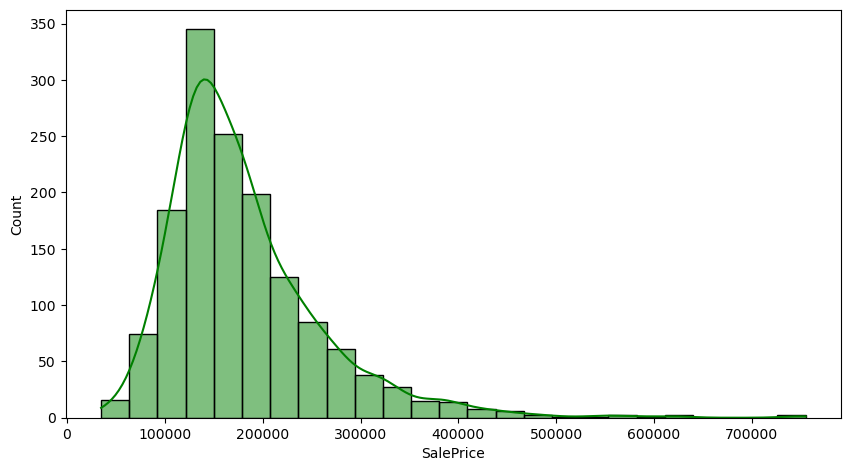

In [54]:
fig = plt.figure(figsize=(10,6))
sns.histplot(df_train['SalePrice'], bins=25,kde=True,color='green')
fig.subplots_adjust(bottom=0.2)

__2.2. Graphical summary with labeled histogram and data details__

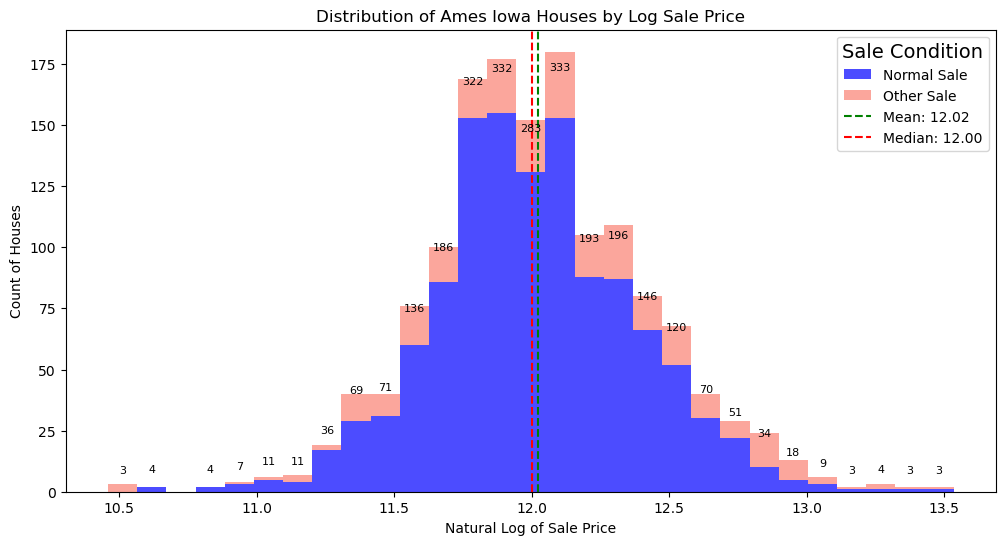

In [55]:

# Compute natural log of SalePrice
df_train['LogSalePrice'] = np.log(df_train['SalePrice'])

# Define bins (30 bins across the log scale)
bins = np.linspace(df_train['LogSalePrice'].min(), df_train['LogSalePrice'].max(), 30)

# Separate normal vs other sale conditions
normal_sales = df_train[df_train['SaleCondition'] == 'Normal']
other_sales = df_train[df_train['SaleCondition'] != 'Normal']

plt.figure(figsize=(12,6))

# Plot stacked histogram
counts, bin_edges, patches = plt.hist(
    [normal_sales['LogSalePrice'], other_sales['LogSalePrice']],
    bins=bins,
    stacked=True,
    color=['blue', 'salmon'],
    alpha=0.7,
    label=['Normal Sale', 'Other Sale']
)

# Annotate counts on top of each bin
for i in range(len(bin_edges)-1):
    total_count = counts[0][i] + counts[1][i]
    if total_count > 0:
        plt.text(
            (bin_edges[i] + bin_edges[i+1]) / 2,   # x position (center of bin)
            total_count / 2 + 5,                           # y position (top of bar)
            str(int(total_count)),                 # text label
            ha='center', va='bottom', fontsize=8
        )
# plot line for mean and median of log sale price
mean_log_price = df_train['LogSalePrice'].mean()
median_log_price = df_train['LogSalePrice'].median()
plt.axvline(mean_log_price, color='green', linestyle='--', label=f'Mean: {mean_log_price:.2f}')
plt.axvline(median_log_price, color='red', linestyle='--', label=f'Median: {median_log_price:.2f}')

plt.xlabel("Natural Log of Sale Price")
plt.ylabel("Count of Houses")
plt.title("Distribution of Ames Iowa Houses by Log Sale Price")
plt.legend(title="Sale Condition", title_fontsize=14)
plt.show()


**2.3. Neighborhood**

In [56]:
import pandas as pd

# Assume you already computed these
min_price = df_train['SalePrice'].min()
max_price = df_train['SalePrice'].max()
mean_price = df_train['SalePrice'].mean()
median_price = df_train['SalePrice'].median()
log_mean_price = df_train['LogSalePrice'].mean()
log_median_price = df_train['LogSalePrice'].median()
log_min_price = df_train['LogSalePrice'].min()
log_max_price = df_train['LogSalePrice'].max()
count_min = (df_train['SalePrice'] == min_price).sum()
count_max = (df_train['SalePrice'] == max_price).sum()
neighborhood_min = df_train.loc[df_train['SalePrice'] == min_price, 'Neighborhood'].unique()
neighborhood_max = df_train.loc[df_train['SalePrice'] == max_price, 'Neighborhood'].unique()
index_min = df_train.loc[df_train['SalePrice'] == min_price].index
index_max = df_train.loc[df_train['SalePrice'] == max_price].index
# Build DataFrame correctly
summary = pd.DataFrame(
    {
        "Price": [min_price, max_price, mean_price, median_price],
        "LogPrice" : [log_min_price, log_max_price, log_mean_price, log_median_price],
        "Count": [count_min, count_max, 0, 0],
        "Index" :[index_min[0], index_max[0], 0, 0],
        "Neighborhood": [neighborhood_min[0], neighborhood_max[0], 0, 0]
    },
    index=["Min Sale Price", "Max Sale Price", "Mean", "Median"]
)

display(summary)


,Price,LogPrice,Count,Index,Neighborhood
Min Sale Price,34900.00,10.46,1,495,IDOTRR
Max Sale Price,755000.00,13.53,1,691,NoRidge
Mean,180921.20,12.02,0,0,0
Median,163000.00,12.00,0,0,0


## __3. Model Building and Evaluation__

**3.1. Baseline Model**

Based on above EDA, we'll build baseline model on eight features using `SalePrice` or its transformation as target variable & other features are : `GrLivAre, LotArea, YearBuilt, OverallQual, SaleCondition, OverallCond`

In [57]:
ames_train = df_train.copy()

# Convert columns to categorical
ames_train['OverallQual'] = ames_train['OverallQual'].astype('category')
ames_train['OverallCond'] = ames_train['OverallCond'].astype('category')

# Select the specified columns
am = ames_train[['SalePrice', 'GrLivArea', 'LotArea', 'YearBuilt',
                 'OverallQual', 'LandSlope', 'SaleCondition', 'OverallCond']]

# Build the model with categorical features wrapped in C()
lmt = ols(
    formula="np.log(SalePrice) ~ np.log(GrLivArea) + np.log(LotArea) + YearBuilt + C(OverallQual) + C(LandSlope) + C(SaleCondition) + C(OverallCond)",
    data=am
).fit()

# Show regression summary
display(lmt.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:      np.log(SalePrice)   R-squared:                       0.858
Model:                            OLS   Adj. R-squared:                  0.856
Method:                 Least Squares   F-statistic:                     321.2
Date:                Sun, 31 May 2026   Prob (F-statistic):               0.00
Time:                        18:43:05   Log-Likelihood:                 694.91
No. Observations:                1460   AIC:                            -1334.
Df Residuals:                    1432   BIC:                            -1186.
Df Model:                          27                                         
Covariance Type:            nonrobust                                         
===============================================================================================
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
Intercept                      -1.8507      0.446     -4.147      0.000      -2.726      -0.975
C(OverallQual)[T.2]             0.0576      0.177      0.325      0.745      -0.290       0.405
C(OverallQual)[T.3]             0.1789      0.161      1.114      0.265      -0.136       0.494
C(OverallQual)[T.4]             0.2892      0.158      1.828      0.068      -0.021       0.600
C(OverallQual)[T.5]             0.3744      0.158      2.364      0.018       0.064       0.685
C(OverallQual)[T.6]             0.4397      0.159      2.767      0.006       0.128       0.752
C(OverallQual)[T.7]             0.5388      0.160      3.374      0.001       0.226       0.852
C(OverallQual)[T.8]             0.7096      0.160      4.426      0.000       0.395       1.024
C(OverallQual)[T.9]             0.9204      0.162      5.679      0.000       0.603       1.238
C(OverallQual)[T.10]            0.8910      0.165      5.386      0.000       0.567       1.216
C(LandSlope)[T.Mod]             0.0704      0.020      3.556      0.000       0.032       0.109
C(LandSlope)[T.Sev]             0.0225      0.046      0.486      0.627      -0.068       0.113
C(SaleCondition)[T.AdjLand]     0.0009      0.078      0.011      0.991      -0.152       0.154
C(SaleCondition)[T.Alloca]      0.0059      0.047      0.127      0.899      -0.086       0.097
C(SaleCondition)[T.Family]      0.0170      0.037      0.454      0.650      -0.056       0.090
C(SaleCondition)[T.Normal]      0.0804      0.016      5.023      0.000       0.049       0.112
C(SaleCondition)[T.Partial]     0.1254      0.022      5.756      0.000       0.083       0.168
C(OverallCond)[T.2]            -0.0326      0.233     -0.140      0.889      -0.490       0.425
C(OverallCond)[T.3]            -0.0604      0.221     -0.274      0.784      -0.493       0.373
C(OverallCond)[T.4]             0.0292      0.224      0.130      0.896      -0.410       0.469
C(OverallCond)[T.5]             0.1029      0.223      0.461      0.645      -0.335       0.541
C(OverallCond)[T.6]             0.1762      0.223      0.789      0.430      -0.262       0.614
C(OverallCond)[T.7]             0.2373      0.223      1.062      0.289      -0.201       0.676
C(OverallCond)[T.8]             0.2604      0.224      1.163      0.245      -0.179       0.700
C(OverallCond)[T.9]             0.3305      0.226      1.464      0.143      -0.112       0.773
np.log(GrLivArea)               0.4456      0.017     26.396      0.000       0.412       0.479
np.log(LotArea)                 0.1297      0.009     14.577      0.000       0.112       0.147
YearBuilt                       0.0044      0.000     22.252      0.000       0.004       0.005
==============================================================================
Omnibus:                    

__Model Fit__

__R-squared = 0.858, Adjusted R-squared = 0.856__  
- The model explains about 86% of the variation in log(SalePrice), which is very strong.

__F-statistic = 321.2, Prob(F-statistic) = 0.00__  
- The overall regression is highly significant; the predictors collectively explain SalePrice variation.

 
__Key Predictors__

- **Living Area (np.log(GrLivArea)):**
    - Coefficient ~ 0.446, highly significant (p < 0.001).
    - A 1% increase in living area is associated with ~ 45% increase in SalePrice.
This is the strongest single predictor.

- **Lot Area (np.log(LotArea)):**
    - Coefficient ~ 0.130, highly significant.
    - Larger lots increase price with 13%, but effect is smaller than living area.

- **Year Built:**
    - Coefficient ~ 0.0044, highly significant.
    - Each additional year adds ~0.44% to SalePrice (newer homes are more valuable).

- **Overall Quality (C(OverallQual)):**
    - OverallQual1 is a baseline category. Increasing quality levels (5–10) show progressively larger, significant positive effects.
    - High-quality homes (8–10) have much higher prices compared to baseline quality (1).
    - Houses with Overall Quality ratings of 1–4 do not show significant positive price effects compared to the baseline. This suggests that low-quality homes (1–4) are associated with lower or "undervalued" prices relative to higher-quality homes.

- **Sale Condition:**
    - Normal and Partial sales are strongly significant and positive. and Abnormal is a baseline category.
    - Other conditions (Family, AdjLand, etc.) are not significant.

- **Land Slope:**
    - Moderate slope is significant and positive, Gentle slope serve as baseline category.
    - Severe slope is not significant.

- **Overall Condition (C(OverallCond)):**
    -  None of the condition categories are statistically significant.
    - Suggests condition ratings don't add much explanatory power once quality is included.

**Statistical Notes**

__Intercept__ = -1.85: Baseline log-price when all predictors are at reference levels.

__Confidence Intervals__: For significant predictors, intervals don't include zero.

__Non-significant predictors__: Many condition categories and sale conditions have p-values > 0.05, meaning they don't reliably affect SalePrice in this model.

__Interpretation Summary__

- The model is **strong and statistically significant.**

- __Living area, lot size, year built, and overall quality__ are the most important drivers of house prices.

- __Sale condition (Normal/Partial)__ also matters.

- Properties with __Overall Quality ratings of 1–4__ tend to be __undervalued__ compared to higher-quality homes, as they do not contribute significantly to price increases in the regression model.

- __Overall condition__ ratings don't add much explanatory power. Therefore, condition is __not a driver of undervaluation__ in this dataset.

- Residuals show skewness and kurtosis, suggesting some outliers or non-normality remain.

__Key Finding__

In the Ames Housing dataset, undervaluation is primarily driven by low Overall Quality ratings (1–4), non-standard Sale Conditions (family, abnormal, land-only, allocation), and severe land slopes. Overall Condition does not significantly affect price, indicating that buyers discount poor quality and atypical sale circumstances far more than maintenance state.

**Distribution plot of Numerical Features**

In [58]:
## Numerical features distibution
numeric_df = df_train.select_dtypes(include='number')
numeric_df = numeric_df[numeric_df.columns.difference(['SalePrice'])]
numeric_df.dtypes.value_counts()

int64      33
float64     4
Name: count, dtype: int64

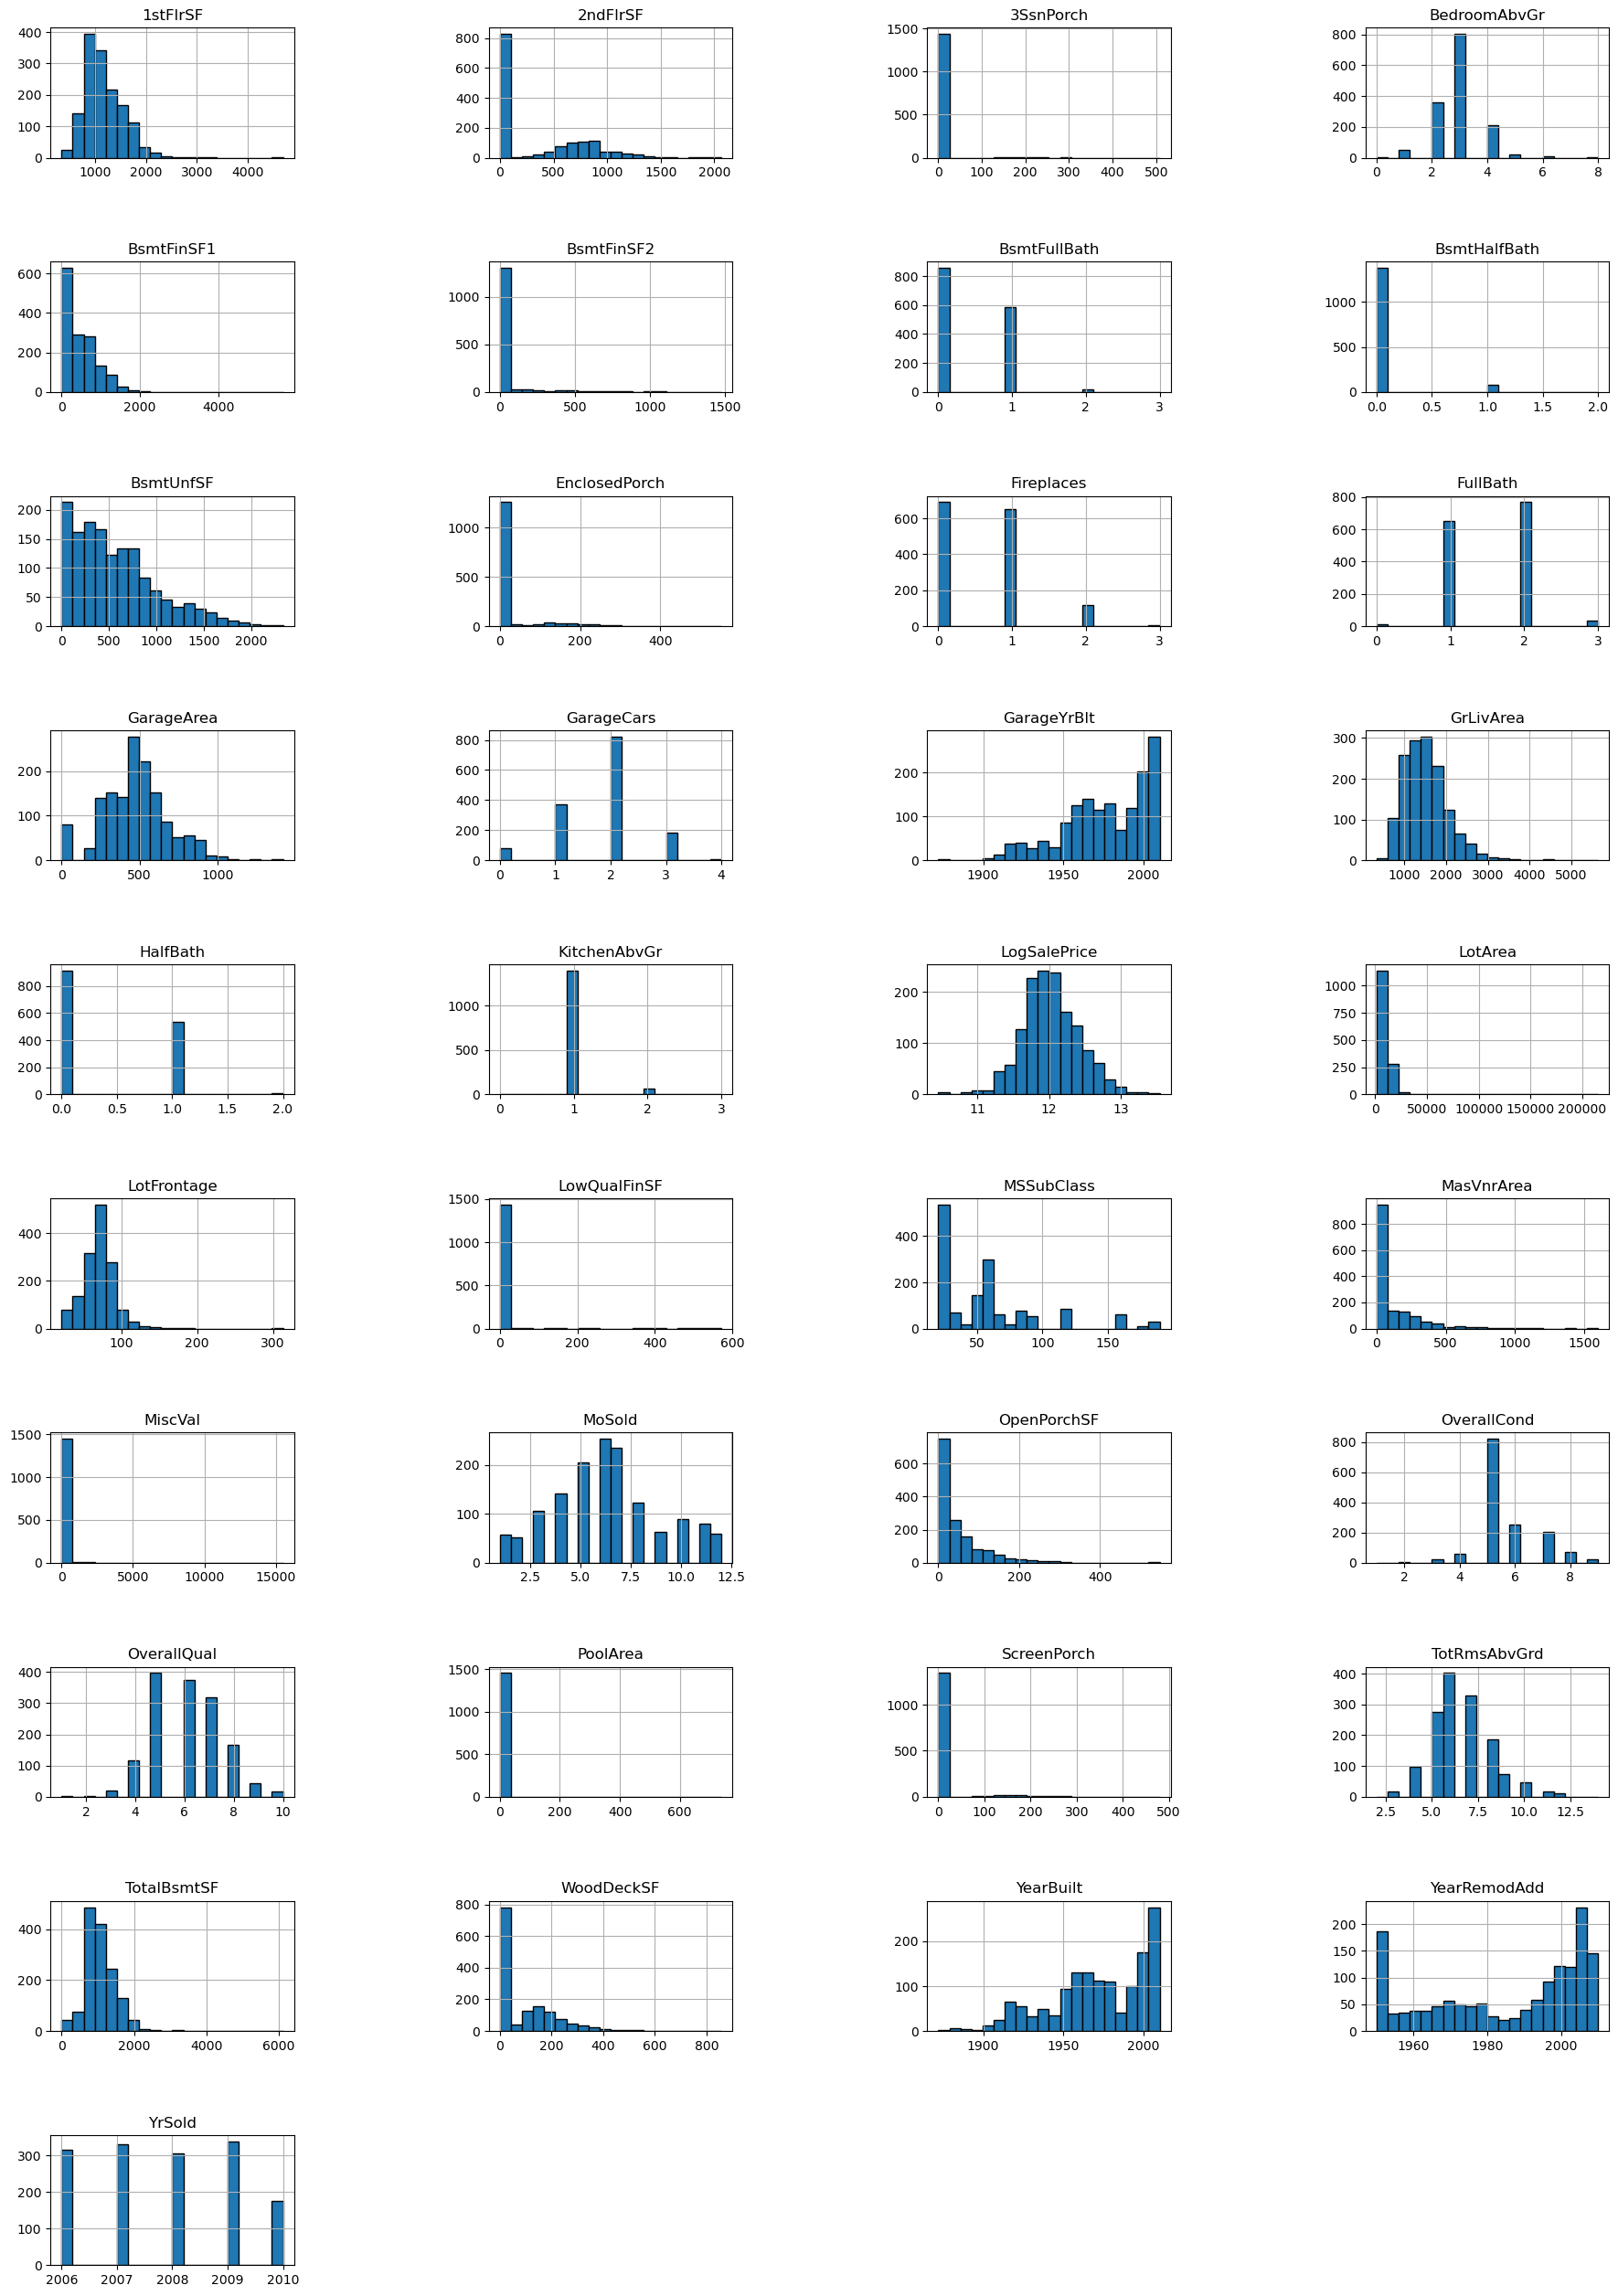

In [59]:
def plot_univariate_numerical_features(df:pd.DataFrame,nrows:int=10, ncol: int=4, figsize: tuple=(22,36),bins:int=20) -> None:    
    numeric_df = df.select_dtypes(include='number')
    numeric_df.hist(bins=bins, figsize=figsize,edgecolor='black',layout=(nrows,ncol))
    plt.subplots_adjust(hspace=0.8,wspace=0.8, bottom=0.2)



plot_univariate_numerical_features(numeric_df)

**Scatter plot for Numerical Features vs Salesprice**

In [60]:
numeric_df.columns

Index(['1stFlrSF', '2ndFlrSF', '3SsnPorch', 'BedroomAbvGr', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF',
       'EnclosedPorch', 'Fireplaces', 'FullBath', 'GarageArea', 'GarageCars',
       'GarageYrBlt', 'GrLivArea', 'HalfBath', 'KitchenAbvGr', 'LogSalePrice',
       'LotArea', 'LotFrontage', 'LowQualFinSF', 'MSSubClass', 'MasVnrArea',
       'MiscVal', 'MoSold', 'OpenPorchSF', 'OverallCond', 'OverallQual',
       'PoolArea', 'ScreenPorch', 'TotRmsAbvGrd', 'TotalBsmtSF', 'WoodDeckSF',
       'YearBuilt', 'YearRemodAdd', 'YrSold'],
      dtype='object')

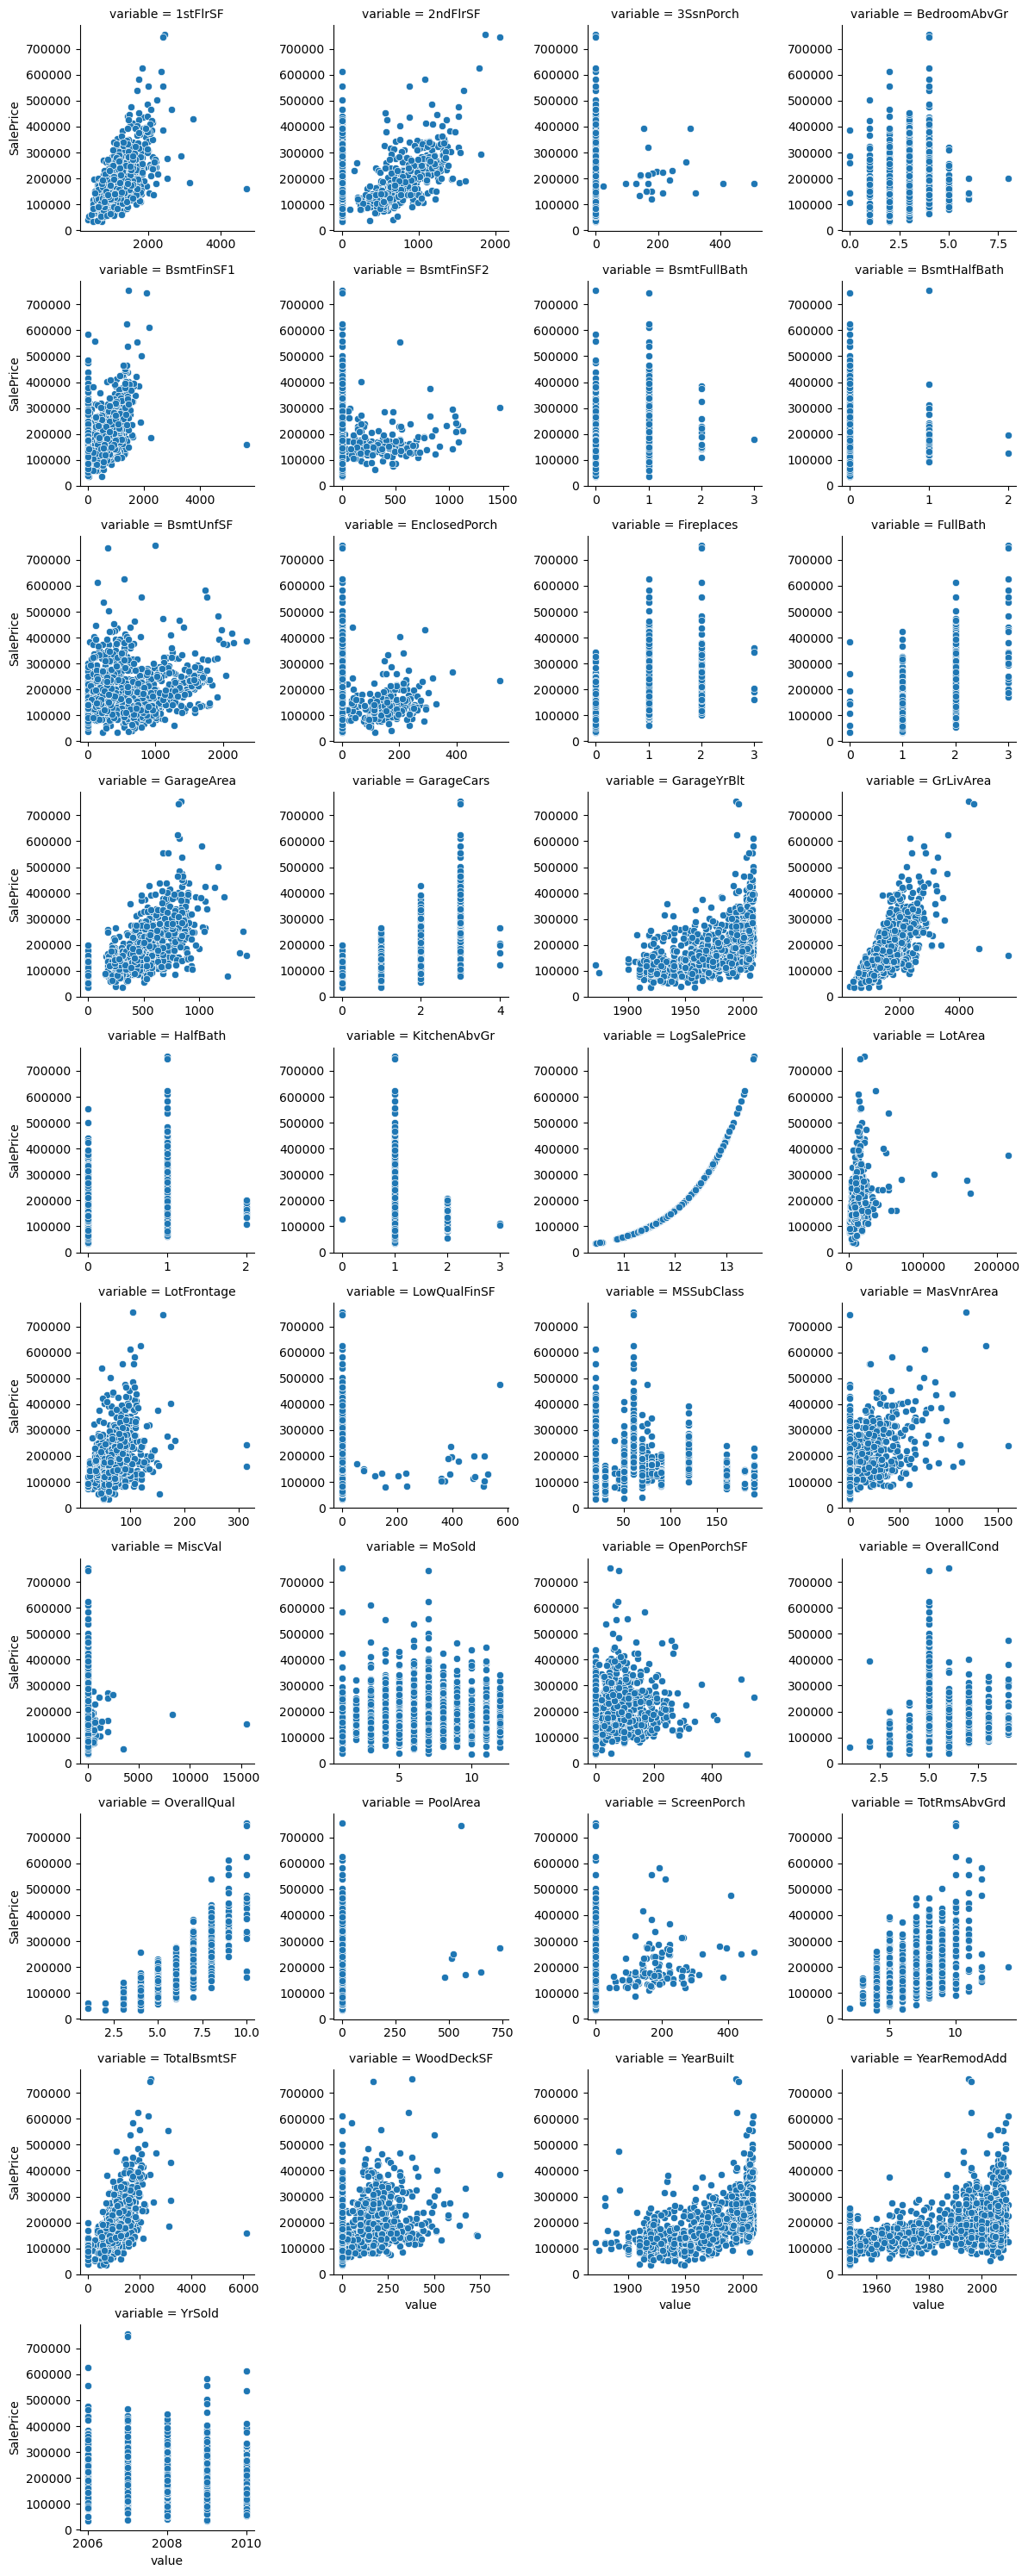

In [61]:
nd = pd.melt(df_train,id_vars='SalePrice',value_vars=numeric_df.columns)
g = sns.FacetGrid(nd, col='variable',col_wrap=4,sharex=False,sharey=False)
n1 = g.map_dataframe(sns.scatterplot,x='value',y='SalePrice')
n1

**Distibution of Categorical dimensions**

In [62]:
cat_df = df_train.select_dtypes(exclude='number')
cat_df.dtypes.value_counts()

object    43
Name: count, dtype: int64

In [63]:
def plot_categorical_dimensions(df:pd.DataFrame) -> None:  
    cat_df = df.select_dtypes(include='object')
    nd_cat = pd.melt(cat_df, value_vars=cat_df.columns)
    fig = plt.figure(figsize=(10,6))
    n2 = sns.FacetGrid(nd_cat, col='variable',col_wrap=4,sharex=False,sharey=False)
    n2 = n2.map_dataframe(sns.countplot, 'value')
    n2.set_xticklabels(rotation=60)
    fig.subplots_adjust(bottom=0.3)
    n2.tight_layout()
 

<Figure size 1000x600 with 0 Axes>

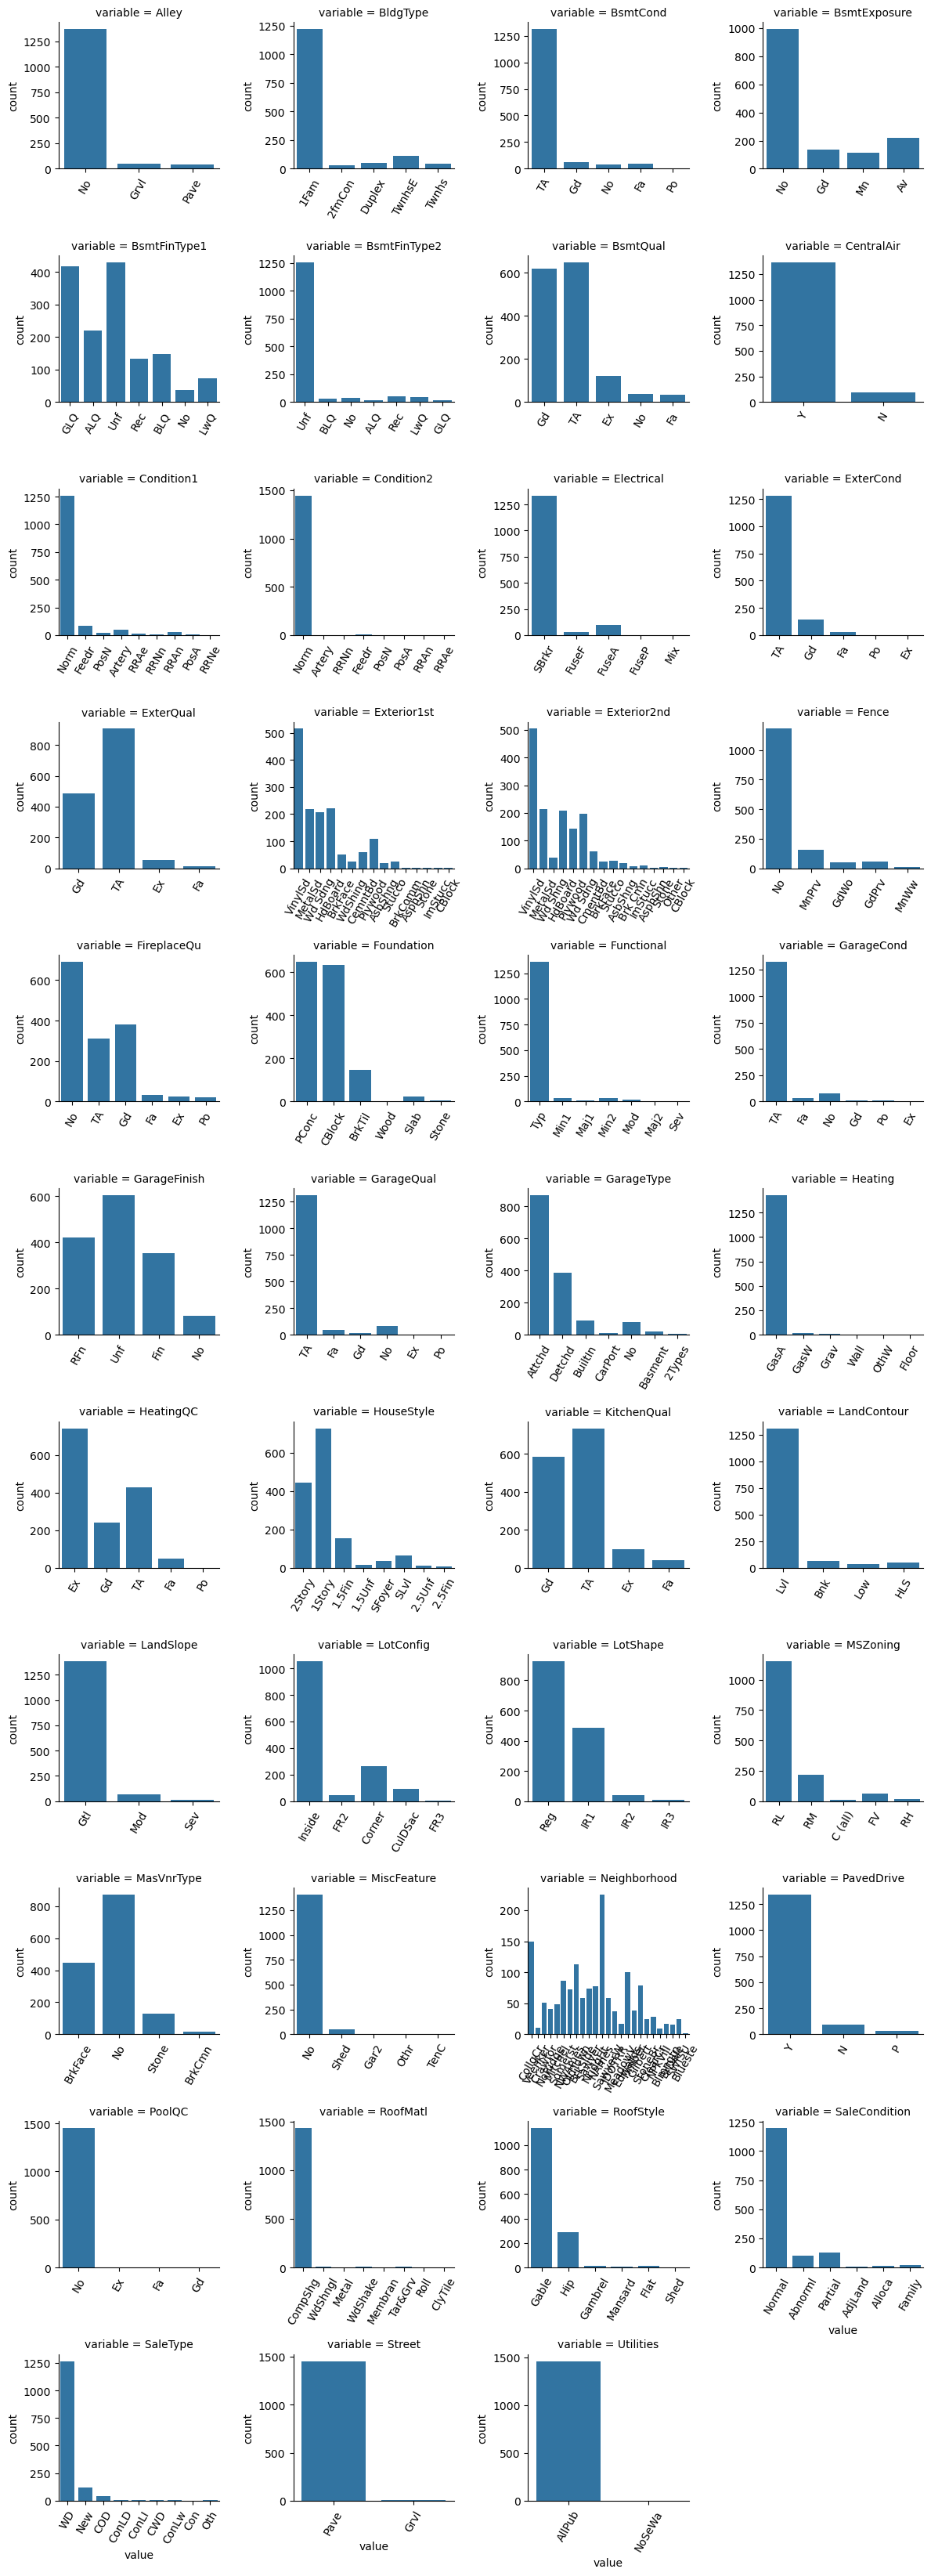

In [64]:
plot_categorical_dimensions(df_train)

**Box plot for categorical dimensions vs Saleprice**

<Figure size 1000x400 with 0 Axes>

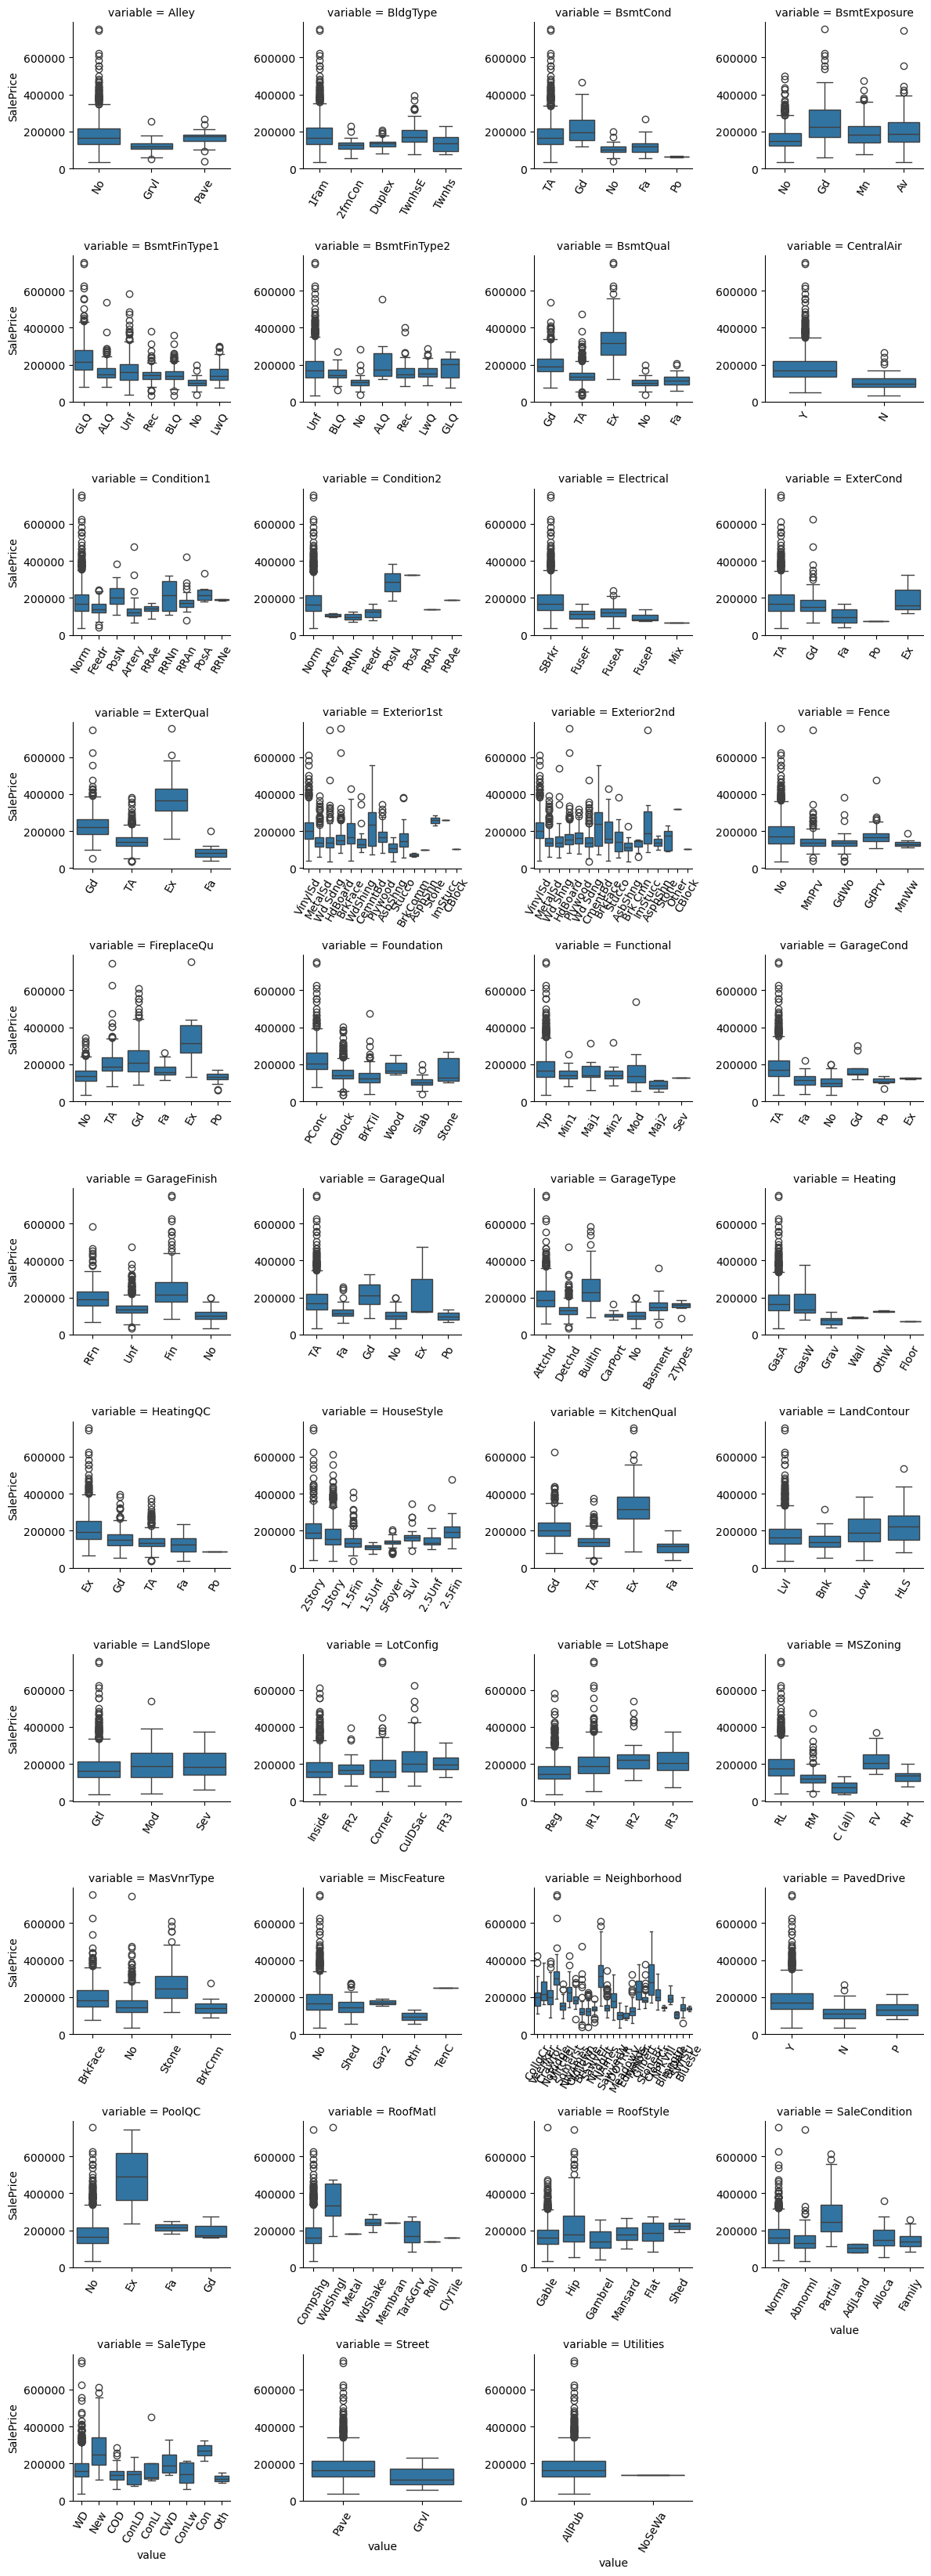

In [65]:
cat_df = df_train.select_dtypes(include='object')
cat_nd = pd.melt(df_train,id_vars='SalePrice',value_vars=cat_df.columns)
fig = plt.figure(figsize=(10,4))
n3 = sns.FacetGrid(cat_nd,col='variable',col_wrap=4, sharex=False,sharey=False)
n3 = n3.map_dataframe(sns.boxplot,'value','SalePrice')
n3.set_xticklabels(rotation=60)
fig.subplots_adjust(bottom=0.3)
n3.tight_layout()


**Number of property sold By Month and Year**

In [66]:
df_train.columns[(df_train.columns.str.contains(pat='mo|yr',case=False))] 

Index(['GarageYrBlt', 'MoSold', 'YearRemodAdd', 'YrSold'], dtype='object')

In [67]:
df_train[['YearRemodAdd', 'GarageYrBlt', 'MoSold', 'YrSold']].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   YearRemodAdd  1460 non-null   int64  
 1   GarageYrBlt   1460 non-null   float64
 2   MoSold        1460 non-null   int64  
 3   YrSold        1460 non-null   int64  
dtypes: float64(1), int64(3)
memory usage: 45.8 KB


In [68]:
date_df = pd.crosstab(numeric_df['MoSold'],numeric_df['YrSold'])
date_df.style.highlight_max(axis='index',color='blue').highlight_min(axis='index',color='red')

YrSold,2006,2007,2008,2009,2010
MoSold,,,,,
1,10,13,13,12,10
2,9,8,10,10,15
3,25,23,18,19,21
4,27,23,26,26,39
5,38,43,38,37,48
6,48,59,51,59,36
7,67,51,49,61,6
8,23,40,29,30,0
9,15,11,17,20,0


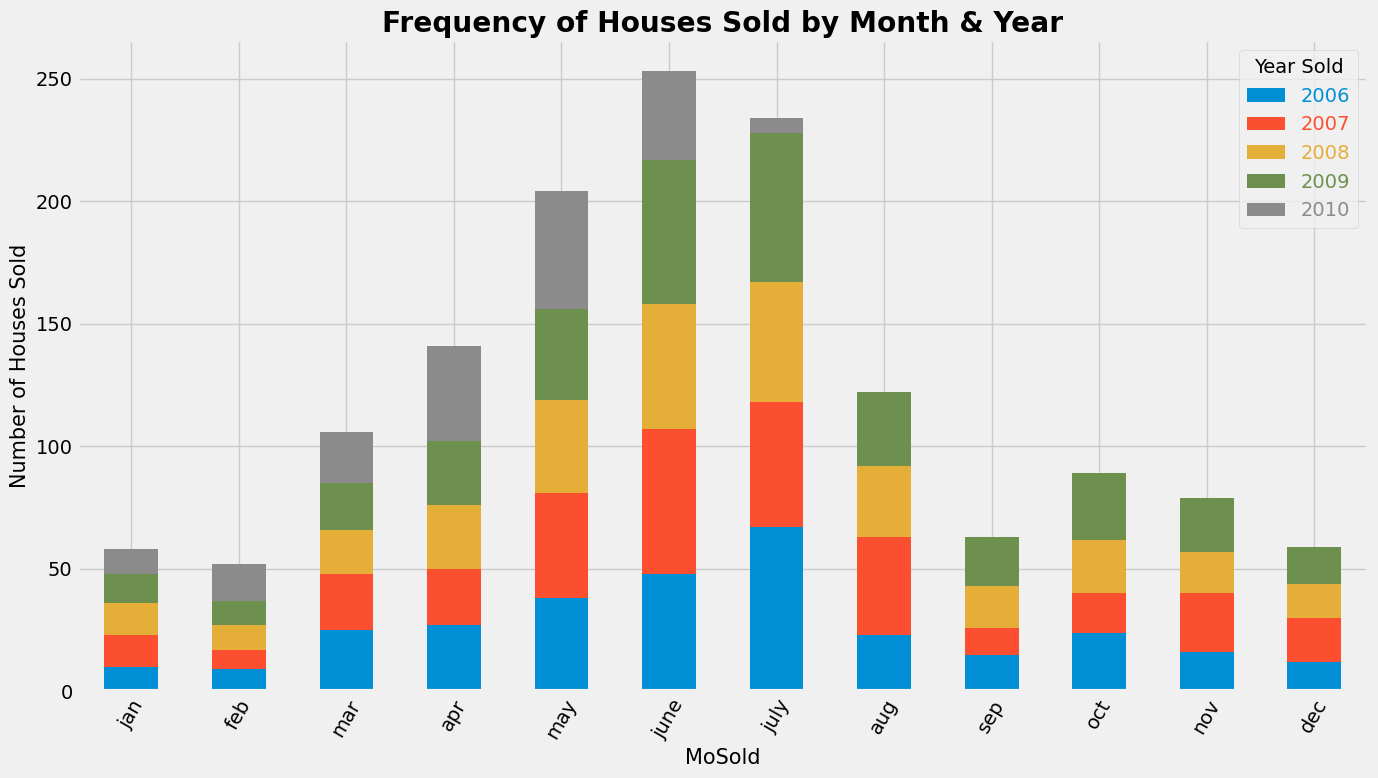

In [69]:
plt.style.use('fivethirtyeight')
date_df.plot(kind='bar',stacked=True,figsize=(14,8))
plt.gca().set_xticks(ticks=np.arange(0,12,1),labels=['jan','feb','mar','apr','may','june','july','aug','sep','oct','nov','dec'],rotation=60)
plt.title('Frequency of Houses Sold by Month & Year',fontweight='bold',loc='center')
plt.ylabel('Number of Houses Sold',fontsize=15)
plt.xlabel('MoSold',fontsize=15)
plt.legend(labelcolor='linecolor',title='Year Sold')
plt.tight_layout()
plt.show()

- **No Sales happened in year 2010 from August to December.**

**SalePrice Behaviour accross Months and Years**

In [70]:
sale_df = pd.pivot_table(data=df_train,index='MoSold',columns='YrSold',values='SalePrice',fill_value=0)
sale_df.style.highlight_max(axis='index',color='blue').highlight_min(axis='index',color='red').format(precision=2)

YrSold,2006,2007,2008,2009,2010
MoSold,,,,,
1,201090.00,183234.62,178504.69,189735.50,163852.60
2,194322.22,176301.75,159370.00,187450.00,174823.33
3,184982.20,176567.78,178505.28,171547.37,203181.29
4,174312.81,170772.61,159293.35,181680.77,171344.03
5,158928.29,169873.51,188334.47,164482.95,178422.25
6,172283.33,179725.81,169730.94,183260.93,181639.58
7,183211.06,195396.84,174562.65,197984.41,121750.00
8,196239.96,183941.08,196076.97,165670.97,0.00
9,223768.87,195533.82,169626.47,196849.35,0.00


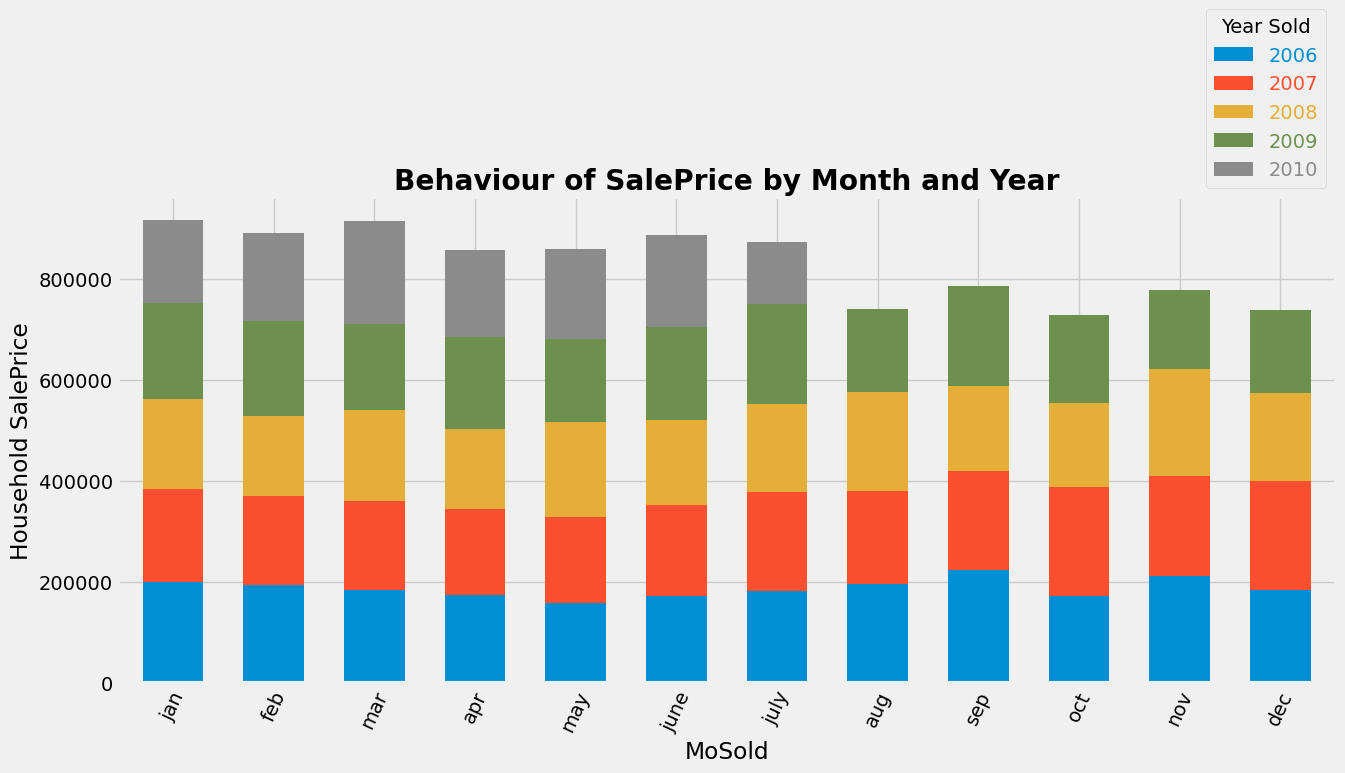

In [71]:
sale_df.plot(kind='bar',stacked=True,width=0.6,figsize=(14,6))
plt.xticks(ticks=np.arange(0,12,1),labels=['jan','feb','mar','apr','may','june','july','aug','sep','oct','nov','dec'],rotation=65)
plt.ylabel('Household SalePrice')
plt.title('Behaviour of SalePrice by Month and Year',fontweight='bold')
plt.legend(loc='lower right',bbox_to_anchor = (1,1),title='Year Sold',labelcolor='linecolor')
plt.show()

**Check Duplicates**

In [72]:
df_train.duplicated().sum()

0

In [73]:
df_test.duplicated().sum()

0

**Outliers in columns before Missing value Imputation**

In [74]:
"""
Calculate the percentage of outliers based on winsorization method for all the numerical features in the DataFrame.

Parameters:
df(pd.DataFrame): The input DataFrame containing numerical features.
lower_percentile(float): The lower percentile foe winsorization. Default is 5.
upper_percentile(float): The upper percentile for winsorization. Default is 95.

Returns:
pd.DataFrame : A DataFrame containing the columns name and percentage of outliers for each numerical features.
"""

#numeric_df = df_train[df_train.columns.difference(['SalePrice'])]
numeric_df = numeric_df.select_dtypes(include='number')
outliers_percentages = {}
for col in numeric_df.columns:
    x_low, x_high = np.percentile(numeric_df[col].dropna(),[1,99])
    total_values = len(numeric_df[col])
    outliers = len(numeric_df[~numeric_df[col].between(x_low,x_high)])
    outliers_percentage = round((outliers / total_values)*100 , 2)
    outliers_percentages[col] = outliers_percentage
    
outliers_df = pd.DataFrame(list(outliers_percentages.items()), columns=['Features','Outliers Percentage'])
print(outliers_df.sort_values(by='Outliers Percentage', ascending=False).reset_index(drop=True))



         Features  Outliers Percentage
0    LogSalePrice                 2.05
1       GrLivArea                 2.05
2        1stFlrSF                 1.85
3         LotArea                 1.51
4     GarageYrBlt                 1.23
5       YearBuilt                 1.10
6      BsmtFinSF1                 1.03
7        2ndFlrSF                 1.03
8      MasVnrArea                 1.03
9     OpenPorchSF                 1.03
10     GarageArea                 1.03
11    LotFrontage                 1.03
12    TotalBsmtSF                 1.03
13  EnclosedPorch                 1.03
14      BsmtUnfSF                 1.03
15     WoodDeckSF                 1.03
16     BsmtFinSF2                 1.03
17    ScreenPorch                 1.03
18        MiscVal                 0.96
19   LowQualFinSF                 0.96
20   BedroomAbvGr                 0.96
21      3SsnPorch                 0.89
22   TotRmsAbvGrd                 0.89
23       HalfBath                 0.82
24       FullBath        

## Missing Value Analysis and Treatment

In [75]:
def plot_null_counts(df: pd.DataFrame, top_n: int = 15) -> pd.DataFrame: 
    null_info = df.stb.missing().reset_index().rename({'index':'Features'},axis='columns').sort_values(by='percent',ascending=False)
    null_info['columns_dtype'] = [df[col].dtype for col in null_info['Features']]

    null_info = null_info.loc[null_info['missing']>0].head(top_n)
    print(null_info)

    plt.figure(figsize=(8,6))
    sns.barplot(x='percent', y='Features',data=null_info)
    plt.title('Top Features with Highest Percentage of Null Values')
    plt.xlabel('% Null Values')
    plt.ylabel('Features')
    plt.tight_layout()
    plt.show()
    return

Empty DataFrame
Columns: [Features, missing, total, percent, columns_dtype]
Index: []


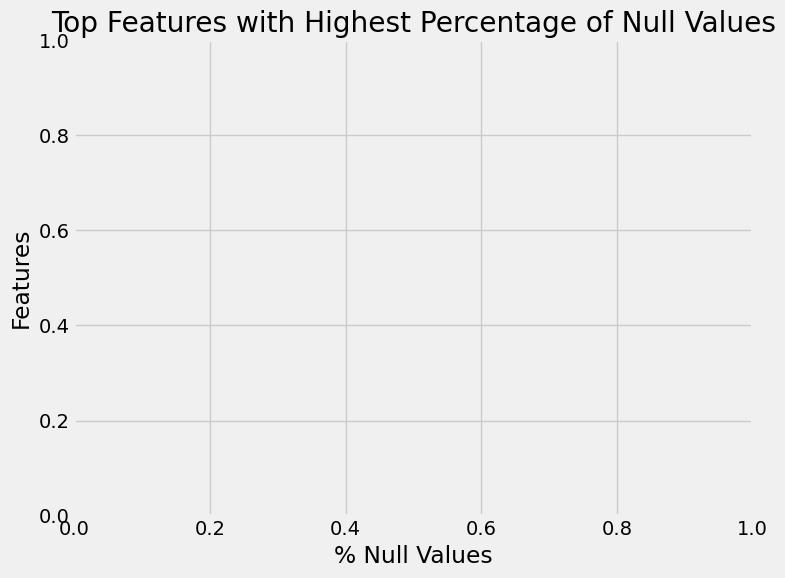

In [76]:
plot_null_counts(df_train)

**Most(>50%) missing values are of categorical features.**

In [77]:
"""
Fill missing  values in DataFrame for both categorical and numerical features based on particular rules.

Parameters:
    df(pd.DataFrame): The input DataFrame with missing values.
    cat_threshold(float): The threshold for handling missing values in categorical features.

Returns:
    pd.DataFrame 
    A dataframe with no missing values.

Rules for missing values:
1. Categorical Featues:
    - if missing values are less than threshold, fill with overall mode value of the column.
    - if greater than threshold, fill with unkown.
2. LotFrontage and GarageYrBlt:
   - Fill using groupby median based on relevent or related columns.
3. Other numeric columns:
   - Fill missing value with the overall missing value of the column.

"""

def fill_missing_values(df:pd.DataFrame, cat_threshold: float = 0.5) -> pd.DataFrame:

    # Make acopy of original DataFrame
    X = df.copy()


    cat_df = df.select_dtypes(include=['object','category'])
    numeric_df = df.select_dtypes(include=['number'])

    # Handle missing values in categorical features
    for col in cat_df.columns:
        if cat_df[col].isnull().sum()/len(cat_df) < cat_threshold:
            df[col].fillna(df[col].mode()[0],inplace=True)
        else:
            df[col].fillna('unknown',inplace=True)
    
    # Handle missing values in numerical features
    # Handle 'LotFrontage' with groupby median imputation
    if 'LotFrontage' in numeric_df.columns:
        df['LotFrontage'] = df.groupby('Neighborhood')['LotFrontage'].transform(lambda x: x.fillna(x.median()))
        
    # Handle other numeric columns with median imputation
    for col in numeric_df.columns.difference(['LotFrontage']):
        if df[col].isnull().sum()>0:
            df[col] = df[col].fillna(df[col].median())
    return 

In [78]:
fill_missing_values(df_train)

In [79]:
df_train.isnull().sum().any().sum() # no missing values in dataframe so missing Analysis and Treatment is done.

0

## Outlier Analysis and Treatment

Lets look at percentage of possible outliers in numerical features. 

In [80]:
"""
Calculate the percentage of outliers based on winsorization method for all the numerical features in the DataFrame.

Parameters:
df(pd.DataFrame): The input DataFrame containing numerical features.
lower_percentile(float): The lower percentile foe winsorization. Default is 5.
upper_percentile(float): The upper percentile for winsorization. Default is 95.

Returns:
pd.DataFrame : A DataFrame containing the columns name and percentage of outliers for each numerical features.
"""
def calculate_outlier_percentage(df:pd.DataFrame, lower_percentile: float=1, upper_percentile: float=99) -> pd.DataFrame:
    
    numeric_df = df.select_dtypes(include='number').columns
    var = []
    outlier = []
    
    #df = X.copy()
    for col in numeric_df:

        x_low, x_high = np.percentile(df[col],[1,99])
        total_values = len(df[col])
        outliers = len(df[~df[col].between(x_low,x_high)])
        outliers_percentage = round((outliers / total_values)*100 , 2)
        var.append(col)
        outlier.append(outliers_percentage)
    
    outliers_df = pd.DataFrame(zip(var, outlier), columns = ['Features', 'Outliers Percentage'])
    return outliers_df

anamoly_df = calculate_outlier_percentage(df_train)
print(anamoly_df.sort_values(by='Outliers Percentage', ascending=False).reset_index(drop=True))


         Features  Outliers Percentage
0    LogSalePrice                 2.05
1       GrLivArea                 2.05
2       SalePrice                 2.05
3        1stFlrSF                 1.85
4         LotArea                 1.51
5     GarageYrBlt                 1.23
6       YearBuilt                 1.10
7      BsmtFinSF1                 1.03
8      WoodDeckSF                 1.03
9     TotalBsmtSF                 1.03
10    ScreenPorch                 1.03
11    OpenPorchSF                 1.03
12     MasVnrArea                 1.03
13     BsmtFinSF2                 1.03
14       2ndFlrSF                 1.03
15    LotFrontage                 1.03
16     GarageArea                 1.03
17      BsmtUnfSF                 1.03
18  EnclosedPorch                 1.03
19   BedroomAbvGr                 0.96
20   LowQualFinSF                 0.96
21        MiscVal                 0.96
22      3SsnPorch                 0.89
23   TotRmsAbvGrd                 0.89
24       HalfBath        

In [81]:
# Exclude this outliers from the DataFrame
df_new = df_train[~((df_train['LotFrontage'] > 300) | (df_train['LotArea'] > 100000) | (df_train['GrLivArea'] > 3200) | (df_train['MasVnrArea'] > 1500) | (df_train['OpenPorchSF'] > 500))]
df_new.shape


(1438, 81)

# Feature Engineering

**Create New Features**

In [82]:
df_new['TotalSqFt'] = df_new['TotalBsmtSF'] + df_new['1stFlrSF'] + df_new['2ndFlrSF']
df_new['YrRemodAge'] = df_new['YrSold'] - df_new['YearRemodAdd']
df_new['TotalBath'] = df_new['BsmtFullBath'] + 0.5 * df_new['BsmtHalfBath'] + df_new['FullBath'] + 0.5 * df_new['HalfBath']
df_new['HouseAge'] = df_new['YrSold'] - df_new['YearBuilt']
df_new['GarageAge'] = df_new['YrSold'] - df_new['GarageYrBlt']
df_new['TotalPorchSF']  = df_new['3SsnPorch'] + df_new['EnclosedPorch'] + df_new['OpenPorchSF'] + df_new['ScreenPorch']


In [83]:
X,y = (
    df_new[df_new.columns.difference(['SalePrice'])],
    df_new['SalePrice']
)

In [84]:
print(X.shape)
print(y.shape)

(1438, 86)
(1438,)


# Feature Selection

**For Numerical Features**

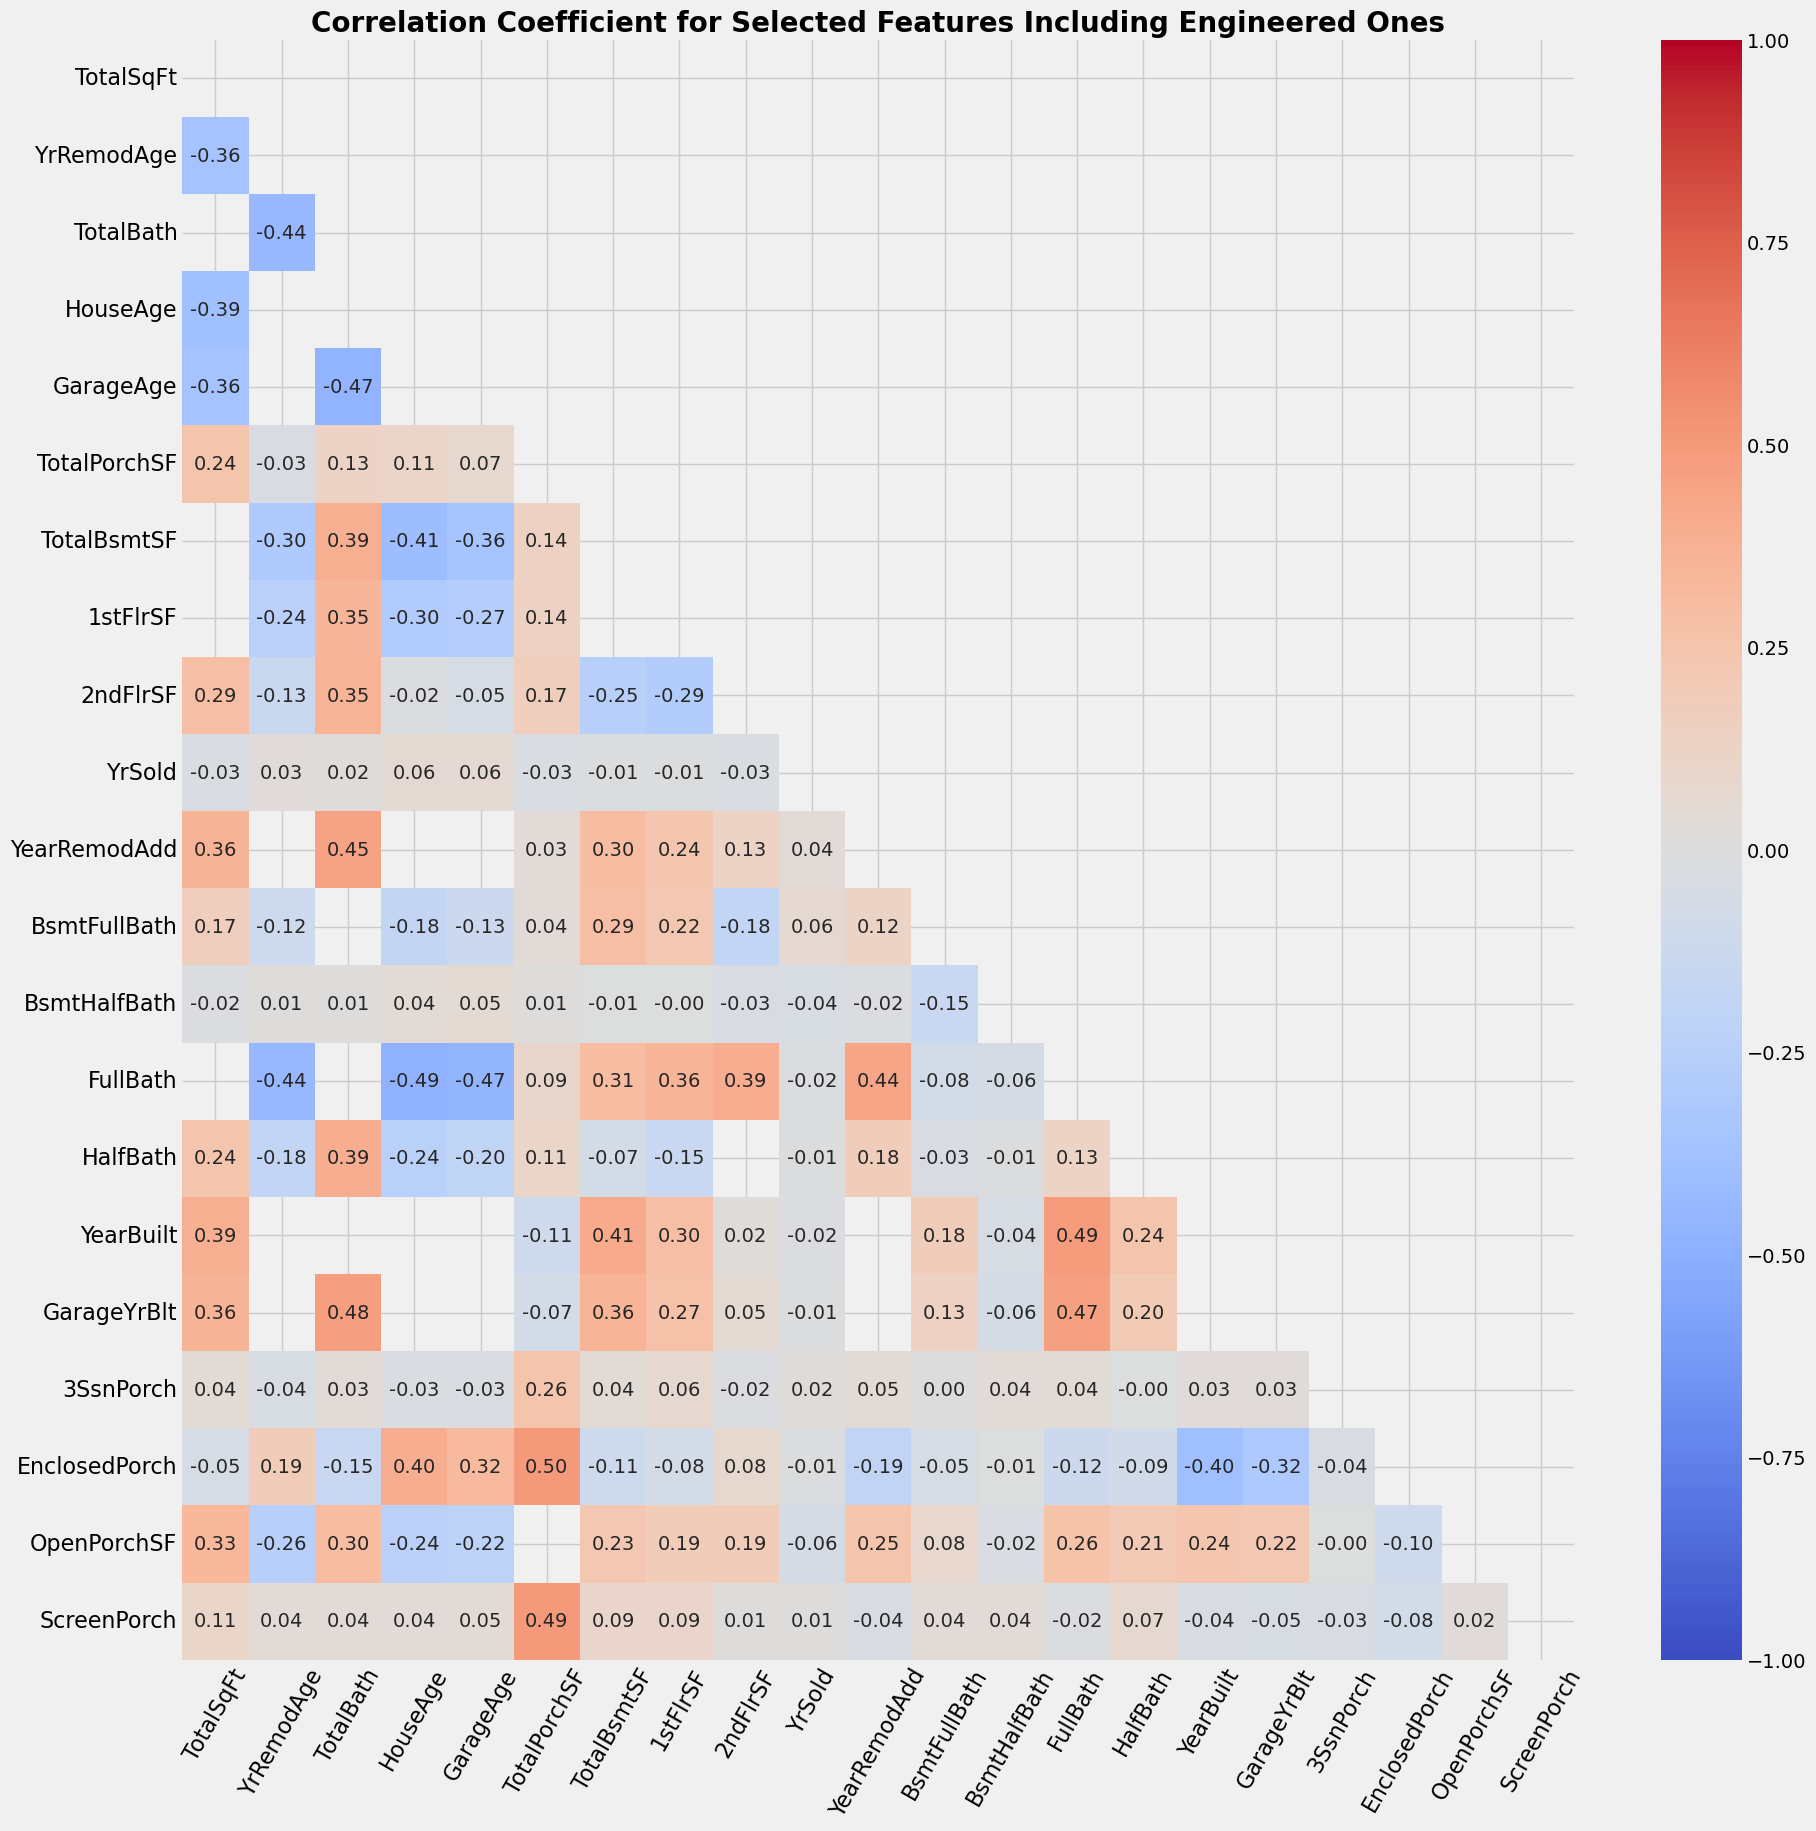

In [85]:
# Select old and new features
selected_features = ['TotalSqFt', 'YrRemodAge', 'TotalBath', 'HouseAge', 'GarageAge', 'TotalPorchSF','TotalBsmtSF','1stFlrSF','2ndFlrSF',
                    'YrSold','YearRemodAdd','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','YearBuilt','GarageYrBlt',
                    '3SsnPorch','EnclosedPorch','OpenPorchSF','ScreenPorch']
# Compute the correlations for the selected features
corr_matrix = X[selected_features].corr()

# Generate a mask for the  upper triangle
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# Generate heatmap
plt.figure(figsize=(20,20))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', mask=mask|(abs(corr_matrix)>0.5), cmap='coolwarm', vmin=-1, vmax=1, cbar=True)
plt.title('Correlation Coefficient for Selected Features Including Engineered Ones', fontsize=20, fontweight='bold')
plt.xticks(rotation=60, fontsize=16)
plt.yticks(fontsize=16)
plt.show()

## Selecting Top-n Numerical Features

**Use r_regression and f_regression from sklearn**

r_regression computes pearsons'r for each features and the target.

pearsons'r also known as Pearson Correlation Coefficient.

Linear model for testing the individual effect of each of many regressors.This is a scoring function to be used in feature selection procedure, not free standing feature selection procedure.

The cross correlation between each regressor and the target is computed as :

<span style="background-color: #00eeee">E[(X[:, i] - mean(X[:, i]))*(y-mean(y))] / (std(X[:, i])*std(y))</span>


**Feature Selection f_regression vs r_regression**

Both f_regression and r_regression are used to select feature selection based on linear relationship between the feature and the target variable.

- **f_regression** is preferred because it provides F-scores and p-values to access feature importance,independent
of positive and negative associations.

- **r_regression** computes Pearson correlation coefficient, returns values between -1 and 1, but lacks p-values and F-scores, making it less useful for assessing statistical significance.

For downstream estimators, **f_regression** is typically favored for its statistical rigor.

In [86]:
from sklearn.feature_selection import f_regression, r_regression

In [87]:
# Compute f_regression scores
f_score, p_value = f_regression(X.select_dtypes(include='number'),y)


# Create DataFrame with scores
df_score = pd.DataFrame({'Feature':X.select_dtypes(include='number').columns,
                         'F-score':f_score, 'P-value':p_value})
df_score.sort_values(by=['F-score','P-value'],ascending=False,inplace=True)#.reset_index(drop=True)

# Select top features
top_feature = df_score#.head(35)
top_feature.reset_index(drop=True)

,Feature,F-score,P-value
0,LogSalePrice,15826.15,0.00
1,TotalSqFt,2909.35,0.00
2,OverallQual,2631.54,0.00
3,GrLivArea,1410.18,0.00
4,GarageCars,1062.05,0.00
5,TotalBsmtSF,1028.55,0.00
6,GarageArea,988.97,0.00
7,TotalBath,919.51,0.00
8,1stFlrSF,875.11,0.00
9,HouseAge,700.37,0.00


In [88]:
top_feature.tail(7)

,Feature,F-score,P-value
23,LowQualFinSF,5.88,0.02
2,3SsnPorch,3.98,0.05
7,BsmtHalfBath,1.90,0.17
31,PoolArea,1.84,0.17
42,YrSold,0.88,0.35
26,MiscVal,0.77,0.38
5,BsmtFinSF2,0.20,0.66


*****Feature Selection based on F-score and P-value*****

Based on F-scores and P-values, the following conclusions can be drawn:

**Features To Keep:**
    
- **'TotalSqFt', 'OverallQual', 'GrLivArea', 'GarageCars','TotalBsmtSF', 'GarageArea', 'TotalBath',etc.**
        
    - These features have high F-scores and low p-values(statistically significant), indicating they are important predictors.

**Features To Drop:**
   
- **'3SsnPorch', 'BsmtHalfBath', 'PoolArea', 'YrSold','MiscVal', 'BsmtFinSF2', etc.**
        
    - These features have low F-scores and high p-values(statistically insignificance), suggesting they have weak relationships with target variable.


In [89]:
# compute vif for all given features
def calculate_vif(df:pd.DataFrame):

    # select numeric columns
    num_df = df.select_dtypes(include='number')
    # the computation of variance inflatio required constant
    num_df['intercept'] = 1

    # create DataFrame to store vif values
    vif = pd.DataFrame()
    vif['Features'] = num_df.columns
    vif['VIF'] = [variance_inflation_factor(num_df.values, i) for i in range(num_df.shape[1])]
    vif = vif[vif['Features'] != 'intercept']
    return(vif)

# Criterion : Remove variable with vif > 5

In [90]:
vif_df = calculate_vif(X).sort_values(by='VIF',ascending=False)
vif_df.reset_index(drop=True)

,Features,VIF
0,1stFlrSF,inf
1,GrLivArea,inf
2,YrRemodAge,inf
3,YearRemodAdd,inf
4,YearBuilt,inf
5,TotalSqFt,inf
6,TotalPorchSF,inf
7,TotalBsmtSF,inf
8,TotalBath,inf
9,ScreenPorch,inf


In [91]:
vif_df.nlargest(26, 'VIF')['Features'].to_list() # top 26 features with highest VIF

['1stFlrSF',
 'GrLivArea',
 'YrRemodAge',
 'YearRemodAdd',
 'YearBuilt',
 'TotalSqFt',
 'TotalPorchSF',
 'TotalBsmtSF',
 'TotalBath',
 'ScreenPorch',
 'OpenPorchSF',
 'LowQualFinSF',
 '2ndFlrSF',
 'HouseAge',
 'HalfBath',
 'YrSold',
 'GarageYrBlt',
 'FullBath',
 'BsmtUnfSF',
 'BsmtHalfBath',
 'BsmtFullBath',
 'BsmtFinSF2',
 'BsmtFinSF1',
 'EnclosedPorch',
 'GarageAge',
 '3SsnPorch']

From the above VIF values, we can see that the following features have high multicollinearity:
'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'TotalSqFt'. These features are likely high correalted with each other, and we can consider keeping only one of them otherwise problematic for regression analysis. We might keep 'TotalSqFt' as it is the sum of all three features and has the highest VIF value and remove other features 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF' as they have lower F-values and p-values that might reduce VIF value.

To address this, we may consider removing some of these features or combining them to reduce redundancy. Features with lower VIF values, such as GarageCars, GarageArea and TotRmsAbvGrd, are less likely to suffer from multicollinearity.

In [92]:
df_new['TotalSqFt'] = df_new['TotalBsmtSF'] + df_new['1stFlrSF'] + df_new['2ndFlrSF']
df_new['YrRemodAge'] = df_new['YrSold'] - df_new['YearRemodAdd']
df_new['TotalBath'] = df_new['BsmtFullBath'] + 0.5 * df_new['BsmtHalfBath'] + df_new['FullBath'] + 0.5 * df_new['HalfBath']
df_new['HouseAge'] = df_new['YrSold'] - df_new['YearBuilt']
df_new['GarageAge'] = df_new['YrSold'] - df_new['GarageYrBlt']
df_new['TotalPorchSF']  = df_new['3SsnPorch'] + df_new['EnclosedPorch'] + df_new['OpenPorchSF'] + df_new['ScreenPorch']


In [93]:
top_feature.tail(9)['Feature'].to_list()

['MSSubClass',
 'MoSold',
 'LowQualFinSF',
 '3SsnPorch',
 'BsmtHalfBath',
 'PoolArea',
 'YrSold',
 'MiscVal',
 'BsmtFinSF2']

In [94]:
new_vif = calculate_vif(X.drop(columns=['TotalBsmtSF','1stFlrSF','2ndFlrSF','YrSold','YearRemodAdd','BsmtFullBath','BsmtHalfBath','FullBath','HalfBath','YearBuilt','GarageYrBlt','YrSold',
                              '3SsnPorch','EnclosedPorch','OpenPorchSF','ScreenPorch','OverallCond','MSSubClass','MoSold','LowQualFinSF',
                              'PoolArea','MiscVal','BsmtFinSF2','BsmtUnfSF','BsmtFinSF1','BedroomAbvGr','GrLivArea','GarageAge','GarageArea','LotArea']))
new_vif = new_vif.sort_values(by='VIF',ascending=False).reset_index(drop=True)
new_vif

,Features,VIF
0,LogSalePrice,7.94
1,TotalSqFt,4.50
2,OverallQual,3.45
3,HouseAge,2.66
4,TotRmsAbvGrd,2.17
5,TotalBath,2.12
6,GarageCars,2.03
7,YrRemodAge,1.94
8,Fireplaces,1.43
9,KitchenAbvGr,1.31


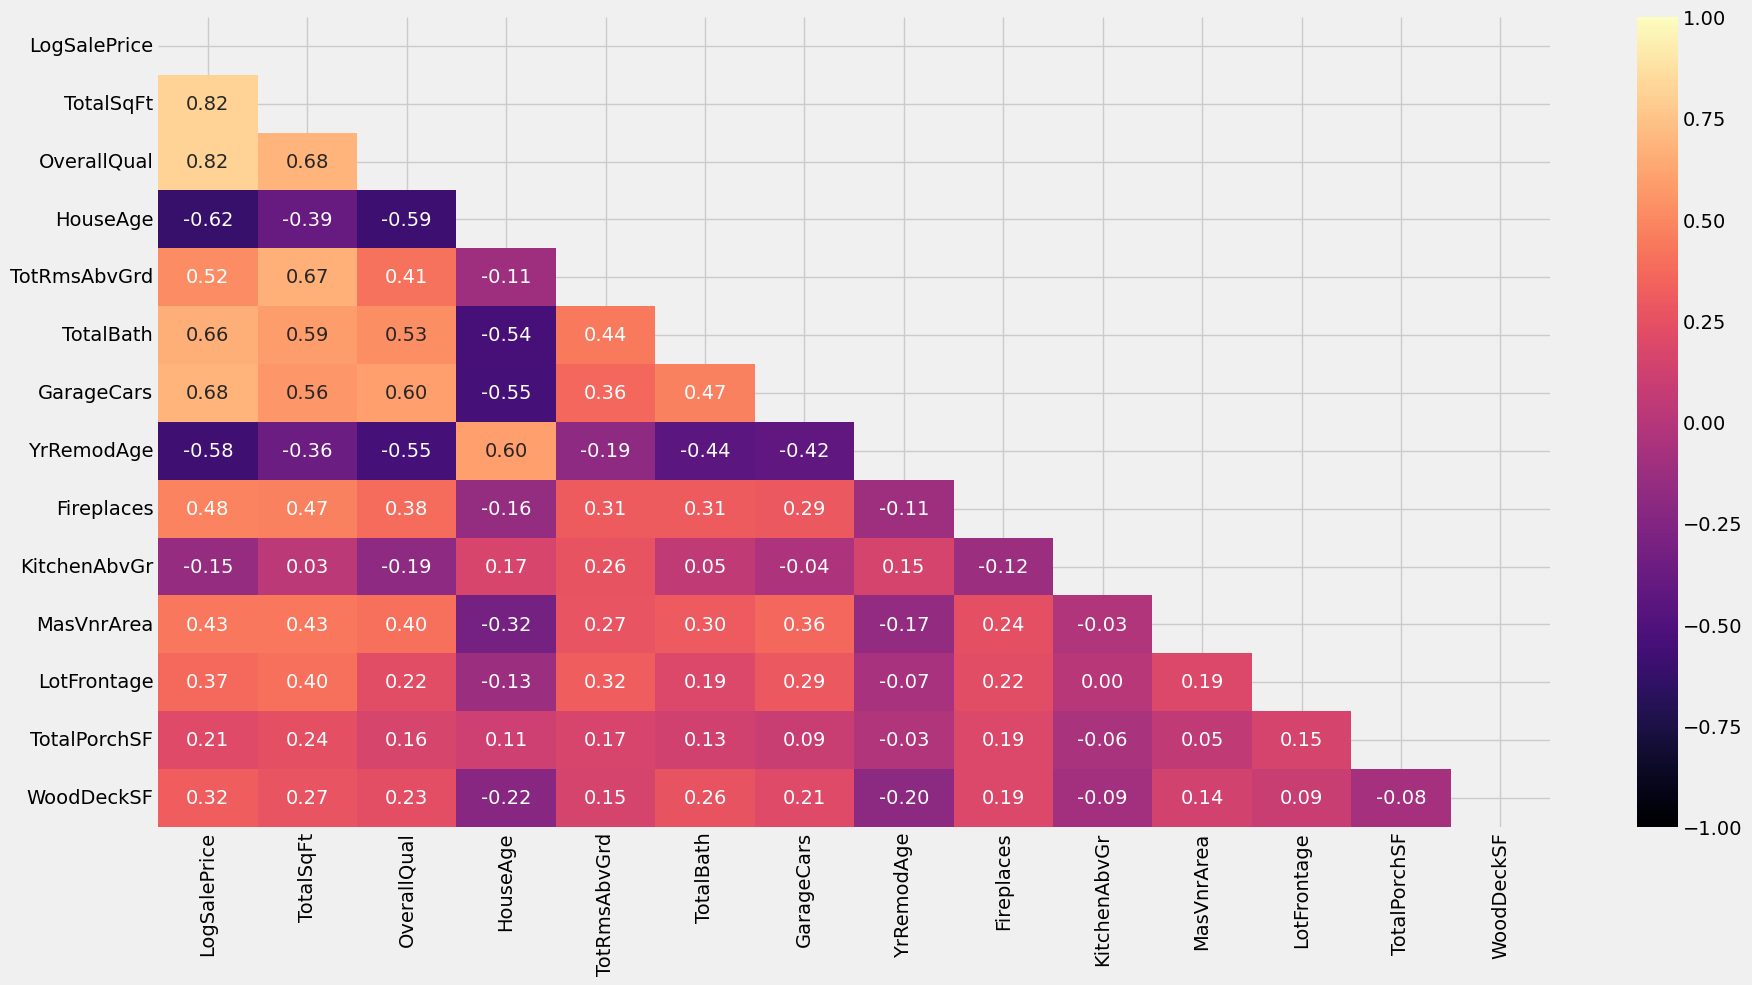

In [95]:
corr_df = X[new_vif['Features'].to_list()].corr().round(2)

mask = np.triu(np.ones_like(corr_df, dtype='bool'))

plt.figure(figsize=(20,10))
sns.heatmap(corr_df, annot=True, fmt='.2f', mask=mask, cmap='magma',vmin = -1,vmax=1)
plt.show()

## Selecting top-n Categorical Features

**Use Cramers_v and Anova Test**

**Cramers'V** is a measure of association between two categorical features that returns a value between 0(weak) and 1(strong)

In [96]:
def cramers_v(x, y):
    """Calculate Cramér's V for two categorical variables."""
    confusion_matrix = pd.crosstab(x, y)
    chi2, p, dof, expected = chi2_contingency(confusion_matrix)
    n = confusion_matrix.sum().sum()
    minDim = min(confusion_matrix.shape) - 1
    V = np.sqrt((chi2 / n) / minDim)
    return V, p

def filter_strong_associations(df, cramer_threshold = 0.3, p_value_threshold = 0.05):
    """
    Calculate Cramér's V and chi-squared test for each pair of categorical features and 
    return a DataFrame with pairs that have a Cramér's V value greater than cramer_threshold 
    and p-value less than p_value_threshold.
    
    Parameters:
    df (pd.DataFrame): The DataFrame containing the features.
    cramer_threshold (float, optional): The threshold for Cramér's V value. Default is 0.1.
    p_value_threshold (float, optional): The threshold for p-value. Default is 0.05.
    
    Returns:
    pd.DataFrame: A DataFrame with pairs of columns, Cramér's V values, and p-values.
    """
    categorical_columns = df.select_dtypes(include='object').columns
    results = []

    for col1, col2 in combinations(categorical_columns, 2):
        V, p = cramers_v(df[col1], df[col2])
        if V > cramer_threshold and p < p_value_threshold:
            results.append({'Column1': col1, 'Column2': col2, 'Cramérs_V': V, 'p-value': p})
    
    results_df = pd.DataFrame(results)
    return results_df

# Example usage
strong_associations = filter_strong_associations(df_train)
print(strong_associations)


          Column1       Column2  Cramérs_V  p-value
0           Alley      MSZoning       0.39     0.00
1           Alley  Neighborhood       0.45     0.00
2        BldgType  Neighborhood       0.44     0.00
3        BsmtCond  BsmtFinType1       0.51     0.00
4        BsmtCond  BsmtFinType2       0.50     0.00
5        BsmtCond      BsmtQual       0.53     0.00
6        BsmtCond    CentralAir       0.32     0.00
7        BsmtCond    Electrical       0.38     0.00
8        BsmtCond    Foundation       0.42     0.00
9    BsmtFinType1  BsmtFinType2       0.45     0.00
10   BsmtFinType1      BsmtQual       0.58     0.00
11   BsmtFinType1     ExterQual       0.30     0.00
12   BsmtFinType1    Foundation       0.46     0.00
13   BsmtFinType1  Neighborhood       0.32     0.00
14   BsmtFinType2      BsmtQual       0.50     0.00
15   BsmtFinType2    Foundation       0.37     0.00
16       BsmtQual     ExterQual       0.47     0.00
17       BsmtQual   Exterior1st       0.31     0.00
18       Bsm

In [97]:
def cramers_v(x,y):
    """Calculate Cramer's V statistic for two categorical variables."""
    confusion_matrix = pd.crosstab(x,y) # compute Contigency_table
    chi2, p, dof, expected = chi2_contingency(confusion_matrix) # compute chi2 statistic
    n = confusion_matrix.sum().sum() # total number of observations
    min_dim = min(confusion_matrix.shape) - 1 # minimum dimsension of the confusion matrix
    V = np.sqrt((chi2 / n) / min_dim) # Cramer's V statistic
    return V, p

def filter_strong_association(df:pd.DataFrame, cramers_v_threshold: float = 0.3, p_value_threshold: float = 0.05):
    """
    Calculate Cramers'V and chi-squared test for each pair of categorical features and return a DataFrame with
    pairs that have a Cramers'V value grater than cramers_v_threshold and p_value less than p_value_threshold.
    
    Parameters:
    df(pd.DataFrame): The input DataFrame containing categorical features.
    cramers_v_threshold(float) : The threshold of cramers'V value. Default is 0.1.
    p_value_thrshold(float): The threshold of p_value. Default is 0.5

    Returns:
    pd.DataFrame: A DataFrame containing pairs of categorical features with their Cramers'V values and p-values.
    """
    cat_var = df.select_dtypes(include='object').columns
    results = []

    for col1, col2 in combinations(cat_var, 2):
        V, p_value = cramers_v(df[col1], df[col2])
        if V > cramers_v_threshold and p_value < p_value_threshold:
            results.append({
                'Feature1': col1,
                'Feature2': col2,
                'Cramers_v': V,
                'P_value': p_value})
    
    results_df = pd.DataFrame(results)
    return results_df

# Example Usage
strong_association = filter_strong_association(df_train)
print(strong_association)

         Feature1      Feature2  Cramers_v  P_value
0           Alley      MSZoning       0.39     0.00
1           Alley  Neighborhood       0.45     0.00
2        BldgType  Neighborhood       0.44     0.00
3        BsmtCond  BsmtFinType1       0.51     0.00
4        BsmtCond  BsmtFinType2       0.50     0.00
5        BsmtCond      BsmtQual       0.53     0.00
6        BsmtCond    CentralAir       0.32     0.00
7        BsmtCond    Electrical       0.38     0.00
8        BsmtCond    Foundation       0.42     0.00
9    BsmtFinType1  BsmtFinType2       0.45     0.00
10   BsmtFinType1      BsmtQual       0.58     0.00
11   BsmtFinType1     ExterQual       0.30     0.00
12   BsmtFinType1    Foundation       0.46     0.00
13   BsmtFinType1  Neighborhood       0.32     0.00
14   BsmtFinType2      BsmtQual       0.50     0.00
15   BsmtFinType2    Foundation       0.37     0.00
16       BsmtQual     ExterQual       0.47     0.00
17       BsmtQual   Exterior1st       0.31     0.00
18       Bsm

In [98]:
def cramers_v(x,y):
    """ Calculate Cramers'V statistics for two categorical variables."""
    confusion_matrix = pd.crosstab(x,y) # compute contigency table
    chi2, p, dof, expected = stats.chi2_contingency(confusion_matrix) # compute chi2 statistics
    n = confusion_matrix.sum().sum() # total number of observations
    min_dim = min(confusion_matrix.shape) - 1 # minimum dimension of confusion matix
    V = np.sqrt((chi2 / n) / min_dim) # calculate cramers'V statistics
    return V

def visualization_cramers_v_matrix(df:pd.DataFrame):
    """
    Calculate Cramer's V matrix for all the pairs of categorical features.
     
    Parameters:
    df(pd.DataFrame): The input DataFrame containing categprical features.

    Returns:
    pd.DataFrame: A DataFrame contianing pairs of categorical features with their Cramers' V values greater than the cramers_v_threshold.
    """
    # Select categorical features
    cat_df = df.select_dtypes(exclude='number')
    cat_var = cat_df.columns
    cramers_result = pd.DataFrame(index=cat_var.to_list(), columns=cat_var.to_list())    
    
    for col1 in cat_var:
        for col2 in cat_var:
            if col1 != col2:
                cramers_result.loc[col1, col2]= cramers_v(cat_df[col1], cat_df[col2])
            else:
                cramers_result.loc[col1, col2] = 1

    cramers_result = cramers_result.astype('float')
    return cramers_result
    


In [99]:
cramers_results = visualization_cramers_v_matrix(df_train)
cramers_results = cramers_results[cramers_results.abs() > 0.45].fillna(0)
cramers_results.shape

(43, 43)

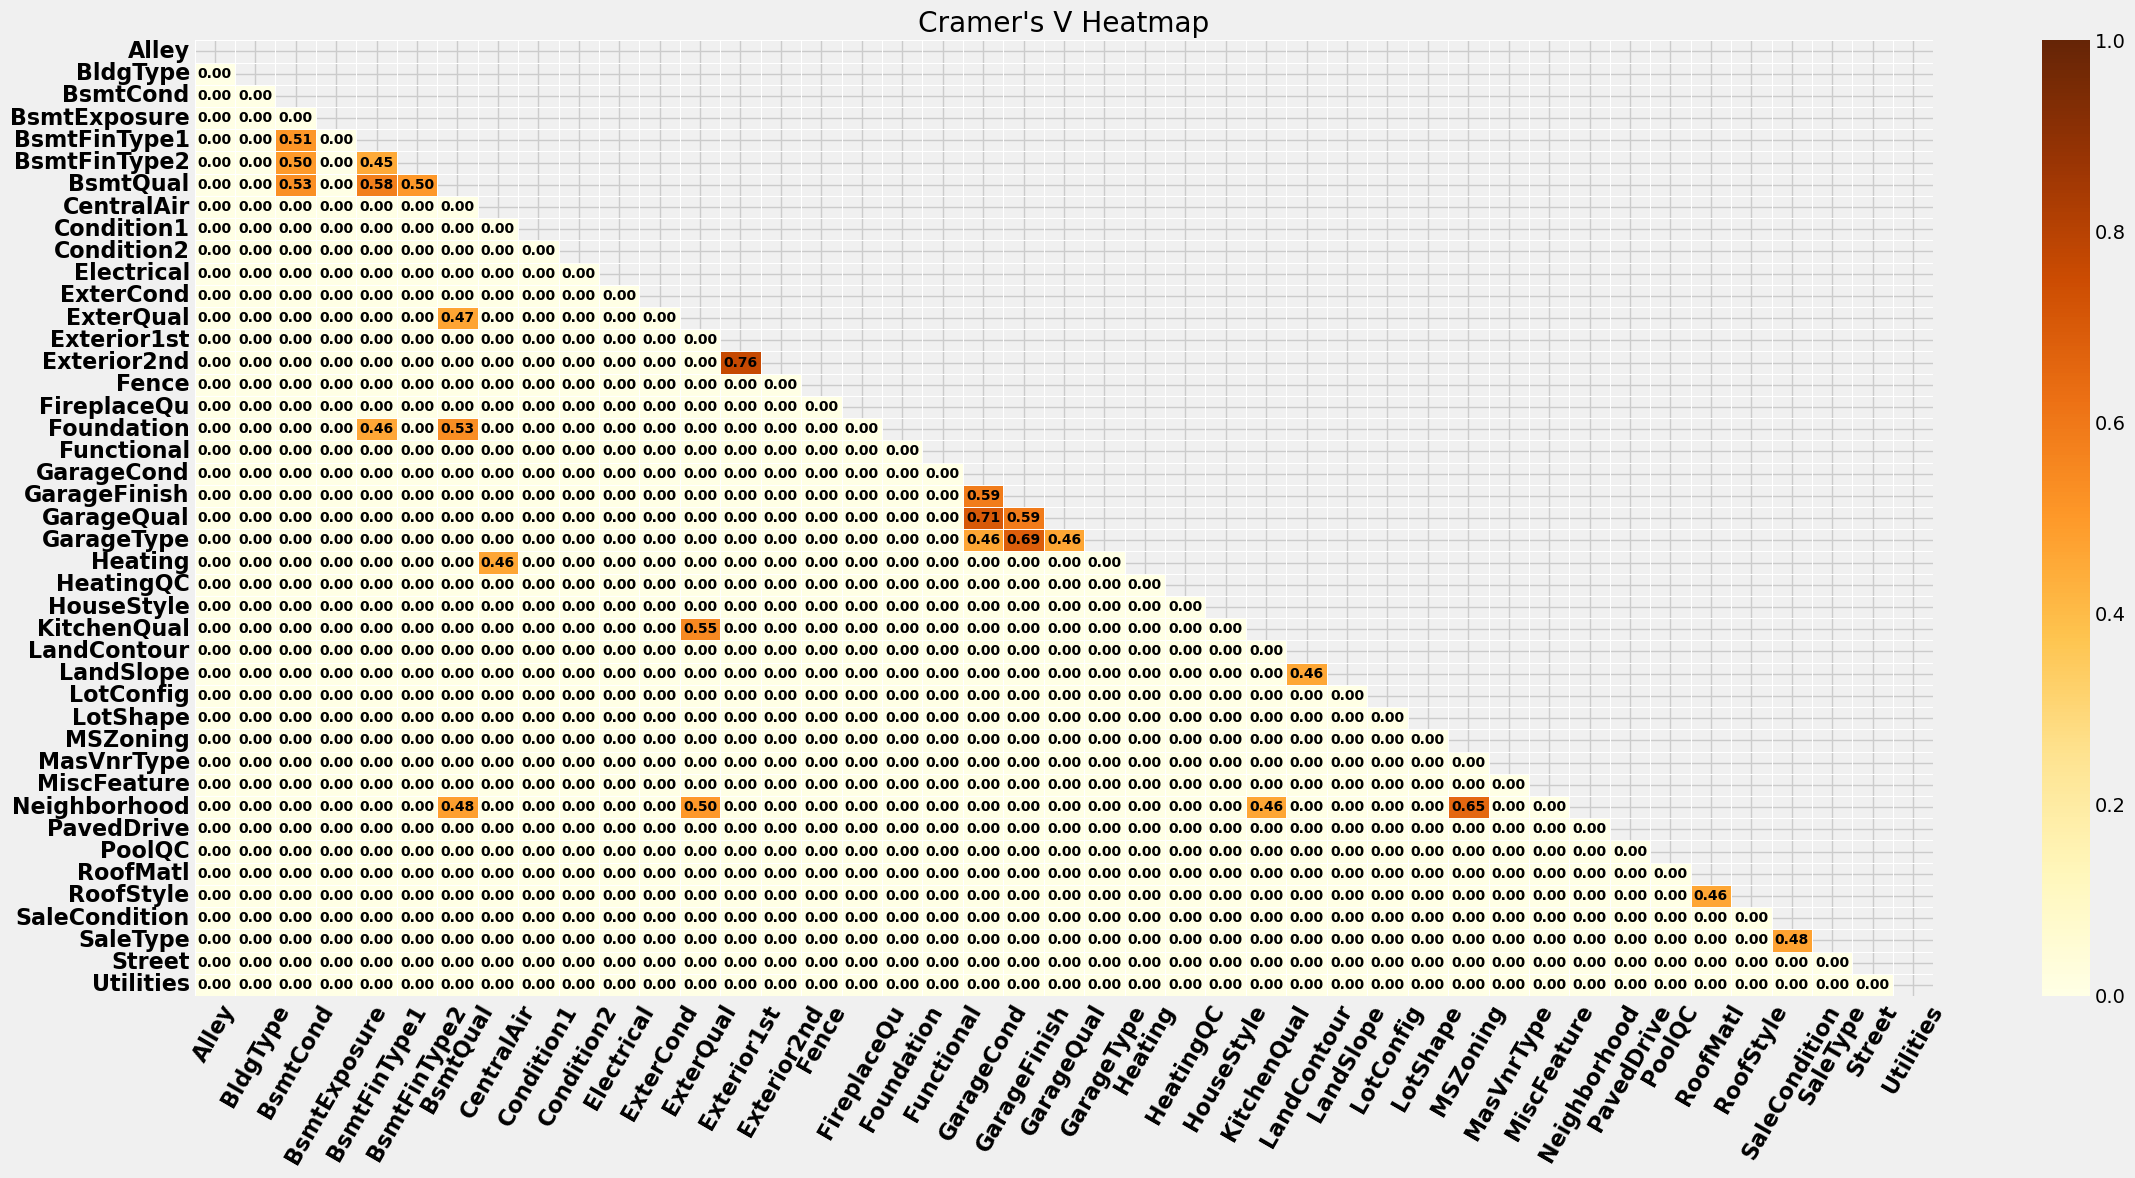

In [100]:
#cramers_results = visualization_cramers_v_matrix(df_train)
plt.figure(figsize=(24,12))
mask = np.zeros_like(cramers_results, dtype='bool')
mask[np.triu_indices_from(mask)] = True
sns.heatmap(cramers_results, annot=True,fmt='.2f',mask=mask, cmap='YlOrBr', 
            linewidths=0.5,vmin=0 ,vmax=1,annot_kws={'fontsize':10, 'fontweight': 'bold', 'color': 'black'})
plt.title("Cramer's V Heatmap")
plt.xticks(fontsize=16, fontweight='bold', rotation=60)
plt.yticks(fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


# Categorical Features Importance with Target Variable

In [101]:
def calculate_anova_test(df: pd.DataFrame, target: Union[str, pd.Series]) -> pd.DataFrame:
    """
    Perfrom ANOVA test to assess the realtionship between categorical features and a numerical target variable.

    Parameters:
    df(pd.DataFrame): The input DataFrame containing categorical features and a numerical target variable.
    target_variable(str or pd.Series): The name of the target variable or standalone series.

    Returns:
    pd.DataFrame: A DataFrame containg the ANOVA F-values and p-values for each categorical features.
    """
    # Check if target is a string(columns name) or a Series
    if isinstance(target, str):
        # Ensure the target variable in the DataFrame
        if target not in df.columns:
            raise ValueError(f"Target variable '{target}' is not found in the DataFrame.")
        target_data = df[target]
    elif isinstance(target, pd.Series):
        # if the target is a Series, use it directly
        target_data = target
    else:
        raise TypeError('Target variable must be a string or a pandas Series.')
    
    # Select Categorical features
    cat_columns = df.select_dtypes(include='object').columns

    # store results
    results = []

    for col in cat_columns:
        # Group the numerical data by the categorical column
        groups = [target_data[df[col] == category] for category in df[col].unique()]
        # Perform ANOVA test
        f_value, p_value = stats.f_oneway(*groups)
        # Append the results to the list
        results.append({
            'Feature': col,
            'F_value': f_value,
            'P_value': p_value
        })
    # Create a DataFrame from the results
    results_df = pd.DataFrame(results)
    # Sort the DataFrame by F_value and P_value in descending order
    results_df.sort_values(by=['F_value', 'P_value'], ascending=False,inplace=True)#.reset_index(drop=True)
    return results_df

In [102]:
anova_df = calculate_anova_test(df_train, 'SalePrice')
anova_df.reset_index(drop=True)

,Feature,F_value,P_value
0,ExterQual,443.33,0.00
1,KitchenQual,407.81,0.00
2,BsmtQual,316.15,0.00
3,GarageFinish,213.87,0.00
4,FireplaceQu,121.08,0.00
5,MasVnrType,108.91,0.00
6,Foundation,100.25,0.00
7,CentralAir,98.31,0.00
8,HeatingQC,88.39,0.00
9,GarageType,80.38,0.00


****Categorical Features Selection in Predicting SalePrice****

When examining the selection of features in predicting **SalePrice**, we analyze the **Anova F-values and P-values.**

**F-value:**

- A higher F-value indicates siginificant difference between group means(based on categorical features), suggesting that the feature is greatly influences target variable(SalePrice).

**P-value:**

- A p-value below 0.05 signifies statistically significant. Smaller p-value provides strong evidence against null hypothesis(which posits that group means are equal), indicating that the features has notable effect on target variable(SalePrice).

**Summary**


| Features      | F-values | P-values |
|:---------     |:--------:|---------:|
| ExterQual     | 443.33   |    0.00    |
| GarageFinish  |  303.62	   |   0.00  |
| KitchenQual	|  407.81   |   0.00  |
| Neighborhood  | 71.78         |    0.00      |
| BsmtQual      | 413.95	       |     0.00     |


**Highly significant Features**

- **ExterQual(F-value:443.33, p-value:0.00)**: Extemely strong relation with SalePrice.
- **GarageFinish(F-value:303.62, p-value:0.00)**: Significant impact.
- **KitchenQual(F-value:407.81, p-value:0.00)**: Notable influence.
- **Neighborhood(F-value:71.78, p-value:0.00)**: Affects SalesPrice siginificantally.
- **BsmtQual(F-value:413.95, p-value:0.00)**: Highly Significant as well.







**Less significant Features**

- **Utilities(F-value:0.30, p-value:0.58)**: Indicates lower significant.
- **LandSlope(F-value:1.96, p-value:0.14)**: Not statistically significant.
- **Street(F-value:2.46, p-value:0.12)**: Not siginificant.

**Next Steps:**

**1. Pritorize Siginificant Features:**
- Focus on features like **ExterQual, BsmtQual** and **KitchenQual** for predictive models, as they strongly influence SalePrice.

**2. Review Less Significant Features:** 
- Considering dropping or transformation of features like **Utilities, LandSlope** and **Street**, as they contribute minimally to Predict SalePrice.

**3. Review Cramer's V Values:**
- To avoid having strongly associated features, examine Cramers'V values, which measures the association between categorical features. This step helps in select features that are not strongly associated, improving model performance and interpretability.


Lets drop categorical features that has strong association with other categorical features and select top 4 categorical features that people usually look for. Neighborhood, Kitchen Quality, Basement Quality, Exterior Quality.

# **Model building**

### Base Model: CatBoost with all features

In [103]:
# from catboost import CatBoostRegressor
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.model_selection import KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from sklearn.feature_selection import r_regression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.base import BaseEstimator, TransformerMixin


#Identify and fill NaNs in categorical columns
#cat_features = [col for col in X.columns if X[col].dtype == 'object']
#Define and train the default CatBoost Model
#base_model = CatBoostRegressor(cat_features = cat_features, random_state = 42, verbose = 0)
#base_scores = cross_val_score(base_model, X, y, cv = 5, scoring = 'r2')
#print(f"Average r2 score for default CatBoost: {base_scores.mean():.4f}")


#solution will Average r2 score for default CatBoost with ordered boosting: 0.9076

#Ordered Boosting is novel and should have performed better but not in our data set.

#Set up K-fold cross-validation
kf = KFold(n_splits=5)
feature_importances = []
 
#Iterate over each split
for train_index, test_index in kf.split(X):
    X_ftrain, X_ftest = X.iloc[train_index], X.iloc[test_index]
    y_ftrain, y_ftest = y.iloc[train_index], y.iloc[test_index]
 
    # Train default CatBoost model
    model = CatBoostRegressor(cat_features=cat_features, random_state=42, verbose=0)
    model.fit(X_ftrain, y_ftrain)
    feature_importances.append(model.get_feature_importance())
 
#Average feature importance across all folds
avg_importance = np.mean(feature_importances, axis=0)
 
#Convert to DataFrame
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': avg_importance})
 
#Sort and take the top 20 features
top_features = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

#Set the style and color palette
sns.set_style("whitegrid")
palette = sns.color_palette("Blues_d", len(top_features))

#Create the plot
plt.figure(figsize=(12, 10))
ax = sns.barplot(x='Importance', y='Feature', data=top_features, palette=palette)

#Customize the plot
plt.title('Top 20 Most Important Features with Importance Scores - CatBoost Model', fontweight='bold')
plt.xlabel(None)
plt.ylabel(None)

#Make x-ticks invisible
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
#Add value labels to the end of each bar
for i, v in enumerate(top_features['Importance']):
    ax.text(v + 0.015, i, f'{v:.2f}', va='center', fontsize=13)

#Extend x-axis by 10% and feature names font size
plt.xlim(0, max(top_features['Importance']) * 1.1)
plt.yticks(fontsize=13)

#Hide all plot spines but keep gridlines
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

#Adjust layout and display
plt.tight_layout()
plt.show()

#Set up K-fold cross-validation
kf = KFold(n_splits=5)
feature_importances = []

#Identify and fill NaNs in categorical columns
cat_features = [col for col in X.columns if C[col].dtype == 'object']

#Iterate over each split
for train_index, test_index in kf.split(X):
    X_ftrain, X_ftest = X.iloc[train_index], X.iloc[test_index]
    y_ftrain, y_ftest = X.iloc[train_index], X.iloc[test_index]
 
    #Train default CatBoost model
    model = CatBoostRegressor(cat_features=cat_features, random_state=42, verbose=0)
    model.fit(X_ftrain, y_ftrain)
    feature_importances.append(model.get_feature_importance())
 
#Average feature importance across all folds
avg_importance = np.mean(feature_importances, axis=0)
 
#Convert to DataFrame
feat_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': avg_importance})
 
#Sort and take the top 20 features
top_features = feat_imp_df.sort_values(by='Importance', ascending=False).head(20)

#Set the style and color palette
sns.set_style("whitegrid")
palette = sns.color_palette("Blues_d", len(top_features))

#Create the plot
plt.figure(figsize=(12, 10))
ax = sns.barplot(x='Importance', y='Feature', data=top_features, palette=palette)

#Customize the plot
plt.title('Top 20 Most Important Features with Importance Scores - CatBoost Model', fontweight='bold')
plt.xlabel(None)
plt.ylabel(None)

#Make x-ticks invisible
ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

#Add value labels to the end of each bar
for i, v in enumerate(top_features['Importance']):
    ax.text(v + 0.015, i, f'{v:.2f}', va='center', fontsize=13)

#Extend x-axis by 10% and feature names font size
plt.xlim(0, max(top_features['Importance']) * 1.1)
plt.yticks(fontsize=13)

#Hide all plot spines but keep gridlines
ax.spines['right'].set_visible(False)
ax.spines['bottom'].set_visible(False)

#Adjust layout and display
plt.tight_layout()
plt.show()


#Identify and fill NaNs in categorical columns
cat_features = [col for col in X_train_new.columns if X_train_new[col].dtype == 'object']

#Define and train the default CatBoost Model
base_model_new = CatBoostRegressor(cat_features = cat_features, random_state = 42, verbose = 0)
base_scores_new = cross_val_score(base_model_new, X_train_new, y_train, cv = 5, scoring = 'r2')
print(f"Average r2 score for default CatBoost: {base_scores_new.mean():.4f}")


#Solution will Average r2 score for default CatBoost: 0.9125

### **CatBoost with Selected Features**

numerical_features = [
    "TotalSqFt",
    "HouseAge",
    "OverallQual",
    "TotalBaths",
    "TotRmsAbvGrd",
    "GarageCars",
    "YrRemodAge",
    "Fireplaces",
    "LotFrontage",
    "MasVnrArea"
]

categorical_features = ['Neighborhood',
                         'FireplaceQu', 
                         'KitchenQual',
                         'BsmtExposure']
important_features =    numerical_features + categorical_features 

train_model_data = X_train_new[important_features]
test_model_data = X_test_new[important_features]


#Identify and fill NaNs in categorical columns
cat_features = [col for col in train_model_data.columns if train_model_data[col].dtype == 'object']

#Define and train the default CatBoost Model
desired_catboost_model = CatBoostRegressor(cat_features = cat_features, random_state = 42, verbose = 0)
desired_catboost_scores = cross_val_score(desired_catboost_model, train_model_data, y_train, cv = 5, scoring = 'r2')
print(f"Average r2 score for default CatBoost: {desired_catboost_scores.mean():.4f}")

#solution will Average r2 score for default CatBoost: 0.9027

def calculate_adjusted_r2(r2_score, n, p):
    """
    Calculate the adjusted R² score.

    Parameters:
    r2_score (float): The R² score.
    n (int): The number of observations.
    p (int): The number of independent variables.

    Returns:
    float: The adjusted R² score.
    """
    adjusted_r2 = 1 - ((1 - r2_score) * (n - 1)) / (n - p - 1)
    return adjusted_r2

print("Adjusted r2_score for desired catboost model:", calculate_adjusted_r2(0.9111, 2580, 15))
print("Adjusted r2_score for base catboost model:", calculate_adjusted_r2(0.9281, 2580, 80))
#solution will Adjusted r2_score for desired catboost model: 0.9105799141965679
#solution will Adjusted r2_score for base catboost model: 0.9257982793117248

### **XGBoost**

import lightgbm as lgb
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

#Preprocessing: Apply scaling to numeric columns
scaler = StandardScaler()
numeric_cols = train_model_data.select_dtypes(include=['float64', 'int64']).columns
#train_model_data[numeric_cols] = scaler.fit_transform(train_model_data[numeric_cols])
#test_model_data[numeric_cols] = scaler.transform(test_model_data[numeric_cols])

#Convert categorical columns to category dtype
cat_feats = ['Neighborhood', 'FireplaceQu', 'KitchenQual', 'BsmtExposure']
for col in cat_feats:
    train_model_data[col] = train_model_data[col].astype('category')
    test_model_data[col] = test_model_data[col].astype('category')


#Create LightGBM datasets for training and validation
train_data = lgb.Dataset(train_model_data, label=y_train, categorical_feature=cat_feats)
test_data = lgb.Dataset(test_model_data, label=y_test, reference=train_data)

#Set parameters
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 11,
    'learning_rate': 0.003,
    'force_col_wise': 'true'
}

#Train with early stopping callback
bst = lgb.train(
    params, 
    train_data, 
    num_boost_round=1000000, 
    valid_sets=[test_data], 
    callbacks=[lgb.early_stopping(stopping_rounds= 500, first_metric_only=True)]
)

#Predict on the test set (use feature columns only)
y_pred = bst.predict(test_model_data, num_iteration=bst.best_iteration)

#Rename result variable to avoid conflict with function name
r2 = r2_score(y_test, y_pred)
mse = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"r2_score: {r2}")
print(f"mse: {mse}")
print(f"mape: {mape}")

#solution will
[LightGBM] [Info] Total Bins 871
[LightGBM] [Info] Number of data points in the train set: 2344, number of used features: 14
[LightGBM] [Info] Start training from score 178582.207765
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[3354]	valid_0's l1: 15948.6
Evaluated only: l1
r2_score: 0.920983422355537
mse: 15948.617152422812
mape: 0.08943143715527675
The results you shared indicate an L1 loss of 15,486.4, meaning the model's predictions, on average, differ from actual values by about 
15,486. This seems reasonale given your target range of 300k-600k.

The R² score of 0.927 suggests that your model explains about 92.7% of the variance in the target variable, which is a strong fit.

Overall, these metrics indicate that your model is performing quite well, with a relatively low error and a high R², reflecting good predictive power.

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#Define categorical and numerical features
cat_feats = ['Neighborhood', 'FireplaceQu', 'KitchenQual', 'BsmtExposure']
numeric_cols = train_model_data.select_dtypes(include=['float64', 'int64']).columns.tolist()

#Create OneHotEncoder with infrequent category handling
one_hot = OneHotEncoder(handle_unknown='ignore', drop='first', min_frequency = 0.01)

#Create ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', one_hot, cat_feats)
    ]
)

#Apply preprocessing pipeline to train and test data
X_train = preprocessor.fit_transform(train_model_data)
X_test = preprocessor.transform(test_model_data)

#Create LightGBM datasets for training and validation
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)

#Set parameters
params = {
    'objective': 'regression',
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 11,
    'learning_rate': 0.003,
    'force_col_wise': True
}

#Train with early stopping
bst = lgb.train(
    params,
    train_data,
    num_boost_round=1000000,
    valid_sets=[test_data],
    callbacks=[lgb.early_stopping(stopping_rounds = 500, first_metric_only = True)]
)

#Predict on test set
y_pred = bst.predict(X_test, num_iteration=bst.best_iteration)

#Evaluate performance
r2 = r2_score(y_test, y_pred)
mse = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"r2_score: {r2}")
print(f"mse: {mse}")
print(f"mape: {mape}")

#Solution will
[LightGBM] [Info] Total Bins 892
[LightGBM] [Info] Number of data points in the train set: 2344, number of used features: 43
[LightGBM] [Info] Start training from score 178582.207765
Training until validation scores don't improve for 500 rounds
Early stopping, best iteration is:
[5603]	valid_0's l1: 16038.9
Evaluated only: l1
r2_score: 0.9161646191873412
mse: 16038.878117649603
mape: 0.08877897222559976

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import AdaBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error
import pandas as pd

class MissingValueImputer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_threshold=0.5):
        self.cat_threshold = cat_threshold
        self.num_imputer = SimpleImputer(strategy = 'median')

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        data = X.copy()

        #Handle missing values in categorical columns
        for col in data.select_dtypes(include=['object', 'category']).columns:
            missing_ratio = data[col].isnull().mean() * 100.
            if missing_ratio > self.cat_threshold:
                #Set categories first if they are categorical
                if pd.api.types.is_categorical_dtype(data[col]):
                    categories = data[col].cat.categories.tolist() + ['Unknown']
                    data[col] = data[col].cat.add_categories(['Unknown'])
                else:
                    data[col] = data[col].astype('category')
                    data[col].cat.add_categories(['Unknown'], inplace=True)

                data[col] = data[col].fillna('Unknown')
            else:
                data[col] = data[col].fillna(data[col].mode()[0])

        #Handle numeric columns with SimpleImputer
        num_cols = data.select_dtypes(include=['number']).columns
        data[num_cols] = self.num_imputer.fit_transform(data[num_cols])

        return data

#Define your training and test data here
#train_model_data, test_model_data, y_train, y_test = ...

#Define categorical and numerical features
cat_feats = ['Neighborhood', 'FireplaceQu', 'KitchenQual', 'BsmtExposure']
numeric_cols = train_model_data.select_dtypes(include=['float64', 'int64']).columns.tolist()

#Create OneHotEncoder with infrequent category handling
one_hot = OneHotEncoder(handle_unknown='ignore', drop='first', min_frequency=0.01)

#Create ColumnTransformer for preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_cols),
        ('cat', one_hot, cat_feats)
    ]
)

#Create AdaBoost pipeline with the custom imputer
pipeline = Pipeline([
    ('imputer', MissingValueImputer(cat_threshold = 0.5)),  # Custom imputer to handle missing values
    ('preprocessor', preprocessor),
    ('regressor', AdaBoostRegressor(n_estimators = 100, learning_rate = 1.0))
])

#Fit the model
pipeline.fit(train_model_data, y_train)

#Predict on test set
y_pred = pipeline.predict(test_model_data)

#Evaluate performance
r2 = r2_score(y_test, y_pred)
mse = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"r2_score: {r2}")
print(f"mse: {mse}")
print(f"mape: {mape}")

#Solution will
r2_score: 0.8507593017694928
mse: 23799.415194328194
mape: 0.15139658571555445

#Fit the preprocessor on training data and transform both train and test sets
X_train_transformed = pipeline.named_steps['preprocessor'].fit_transform(train_model_data)
X_test_transformed = pipeline.named_steps['preprocessor'].transform(test_model_data)

#Get the feature names after transformation
ohe_columns = pipeline.named_steps['preprocessor'].transformers_[1][1].get_feature_names_out(cat_feats)
num_columns = numeric_cols

#Concatenate the numeric and encoded categorical columns
transformed_columns = list(num_columns) + list(ohe_columns)

#Create DataFrame for transformed train and test data
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=transformed_columns)
X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=transformed_columns)

#Display the transformed data with columns
print(X_train_transformed_df.head())
print(X_test_transformed_df.head())

## **Automated MLOPs Pipeline**

import os
import time, datetime
import pickle
import logging
import pandas as pd
import numpy as np
from typing import Dict, List, Tuple, Optional, Union
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import (
    GridSearchCV, 
    KFold, 
    learning_curve,
    validation_curve,
    train_test_split
)
from sklearn.metrics import mean_absolute_error, r2_score, mean_absolute_percentage_error
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
#from lightgbm import LGBMRegressor
#from catboost import CatBoostRegressor
import matplotlib.pyplot as plt
import re
import warnings

# Configure logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Constants
TRAIN_TEST_DELTA_THRESHOLD = 0.2
NUM_MODELS = 4 # Can be int, str, or None
CAT_THRESHOLD = 10   # If missing values are below this %, impute with mode
MERGE_THRESHOLD = 20  # If subcategories account for less than this %, merge to form 'Others'
CV_FOLDS = 7   # Number of cross-fold validations

# Model name mapping for convenience
MODEL_NAME_MAPPING = {
    'rf': 'RandomForest',
    'lgbm': 'LightGBM',
    'cat': 'CatBoost',
    'ada': 'AdaBoost',
    'RandomForest': 'RandomForest',
    'LightGBM': 'LightGBM',
    'CatBoost': 'CatBoost',
    'AdaBoost': 'AdaBoost'
}

# Parameter Grids (based on the adjusted default parameter we have used in training)
PARAM_GRIDS = {
    'RandomForest': {
        'max_depth': [5, 7, 9],                    # Centered around 7
        'n_estimators': [50, 100, 150],           # Centered around 100
        'min_samples_split': [2, 5],              # Default values
        'min_samples_leaf': [1, 2]                # Default values
    },
    
    'LightGBM': {
        'objective': ['regression_l1'],           # Fixed as per reference
        'metric': ['mae'],                        # Fixed as per reference
        'num_leaves': [23, 31, 39],              # Centered around 31
        'learning_rate': [0.05, 0.1, 0.15],      # Centered around 0.1
        'n_estimators': [50, 100],               # Based on reference
        'min_child_samples': [15, 20, 25],       # Centered around 20
        'min_child_weight': [1e-3],              # Fixed as per reference
        'subsample': [0.9, 1.0],                 # Near reference value
        'colsample_bytree': [0.9, 1.0],          # Near reference value
        'reg_alpha': [0.0, 0.1],                 # Near reference value
        'reg_lambda': [0.0, 0.1],                # Near reference value
        'stopping_rounds': [50]                   # Added early stopping
    },
    
    'CatBoost': {
        'iterations': [1000],                     # Fixed as per reference
        'learning_rate': [0.01, 0.03],           # Based on reference
        'depth': [5, 6, 7],                      # Centered around 6
        'subsample': [0.9, 1.0],                 # Near reference value
        'colsample_bylevel': [0.9, 1.0],         # Near reference value
        'min_data_in_leaf': [1, 2],              # Near reference value
        'verbose': [0],
        'objective': ['MAE'],                    # Fixed as per reference
        'eval_metric': ['MAE'],                  # Fixed as per reference
        'early_stopping_rounds': [500]           # As per reference
    },
    
    'AdaBoost': {
        'n_estimators': [50, 100, 150],          # Centered around 100
        'learning_rate': [0.8, 1.0, 1.2],        # Centered around 1.0
        'loss': ['linear']                       # Default value
    }
}


class DataLoader:
    """Handles data loading and initial preprocessing"""
    def __init__(self, file_path: str):
        self.file_path = file_path
        
    def load_data(self) -> pd.DataFrame:
        """Loads data from file and performs initial checks"""
        try:
            file_ext = os.path.splitext(self.file_path)[1].lower()
            
            if file_ext == '.csv':
                data = pd.read_csv(self.file_path)
            elif file_ext in ['.xlsx', '.xls']:
                data = pd.read_excel(self.file_path)
            else:
                raise ValueError(f"Unsupported file format: {file_ext}")
                
            logger.info(f"Loaded {len(data)} rows and {len(data.columns)} columns")
            return data
            
        except Exception as e:
            logger.error(f"Error loading data: {str(e)}")
            raise

class ColumnProcessor:
    """Handles column normalization and validation"""
    @staticmethod
    def normalize_column_names(df: pd.DataFrame) -> pd.DataFrame:
        """Normalizes column names by removing spaces and special characters"""
        df_copy = df.copy()
        df_copy.columns = [re.sub(r'[^a-zA-Z0-9]', '', col.strip()) for col in df_copy.columns]
        return df_copy

class FeaturePreprocessor(BaseEstimator, TransformerMixin):
    """Handles initial feature preprocessing including handling missing values and merging categories."""
    
    def __init__(
        self, 
        numeric_features: List[str], 
        categorical_features: List[str], 
        cat_threshold: float = CAT_THRESHOLD,
        merge_threshold: float = MERGE_THRESHOLD
    ):
        self.numeric_features = numeric_features
        self.categorical_features = categorical_features
        self.cat_threshold = cat_threshold
        self.merge_threshold = merge_threshold
        self.num_imputer = SimpleImputer(strategy='median')
        self.cat_modes = {}
        self.category_maps = {}

    def fit(self, X, y=None):
        """Learn preprocessing parameters from training data."""
        data = X.copy()
        
        # Fit numeric imputer
        numeric_data = data[self.numeric_features].copy()
        self.num_imputer.fit(numeric_data)
        
        # Learn categorical handling parameters
        for col in self.categorical_features:
            if col in data.columns:
                missing_ratio = data[col].isnull().mean() * 100
                
                if missing_ratio > self.cat_threshold:
                    unique_cats = list(data[col].dropna().unique())
                    self.category_maps[col] = unique_cats + ['Unknown']
                else:
                    self.cat_modes[col] = data[col].mode()[0]
                    value_counts = data[col].value_counts(normalize=True) * 100
                    keep_categories = value_counts[value_counts >= self.merge_threshold].index.tolist()
                    
                    if any(value_counts < self.merge_threshold):
                        keep_categories.append('Other')
                    
                    self.category_maps[col] = keep_categories
                    
                    logger.info(f"\nColumn: {col}")
                    logger.info(f"Categories to keep: {keep_categories}")
                    logger.info(f"Number of categories after merging: {len(keep_categories)}")

        return self

    def transform(self, X):
        """Apply preprocessing to features."""
        data = X.copy()
        
        # Transform numeric features
        numeric_data = data[self.numeric_features].copy()
        data[self.numeric_features] = self.num_imputer.transform(numeric_data)
        
        # Transform categorical features
        for col in self.categorical_features:
            if col in data.columns:
                missing_ratio = data[col].isnull().mean() * 100
                
                if missing_ratio > self.cat_threshold:
                    data[col] = data[col].fillna('Unknown')
                else:
                    data[col] = data[col].fillna(self.cat_modes[col])
                    
                    # Map values using comprehensive logic
                    known_categories = set(self.category_maps[col])
                    data[col] = data[col].apply(
                        lambda x: (x if x in known_categories else 'Other')
                        if 'Other' in known_categories
                        else (x if x in known_categories else next(iter(known_categories)))
                    )

        return data

    def get_feature_names(self, pipeline) -> Dict[str, List[str]]:
        """Get feature names after preprocessing and one-hot encoding"""
        try:
            categorical_encoded = []
            for col in self.categorical_features:
                if col in self.category_maps:
                    categories = self.category_maps[col][1:]
                    encoded_names = [f"{col}_{cat}" for cat in categories]
                    categorical_encoded.extend(encoded_names)
                    
                    logger.info(f"\nEncoding for {col}:")
                    logger.info(f"Original categories: {self.category_maps[col]}")
                    logger.info(f"Encoded features: {encoded_names}")

            feature_engineer = pipeline.named_steps['feature_engineering']
            engineered_features = feature_engineer.engineered_features if hasattr(feature_engineer, 'engineered_features') else []
            
            numeric_features = [f for f in self.numeric_features if f not in feature_engineer.features_to_drop]
            numeric_features.extend(engineered_features)
            
            feature_info = {
                'numeric_features': numeric_features,
                'categorical_features': categorical_encoded,
                'total_features': len(numeric_features) + len(categorical_encoded)
            }
            
            logger.info("\n=== Final Feature Counts ===")
            logger.info(f"Numeric features: {len(numeric_features)}")
            logger.info(f"Categorical features (encoded): {len(categorical_encoded)}")
            logger.info(f"Total features: {feature_info['total_features']}")
            
            return feature_info
            
        except Exception as e:
            logger.error(f"Error getting feature names: {str(e)}")
            raise

class FeatureEngineer(BaseEstimator, TransformerMixin):
    """Creates new features and removes original features used in engineering"""
    def __init__(self):
        self.original_features = None
        self.engineered_features = None
        self.features_to_drop = None
        
    def fit(self, X, y=None):
        """Identify features to be created and dropped"""
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        
        self.original_features = X.columns.tolist()
        self.engineered_features = []
        self.features_to_drop = set()
        
        feature_combinations = [
            (['GrLivArea', 'TotalBsmtSF'], 'TotalSqFt'),
            (['YrSold', 'YearBuilt'], 'HouseAge'),
            (['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath'], 'TotalBaths'),
            (['YrSold', 'YearRemodAdd'], 'YrRemodAge')
        ]
        
        for required_cols, new_feature in feature_combinations:
            if all(col in X.columns for col in required_cols):
                self.engineered_features.append(new_feature)
                self.features_to_drop.update(required_cols)
        
        logger.info("\n=== Feature Engineering Information ===")
        logger.info(f"Original features to be dropped: {list(self.features_to_drop)}")
        logger.info(f"New engineered features: {self.engineered_features}")
        
        return self

    def transform(self, X):
        """Apply feature engineering transformations"""
        X = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        data = X.copy()
        
        # Total Square Footage
        if all(col in data.columns for col in ['GrLivArea', 'TotalBsmtSF']):
            data['TotalSqFt'] = data['GrLivArea'].astype(float) + data['TotalBsmtSF'].fillna(0).astype(float)
        
        # House Age
        if all(col in data.columns for col in ['YrSold', 'YearBuilt']):
            data['HouseAge'] = abs(data['YrSold'].astype(float) - data['YearBuilt'].astype(float))
        
        # Total Bathrooms
        bathroom_cols = ['FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath']
        if all(col in data.columns for col in bathroom_cols):
            data['TotalBaths'] = (
                data['FullBath'].astype(float) + 
                0.5 * data['HalfBath'].fillna(0).astype(float) + 
                data['BsmtFullBath'].fillna(0).astype(float) + 
                0.5 * data['BsmtHalfBath'].fillna(0).astype(float)
            )
        
        # Years since remodeling
        if all(col in data.columns for col in ['YrSold', 'YearRemodAdd']):
            data['YrRemodAge'] = abs(data['YrSold'].astype(float) - data['YearRemodAdd'].astype(float))
        
        data = data.drop(columns=list(self.features_to_drop), errors='ignore')
        
        return data

class ModelTrainer:
    """Handles model training and evaluation"""
    def __init__(self):
        self.models = {
            'RandomForest': RandomForestRegressor(
                max_depth=7,
                n_estimators=100,
                random_state=42
            ),
            'LightGBM': LGBMRegressor(
                objective='regression_l1',
                metric='mae',
                num_leaves=31,
                learning_rate=0.1,
                n_estimators=50,
                min_child_samples=20,
                min_child_weight=1e-3,
                subsample=1.0,
                colsample_bytree=1.0,
                reg_alpha=0.0,
                reg_lambda=0.0
            ),
            'CatBoost': CatBoostRegressor(
                iterations=1000,
                learning_rate=0.01,
                depth=6,
                subsample=1.0,
                colsample_bylevel=1.0,
                min_data_in_leaf=1,
                verbose=0,
                objective="MAE",
                eval_metric="MAE",
                early_stopping_rounds=500
            ),
            'AdaBoost': AdaBoostRegressor(
                n_estimators=100,
                learning_rate=1.0
            )
        }
        
    def train_and_evaluate(
        self, 
        X_train: np.ndarray, 
        y_train: np.ndarray, 
        X_test: np.ndarray, 
        y_test: np.ndarray
    ) -> pd.DataFrame:
        """Trains multiple models and evaluates their performance"""
        results = []
        
        for name, model in self.models.items():
            start_time = time.time()
            
            model.fit(X_train, y_train)
            # Make predictions
            train_preds = model.predict(X_train)
            test_preds = model.predict(X_test)
            
            # Calculate metrics
            train_mae = mean_absolute_error(y_train, train_preds)
            test_mae = mean_absolute_error(y_test, test_preds)
            train_r2 = r2_score(y_train, train_preds)
            test_r2 = r2_score(y_test, test_preds)
            train_mape = mean_absolute_percentage_error(y_train, train_preds)
            test_mape = mean_absolute_percentage_error(y_test, test_preds)
            
            # Record results
            results.append({
                'Model': name,
                'Train MAE': train_mae,
                'Test MAE': test_mae,
                'Train R2': train_r2,
                'Test R2': test_r2,
                'Train MAPE': train_mape,
                'Test MAPE': test_mape,
                'Training Time': f"{time.time() - start_time:.2f}s"
            })
            
            logger.info(f"Trained {name}")
            
        return pd.DataFrame(results)

class ModelHypertuner:
    """Handles model hyperparameter tuning and validation analysis"""
    def __init__(
        self, 
        models: Dict,
        param_grids: Optional[Dict] = None,
        train_test_delta_threshold: float = TRAIN_TEST_DELTA_THRESHOLD,
        n_best_models: Optional[Union[int, str, List[str]]] = NUM_MODELS,
        cv_folds: int = CV_FOLDS,
        scoring: str = 'r2',
        n_jobs: int = -1
    ):
        self.models = models
        self.param_grids = param_grids or PARAM_GRIDS
        self.delta_threshold = train_test_delta_threshold
        self.models_to_select = n_best_models
        self.cv_folds = cv_folds
        self.scoring = scoring
        self.n_jobs = n_jobs
        self.best_models = {}
        self.cv_results = {}
        self.tuned_models = {}

    def _get_model_name(self, name: str) -> str:
        """Convert potential shorthand model names to full names"""
        return MODEL_NAME_MAPPING.get(name, name)

    def _filter_models(self) -> Dict:
        """Filter models based on models_to_select parameter"""
        if self.models_to_select is None:
            return self.models
            
        if isinstance(self.models_to_select, int):
            return self.models
            
        if isinstance(self.models_to_select, str):
            model_name = self._get_model_name(self.models_to_select)
            if model_name not in self.models:
                raise ValueError(f"Model {model_name} not found in available models")
            return {model_name: self.models[model_name]}
            
        if isinstance(self.models_to_select, (list, tuple)):
            selected_models = {}
            for name in self.models_to_select:
                model_name = self._get_model_name(name)
                if model_name not in self.models:
                    raise ValueError(f"Model {model_name} not found in available models")
                selected_models[model_name] = self.models[model_name]
            return selected_models
            
        raise ValueError("Invalid models_to_select parameter")

    def select_best_models(
        self, 
        X_train: np.ndarray, 
        y_train: np.ndarray,
        X_test: np.ndarray,
        y_test: np.ndarray
    ) -> Dict:
        """Select best models based on performance metrics or specification"""
        available_models = self._filter_models()
        model_scores = []

        for name, model in available_models.items():
            model.fit(X_train, y_train)
            
            y_train_pred = model.predict(X_train)
            y_test_pred = model.predict(X_test)

            train_mae = mean_absolute_error(y_train, y_train_pred)
            test_mae = mean_absolute_error(y_test, y_test_pred)
            train_r2 = r2_score(y_train, y_train_pred)
            test_r2 = r2_score(y_test, y_test_pred)
            r2_score_delta = abs(train_r2 - test_r2)

            model_scores.append({
                'name': name,
                'model': model,
                'train_r2': train_r2,
                'test_r2': test_r2,
                'train_mae': train_mae,
                'test_mae': test_mae,
                'r2_score_delta': r2_score_delta
            })

        if isinstance(self.models_to_select, (str, list, tuple)):
            self.best_models = available_models
        else:
            valid_models = [
                model for model in model_scores 
                if model['r2_score_delta'] <= self.delta_threshold
            ]

            if not valid_models:
                logger.warning(
                    f"No models found with train-test delta below {self.delta_threshold}. "
                    "Using all models."
                )
                valid_models = model_scores

            valid_models.sort(key=lambda x: x['test_r2'], reverse=True)
            n_models = self.models_to_select if isinstance(self.models_to_select, int) else 2
            selected_models = valid_models[:n_models]
            
            self.best_models = {
                model['name']: model['model'] for model in selected_models
            }

        logger.info(f"\nSelected {len(self.best_models)} models for hypertuning:")
        for name, model in self.best_models.items():
            score = next(s for s in model_scores if s['name'] == name)
            logger.info(
                f"Model: {name}, "
                f"Train R2: {score['train_r2']:.4f}, "
                f"Test R2: {score['test_r2']:.4f}, "
                f"Train MAE: {score['train_mae']:.4f}, "
                f"Test MAE: {score['test_mae']:.4f}, "
                f"  R2 Score Delta: {score['r2_score_delta']:.4f}"
            )

        return self.best_models

    def tune_hyperparameters(
        self,
        X: np.ndarray,
        y: np.ndarray
    ) -> Dict:
        """Perform hyperparameter tuning using GridSearchCV"""
        logger.info("Starting hyperparameter tuning...")
        
        for name, model in self.best_models.items():
            if name not in self.param_grids:
                logger.warning(f"No parameter grid defined for {name}. Skipping tuning.")
                continue
                
            logger.info(f"Tuning {name}...")
            grid_search = GridSearchCV(
                estimator=model,
                param_grid=self.param_grids[name],
                cv = self.cv_folds,
                scoring = self.scoring,
                n_jobs = self.n_jobs,
                verbose = 0
            )
            
            grid_search.fit(X, y)
            
            self.tuned_models[name] = grid_search.best_estimator_
            self.cv_results[name] = pd.DataFrame(grid_search.cv_results_)
            
            logger.info(
                f"Best parameters for {name}: {grid_search.best_params_}\n"
                f"Best score: {grid_search.best_score_:.4f}"
            )
        
        return self.tuned_models

    def plot_learning_curves(
        self,
        X: np.ndarray,
        y: np.ndarray,
        train_sizes: np.ndarray = np.linspace(0.1, 1.0, 5)
    ) -> None:
        """Plot learning curves for each selected model"""
        plt.figure(figsize=(15, 6 * len(self.best_models)))
        
        for idx, (name, model) in enumerate(self.best_models.items(), 1):
            train_sizes_abs, train_scores, test_scores = learning_curve(
                estimator=model,
                X=X,
                y=y,
                train_sizes=train_sizes,
                cv=self.cv_folds,
                n_jobs=self.n_jobs,
                scoring=self.scoring
            )
            
            train_mean = np.mean(train_scores, axis=1)
            train_std = np.std(train_scores, axis=1)
            test_mean = np.mean(test_scores, axis=1)
            test_std = np.std(test_scores, axis=1)
            
            plt.subplot(len(self.best_models), 1, idx)
            
            plt.plot(train_sizes_abs, train_mean, label='Training score')
            plt.plot(train_sizes_abs, test_mean, label='Cross-validation score')
            
            plt.fill_between(
                train_sizes_abs,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.1
            )
            plt.fill_between(
                train_sizes_abs,
                test_mean - test_std,
                test_mean + test_std,
                alpha=0.1
            )
            
            plt.title(f'Learning Curves - {name}')
            plt.xlabel('Training Examples')
            plt.ylabel(f'Score ({self.scoring.title()})')
            plt.legend(loc='best')
            plt.grid(True)
        
        plt.tight_layout()
        plt.show()

    def get_cv_summary(self) -> pd.DataFrame:
        """Generate a summary of cross-validation results"""
        summary_data = []
        
        for name, cv_result in self.cv_results.items():
            best_idx = cv_result['rank_test_score'].argmin()
            
            summary_data.append({
                'Model': name,
                'Best Score': cv_result.loc[best_idx, 'mean_test_score'],
                'Std Score': cv_result.loc[best_idx, 'std_test_score'],
                'Best Parameters': cv_result.loc[best_idx, 'params']
            })
        
        return pd.DataFrame(summary_data)

class TunedModelTrainer:
    """Handles training of models using hypertuned parameters"""
    
    def __init__(self):
        self.best_models = {}
        self.model_predictions = {}
        self.performance_metrics = {}
        self.feature_names = None
        
    def set_feature_names(self, pipeline, original_features: List[str]):
        """Set feature names based on the preprocessing pipeline and original features"""
        try:
            final_preprocessor = pipeline.named_steps.get('final_preprocessing')
            if not final_preprocessor:
                logger.warning("Could not find final preprocessing step in pipeline")
                return
                
            numeric_features = final_preprocessor.named_transformers_['num'].get_feature_names_out()
            categorical_features = final_preprocessor.named_transformers_['cat'].get_feature_names_out()
            
            self.feature_names = np.concatenate([numeric_features, categorical_features])
            
            logger.info(f"\nFeature names set: {len(self.feature_names)} features")
            
        except Exception as e:
            logger.error(f"Error setting feature names: {str(e)}")
            self.feature_names = [f"feature_{i}" for i in range(100)]

    def get_feature_importance(self, model_name: str) -> Optional[pd.DataFrame]:
        """Get feature importance for a specific model"""
        if model_name not in self.best_models:
            logger.warning(f"Model {model_name} not found in trained models")
            return None
            
        model = self.best_models[model_name]
        
        try:
            # Get default feature names if none are set
            if self.feature_names is None:
                feature_names = [f"feature_{i}" for i in range(100)]
            else:
                feature_names = self.feature_names
            
            # Get feature importances
            if hasattr(model, 'feature_importances_'):
                # Normalize feature importances to sum to 100
                importance = model.feature_importances_
                importance = (importance / importance.sum()) * 100  # Convert to percentage
            elif hasattr(model, 'coef_'):
                importance = np.abs(model.coef_)
                # If 2D array, take mean across rows
                if isinstance(importance, np.ndarray) and importance.ndim > 1:
                    importance = np.mean(importance, axis=0)
                # Normalize coefficients to sum to 100
                importance = (importance / importance.sum()) * 100  # Convert to percentage
            else:
                logger.warning(f"Feature importance not available for {model_name}")
                return None
            
            # Ensure lengths match
            n_features = len(importance)
            if len(feature_names) > n_features:
                feature_names = feature_names[:n_features]
            elif len(feature_names) < n_features:
                feature_names.extend([f"feature_{i}" for i in range(len(feature_names), n_features)])
            
            # Create DataFrame
            importance_df = pd.DataFrame({
                'Feature': feature_names,
                'Importance': importance.astype(float)  # Values are already percentages
            })
            
            # Sort by importance value
            importance_df = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
            
            # Add relative importance (which is the same as Importance since we normalized)
            importance_df['Relative Importance (%)'] = importance_df['Importance']
            
            return importance_df
        
        except Exception as e:
            logger.error(f"Error getting feature importance: {str(e)}")
            return None
                
    def train_with_tuned_params(
        self,
        cv_results: Dict,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_test: np.ndarray,
        y_test: np.ndarray,
        models: Dict,
        pipeline = None,
        original_features: List[str] = None
    ) -> Tuple[Dict, pd.DataFrame]:
        """Train models using the best parameters found from GridSearchCV"""
        if pipeline and original_features:
            self.set_feature_names(pipeline, original_features)
        
        metrics_list = []
        
        if not cv_results:
            logger.warning("No CV results provided. Using default parameters.")
            for model_name, model in models.items():
                self._train_single_model(
                    model_name, model, model.get_params(),
                    X_train, y_train, X_test, y_test, metrics_list
                )
        else:
            for model_name, model_cv_results in cv_results.items():
                if model_name not in models:
                    continue
                    
                if isinstance(model_cv_results, pd.DataFrame) and 'params' in model_cv_results.columns:
                    best_idx = model_cv_results['rank_test_score'].argmin()
                    best_params = model_cv_results.loc[best_idx, 'params']
                else:
                    best_params = models[model_name].get_params()
                
                self._train_single_model(
                    model_name, models[model_name], best_params,
                    X_train, y_train, X_test, y_test, metrics_list
                )
        
        if not self.model_predictions:
            raise ValueError("No models were successfully trained")
            
        return self.best_models, pd.DataFrame(metrics_list)

    def _train_single_model(
        self,
        model_name: str,
        base_model,
        params: Dict,
        X_train: np.ndarray,
        y_train: np.ndarray,
        X_test: np.ndarray,
        y_test: np.ndarray,
        metrics_list: List
    ):
        """Helper method to train a single model and record metrics"""
        try:
            logger.info(f"\nTraining {model_name} with parameters:")
            for param, value in params.items():
                logger.info(f"  {param}: {value}")
            
            # Create and train model
            start_time = time.time()
            model = type(base_model)(**params)
            model.fit(X_train, y_train)
            training_time = time.time() - start_time
            
            # Make predictions
            train_pred = model.predict(X_train)
            test_pred = model.predict(X_test)
            
            # Store model and predictions
            self.best_models[model_name] = model
            self.model_predictions[model_name] = {
                'train': train_pred,
                'test': test_pred
            }
            
            # Calculate metrics
            metrics = {
                'Model': model_name,
                'Train R2': r2_score(y_train, train_pred),
                'Test R2': r2_score(y_test, test_pred),
                'Train MAE': mean_absolute_error(y_train, train_pred),
                'Test MAE': mean_absolute_error(y_test, test_pred),
                'Train MAPE': mean_absolute_percentage_error(y_train, train_pred),
                'Test MAPE': mean_absolute_percentage_error(y_test, test_pred),
                'Training Time': f"{training_time:.2f}s",
                'Best Parameters': params
            }
            
            metrics_list.append(metrics)
            self.performance_metrics[model_name] = metrics
            
            logger.info(f"Successfully trained {model_name}")
            logger.info(f"Training time: {training_time:.2f}s")
            logger.info(f"Test R2: {metrics['Test R2']:.4f}")
            logger.info(f"Test MAE: {metrics['Test MAE']:.4f}")
            
        except Exception as e:
            logger.error(f"Error training {model_name}: {str(e)}")
    
    def get_ensemble_predictions(
        self,
        weights: Optional[Dict[str, float]] = None
    ) -> Tuple[np.ndarray, np.ndarray]:
        """Create weighted ensemble predictions from tuned models"""
        if not self.model_predictions:
            raise ValueError("No model predictions available. Train models first.")
            
        if weights is None:
            weights = {
                model_name: 1/len(self.model_predictions) 
                for model_name in self.model_predictions.keys()
            }
            
        if set(weights.keys()) != set(self.model_predictions.keys()):
            raise ValueError("Weights must be provided for all models")
            
        first_model = next(iter(self.model_predictions.values()))
        train_pred = np.zeros_like(first_model['train'])
        test_pred = np.zeros_like(first_model['test'])
        
        logger.info("\n=== Creating Ensemble Predictions ===")
        logger.info("Model weights:")
        for model_name, weight in weights.items():
            logger.info(f"  {model_name}: {weight:.3f}")
            train_pred += weight * self.model_predictions[model_name]['train']
            test_pred += weight * self.model_predictions[model_name]['test']
            
        return train_pred, test_pred

def load_model(model_path: str) -> object:
    """Load a specific model from file"""
    with open(model_path, 'rb') as f:
        model = pickle.load(f)
    return model

def list_saved_models(model_dir: str = './models') -> pd.DataFrame:
    """List all saved models with their details"""
    if not os.path.exists(model_dir):
        return pd.DataFrame()
    
    models_info = []
    for filename in os.listdir(model_dir):
        if filename.endswith('.pkl'):
            name_parts = filename.replace('.pkl', '').split('_')
            model_name = name_parts[0]
            model_type = name_parts[1]
            timestamp = '_'.join(name_parts[2:])
            
            models_info.append({
                'Model Name': model_name,
                'Type': model_type,
                'Timestamp': timestamp,
                'Filename': filename,
                'Path': os.path.join(model_dir, filename)
            })
    
    return pd.DataFrame(models_info)

class HousePricePipeline:
    """Main pipeline class that orchestrates the house price prediction process"""
    def __init__(self, file_path: str):
        self.file_path = file_path
        self.data_loader = DataLoader(file_path)
        self.column_processor = ColumnProcessor()
        
        # Define feature groups
        self.engineering_features = [
            'GrLivArea', 'TotalBsmtSF',
            'YrSold', 'YearBuilt',
            'FullBath', 'HalfBath', 'BsmtFullBath', 'BsmtHalfBath',
            'YearRemodAdd'
        ]
        
        self.original_numeric_features = [
            'OverallQual',
            'TotRmsAbvGrd',
            'GarageCars',
            'Fireplaces',
            'LotFrontage',
            'MasVnrArea'
        ]
        
        self.engineered_features = [
            'TotalSqFt',
            'HouseAge',
            'TotalBaths',
            'YrRemodAge'
        ]
        
        self.numeric_features = self.original_numeric_features + self.engineered_features
        
        self.categorical_features = [
            'Neighborhood',
            'FireplaceQu',
            'KitchenQual',
            'BsmtExposure'
        ]

    def create_preprocessing_pipeline(self) -> Pipeline:
        """Creates the preprocessing pipeline"""
        numeric_transformer = Pipeline(steps=[
            ('scaler', StandardScaler())
        ])
        
        categorical_transformer = Pipeline(steps=[
            ('onehot', OneHotEncoder(
                drop='first',
                sparse_output=False,
                handle_unknown='ignore'
            ))
        ])
        
        initial_numeric_features = list(set(
            self.engineering_features + 
            [f for f in self.numeric_features if f not in self.engineered_features]
        ))
        
        initial_preprocessor = FeaturePreprocessor(
            numeric_features=initial_numeric_features,
            categorical_features=self.categorical_features
        )
        
        final_preprocessor = ColumnTransformer(
            transformers=[
                ('num', numeric_transformer, self.numeric_features),
                ('cat', categorical_transformer, self.categorical_features)
            ],
            remainder='drop'
        )
        
        return Pipeline([
            ('initial_preprocessing', initial_preprocessor),
            ('feature_engineering', FeatureEngineer()),
            ('final_preprocessing', final_preprocessor)
        ])

    def _perform_cross_validation(
        self,
        model,
        model_name: str,
        X: np.ndarray,
        y: np.ndarray
    ) -> Dict:
        """Perform k-fold cross-validation for a single model"""
        kf = KFold(n_splits = CV_FOLDS, shuffle = True, random_state=42)
        cv_results = {
            'fold_scores': [],
            'train_scores': [],
            'val_scores': [],
            'train_mae': [],
            'val_mae': []
        }
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X), 1):
            # Split data
            X_fold_train = X[train_idx]
            X_fold_val = X[val_idx]
            y_fold_train = y.iloc[train_idx]
            y_fold_val = y.iloc[val_idx]
            
            # Train model
            fold_model = clone(model)
            fold_model.fit(X_fold_train, y_fold_train)
            
            # Get predictions
            train_pred = fold_model.predict(X_fold_train)
            val_pred = fold_model.predict(X_fold_val)
            
            # Calculate metrics
            train_r2 = r2_score(y_fold_train, train_pred)
            val_r2 = r2_score(y_fold_val, val_pred)
            train_mae = mean_absolute_error(y_fold_train, train_pred)
            val_mae = mean_absolute_error(y_fold_val, val_pred)
            
            # Store results
            cv_results['fold_scores'].append({
                'fold': fold,
                'train_r2': train_r2,
                'val_r2': val_r2,
                'train_mae': train_mae,
                'val_mae': val_mae
            })
            cv_results['train_scores'].append(train_r2)
            cv_results['val_scores'].append(val_r2)
            cv_results['train_mae'].append(train_mae)
            cv_results['val_mae'].append(val_mae)
            
            logger.info(f"\nFold {fold} Results for {model_name}:")
            logger.info(f"Train R2: {train_r2:.4f}")
            logger.info(f"Validation R2: {val_r2:.4f}")
            logger.info(f"Train MAE: {train_mae:.4f}")
            logger.info(f"Validation MAE: {val_mae:.4f}")
        
        # Calculate averages
        cv_results.update({
            'train_mean_r2': np.mean(cv_results['train_scores']),
            'train_std_r2': np.std(cv_results['train_scores']),
            'val_mean_r2': np.mean(cv_results['val_scores']),
            'val_std_r2': np.std(cv_results['val_scores']),
            'train_mean_mae': np.mean(cv_results['train_mae']),
            'val_mean_mae': np.mean(cv_results['val_mae'])
        })
        
        return cv_results

    def plot_cv_results(self, cv_results: Dict[str, Dict]) -> None:
        """Plot cross-validation results for each model"""
        for model_name, results in cv_results.items():
            plt.figure(figsize=(20, 14))
            
            # Create fold numbers for x-axis
            fold_numbers = np.arange(1, len(results['train_scores']) + 1)
            
            # Plot R² scores
            plt.subplot(2, 1, 1)
            plt.plot(fold_numbers, results['train_scores'], 'o-', label='Train R2')
            plt.plot(fold_numbers, results['val_scores'], 'o-', label='Validation R2')
            plt.axhline(y=results['train_mean_r2'], color='b', linestyle='--', alpha=0.5, 
                    label=f'Mean Train R2: {results["train_mean_r2"]:.3f}')
            plt.axhline(y=results['val_mean_r2'], color='orange', linestyle='--', alpha=0.5,
                    label=f'Mean Val R2: {results["val_mean_r2"]:.3f}')
            plt.title(f'{model_name} Cross-Validation Scores')
            plt.xlabel('Fold Number')
            plt.ylabel('R2 Score')
            plt.xticks(fold_numbers)
            plt.legend()
            plt.grid(True)
            
            # Plot MAE scores
            plt.subplot(2, 1, 2)
            plt.plot(fold_numbers, results['train_mae'], 'o-', label='Train MAE')
            plt.plot(fold_numbers, results['val_mae'], 'o-', label='Validation MAE')
            plt.axhline(y=results['train_mean_mae'], color='b', linestyle='--', alpha=0.5,
                    label=f'Mean Train MAE: {results["train_mean_mae"]:.3f}')
            plt.axhline(y=results['val_mean_mae'], color='orange', linestyle='--', alpha=0.5,
                    label=f'Mean Val MAE: {results["val_mean_mae"]:.3f}')
            plt.xlabel('Fold Number')
            plt.ylabel('MAE')
            plt.xticks(fold_numbers)
            plt.legend()
            plt.grid(True)
            plt.tight_layout()
            plt.show()

    def plot_feature_importance(self, importance_df: pd.DataFrame, model_name: str) -> None:
        """Plot feature importance for a given model with custom formatting"""
        # Sort and take top 20 features
        top_features = importance_df.sort_values(by='Importance', ascending = False).head(20)

        # Set the style and color palette
        palette = plt.cm.Blues(np.linspace(0.4, 0.8, len(top_features)))
        sns.set_style('whitegrid')

        # Create the plot
        plt.figure(figsize=(12, 10))
        ax = sns.barplot(
            x='Importance', 
            y='Feature', 
            data=top_features, 
            palette= palette
        )

        # Customize the plot
        plt.title(f'Top 20 Most Important Features for Hypertuned - {model_name}', fontweight='bold')
        plt.xlabel(None)
        plt.ylabel(None)

        # Make x-ticks invisible
        ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

        # Add value labels to the end of each bar
        for i, v in enumerate(top_features['Importance']):
            ax.text(v + 0.015, i, f'{v:.2f}', va='center', fontsize=13)

        # Extend x-axis by 10% and feature names font size
        plt.xlim(0, max(top_features['Importance']) * 1.1)
        plt.yticks(fontsize=13)

        # Hide all plot spines but keep gridlines
        ax.spines['right'].set_visible(False)
        ax.spines['bottom'].set_visible(False)

        # Adjust layout and display
        plt.tight_layout()
        plt.show()

    def run(self) -> Tuple[Dict, Dict]:
        """Runs the entire pipeline following ML workflow stages"""
        try:
            # 1. Data Loading and Preprocessing
            logger.info("Starting house price prediction pipeline...")
            data = self.data_loader.load_data()
            data = self.column_processor.normalize_column_names(data)
            
            # 2. Feature Split and Train-Test Split
            X = data.drop('SalePrice', axis = 1)
            y = data['SalePrice']
            # Calculate percentiles
            p95 = np.percentile(y, 95)

            # Replace values outside percentiles with the percentile values
            y_capped = y.copy()
            y_capped[y > p95] = p95

            X_train, X_test, y_train, y_test = train_test_split(
                X, y_capped, test_size = 0.20, random_state = 42
            )

            # 3. Feature Processing and Engineering
            preprocessing_pipeline = self.create_preprocessing_pipeline()
            X_train_processed = preprocessing_pipeline.fit_transform(X_train)
            X_test_processed = preprocessing_pipeline.transform(X_test)
            y_train = y_train.reset_index(drop=True)
            
            # Save the fitted preprocessing pipeline
            os.makedirs('./models', exist_ok=True)
            timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M")
            pipeline_path = os.path.join('./models', f'preprocessing_pipeline_{timestamp}.pkl')
            with open(pipeline_path, 'wb') as f:
                pickle.dump(preprocessing_pipeline, f)
            logger.info(f"Saved fitted preprocessing pipeline to {pipeline_path}")
            
            feature_preprocessor = preprocessing_pipeline.named_steps['initial_preprocessing']
            feature_info = feature_preprocessor.get_feature_names(preprocessing_pipeline)

            # 4. Model Training and Cross-Validation
            trainer = ModelTrainer()
            cv_results = {}
            
            for model_name, model in trainer.models.items():
                logger.info(f"\nPerforming {CV_FOLDS}-fold CV for {model_name}")
                cv_result = self._perform_cross_validation(
                    model, model_name, X_train_processed, y_train
                )
                cv_results[model_name] = cv_result
                self.plot_cv_results({model_name: cv_result})

            # 5. Model Selection and Hyperparameter Tuning
            hypertuner = ModelHypertuner(
                models=trainer.models,
                param_grids=PARAM_GRIDS,
                train_test_delta_threshold=TRAIN_TEST_DELTA_THRESHOLD,
                n_best_models=NUM_MODELS
            )
            
            best_models = hypertuner.select_best_models(
                X_train_processed, y_train,
                X_test_processed, y_test
            )
            
            hypertuner.plot_learning_curves(X_train_processed, y_train)
            tuned_models = hypertuner.tune_hyperparameters(X_train_processed, y_train)

            # 6. Final Model Training and Evaluation
            tuned_trainer = TunedModelTrainer()
            final_models, metrics = tuned_trainer.train_with_tuned_params(
                cv_results=hypertuner.cv_results,
                X_train=X_train_processed,
                y_train=y_train,
                X_test=X_test_processed,
                y_test=y_test,
                models=trainer.models,
                pipeline=preprocessing_pipeline,
                original_features=X.columns.tolist()
            )

            # 7. Feature Importance Analysis
            feature_importance = {}
            for model_name in final_models.keys():
                importance_df = tuned_trainer.get_feature_importance(model_name)
                if importance_df is not None:
                    feature_importance[model_name] = importance_df
                    self.plot_feature_importance(importance_df, model_name)

            # 8. Ensemble Predictions
            train_ensemble, test_ensemble = tuned_trainer.get_ensemble_predictions()
            
            ensemble_metrics = {
                'Model': 'Ensemble',
                'Train R2': r2_score(y_train, train_ensemble),
                'Test R2': r2_score(y_test, test_ensemble),
                'Train MAE': mean_absolute_error(y_train, train_ensemble),
                'Test MAE': mean_absolute_error(y_test, test_ensemble),
                'Training Time': 'N/A',
                'Best Parameters': 'N/A'
            }
            
            metrics = pd.concat([
                metrics,
                pd.DataFrame([ensemble_metrics])
            ], ignore_index=True)

            # 9. Save Models
            
            model_dir = './models'

            # Only save hypertuned models
            logger.info("\nSaving hypertuned models...")
            for name, model in final_models.items():
                # Only save if the model was actually tuned (exists in param_grids)
                if name in PARAM_GRIDS:
                    filename = f"{name}_hypertuned_{timestamp}.pkl"
                    path = os.path.join(model_dir, filename)
                    with open(path, 'wb') as f:
                        pickle.dump(model, f)
                    logger.info(f"Saved hypertuned model: {filename}")
                        
            logger.info("Pipeline completed successfully")
                        
            return {
                'pipeline': preprocessing_pipeline,
                'feature_info': feature_info,
                'cv_results': cv_results,
                'models': trainer.models,
                'tuned_models': final_models,
                'ensemble_predictions': (train_ensemble, test_ensemble),
                'feature_importance': feature_importance
            }, {
                'model_metrics': metrics,
                'cv_summary': hypertuner.get_cv_summary()
            }
            
        except Exception as e:
            logger.error(f"Pipeline failed: {str(e)}")
            raise

    def print_summary(self, results: Dict) -> None:
        """Print summary of pipeline results with improved formatting"""
        print("\n=== House Price Prediction Pipeline Summary ===")
        
        if 'feature_info' in results:
            print("\nFeature Information:")
            for key, value in results['feature_info'].items():
                if isinstance(value, list):
                    print(f"{key}: {len(value)} features")
                else:
                    print(f"{key}: {value}")
        
        if 'model_metrics' in results:
            print("\nModel Performance Metrics:")
            metrics_df = results['model_metrics']
            # Format numeric columns to 4 decimal places
            numeric_cols = ['Train R2', 'Test R2', 'Train MAE', 'Test MAE']
            for col in numeric_cols:
                if col in metrics_df.columns:
                    metrics_df[col] = metrics_df[col].map('{:.4f}'.format)
            print(metrics_df.to_string(index=False))
        
        print("\nModel Types Explanation:")
        print("- Hypertuned: Best performing models after extensive tuning")

def main():
    """Main function to run the pipeline"""
    warnings.filterwarnings('ignore')
    
    file_path = './data/raw_data/AmesHousing.csv'
    
    try:
        pipeline = HousePricePipeline(file_path)
        artifacts, results = pipeline.run()
        pipeline.print_summary(results)
        
        logger.info("\nSaved Model Information:")
        models_info = list_saved_models()
        if not models_info.empty:
            print(models_info.to_string(index=False))
        
        return artifacts, results
        
    except Exception as e:
        logger.error(f"Error in main execution: {str(e)}")
        raise

#if __name__ == "__main__":
#    main()

### **Prediction on new test data set**

def predict_on_new_data(new_data, pipeline, model):
    try:
        if isinstance(new_data, str):
            data_loader = DataLoader(new_data)
            new_data = data_loader.load_data()
        
        column_processor = ColumnProcessor()
        new_data = column_processor.normalize_column_names(new_data)
        
        transformed_data = pipeline.transform(new_data)
        
        predictions = model.predict(transformed_data)
        
        return predictions
        
    except Exception as e:
        logger.error(f"Error predicting on new data: {str(e)}")
        raise

#Usage
pipeline = load_model('./models/preprocessing_pipeline_20241031_1236.pkl')
model = load_model('./models/CatBoost_hypertuned_20241031_1236.pkl')
predictions = predict_on_new_data(X_test, pipeline, model)
predictions[0]

In [113]:
#import shap
#import re

def group_features(col):
    if re.match(r'^(BsmtExposure|KitchenQual|FireplaceQu|Neighborhood)', col):
        return col.split('_')[0]
    return col

# Create SHAP explainer
# = shap.TreeExplainer(model)

# Preprocess test data
column_processor = ColumnProcessor()
#X_test = column_processor.normalize_column_names(X_test)
#X_test_transformed = pipeline.transform(X_test)

# Calculate SHAP values
#shap_values = explainer.shap_values(X_test_transformed)

# Get transformed feature names
#transformed_features = pipeline[-1].get_feature_names_out()

# Group SHAP values by original feature names
shap_df = pd.DataFrame(shap_values, columns=transformed_features)
shap_df.columns = shap_df.columns.map(group_features)
shap_grouped = shap_df.groupby(shap_df.columns, axis=1).sum()

# Map transformed to original feature names
feature_map = {feat: feat.split("__")[1] for feat in transformed_features}
shap_df.columns = shap_df.columns.map(feature_map)
shap_grouped = shap_df.groupby(shap_df.columns, axis=1).sum()

# Aggregate SHAP values as requested
cat_cols = [col for col in shap_grouped.columns if col.startswith('cat__')]
num_cols = [col for col in shap_grouped.columns if col.startswith('num__')]

cat_kitchenqual = shap_grouped[[col for col in cat_cols if 'KitchenQual' in col]].sum(axis=1)
cat_fireplacequ = shap_grouped[[col for col in cat_cols if 'FireplaceQu' in col]].sum(axis=1)
cat_bsmtexposure = shap_grouped[[col for col in cat_cols if 'BsmtExposure' in col]].sum(axis=1)
cat_neighborhood = shap_grouped[[col for col in cat_cols if 'Neighborhood' in col]].sum(axis=1)
num_fireplaces = shap_grouped['Fireplaces']
num_garagecars = shap_grouped['GarageCars'] 
num_houseage = shap_grouped['HouseAge']
num_lotfrontage = shap_grouped['LotFrontage']
num_masvnrarea = shap_grouped['MasVnrArea']
num_overallqual = shap_grouped['OverallQual']
num_totrmslabvgrd = shap_grouped['TotRmsAbvGrd']
num_totalbaths = shap_grouped['TotalBaths']
num_totalsqft = shap_grouped['TotalSqFt']
num_yremodage = shap_grouped['YrRemodAge']

# Create new DataFrame with the aggregated SHAP values
shap_aggregated = pd.DataFrame({
    'KitchenQual': cat_kitchenqual,
    'FireplaceQu': cat_fireplacequ,
    'BsmtExposure': cat_bsmtexposure,
    'Neighborhood': cat_neighborhood,
    'Fireplaces': num_fireplaces,
    'Garagecars': num_garagecars,
    'HouseAge': num_houseage,
    'LotFrontage': num_lotfrontage,
    'MasVnrArea': num_masvnrarea,
    'OverallQual': num_overallqual,
    'TotrmslAbvGrd': num_totrmslabvgrd,
    'TotalBaths': num_totalbaths,
    'TotalSqft': num_totalsqft,
    'YremodAge': num_yremodage
})

# Plot the aggregated SHAP values
shap.summary_plot(shap_aggregated, plot_type="bar", feature_names=shap_aggregated.columns,  color="#1F77B4")


NameError: name 'shap_values' is not defined

#shap_explanation = shap.Explanation(values=shap_aggregated.values,data=shap_aggregated.values,feature_names=shap_aggregated.columns)

#shap.plots.beeswarm(shap_explanation,color_bar_label="Feature Value",max_display=14,plot_size=(12, 8),  # Control figure size,show=False)
plt.title("Impact of Features on House Price Predictions using CatBoost")
plt.xlabel("SHAP Value [USD]")
plt.tight_layout()
plt.show()

SHAP Value Analysis for House Price Prediction
This SHAP (SHapley Additive exPlanations) value plot shows how different features impact house price predictions using the CatBoost model.

1. Most Influential Features (Top to Bottom)
TotalSqft: Strongest impact on price

Larger values (red) increase price up to +$60,000 USD

OverallQual: Second most important

Higher quality (red) significantly increases price

TotalBaths: More bathrooms generally increase price

YremodAge & HouseAge: Show mixed effects

Newer/recently remodeled homes (lower age, blue) generally command higher prices

2. Moderate Impact Features
Garagecars: More garage spaces tend to increase price
Fireplaces: Presence/number shows moderate positive impact
LotFrontage: Shows some impact but less significant
3. Lower Impact Features
Categorical Features have smaller individual impacts:
Neighborhood
BsmtExposure
FireplaceQu
KitchenQual
Note on color interpretation:

Red: Higher feature values
Blue: Lower feature values
Spread: Shows range of impact on price predictions
This visualization helps understand feature importance and their directional impact (positive/negative) on house price predictions.



Conclusion
Our project has successfully delivered a high-performing predictive solution using CatBoost, achieving an R² score of 0.93. The model demonstrated excellent stability in its learning curves across both training and test datasets, indicating robust generalization capabilities.

The implementation includes a fully automated end-to-end pipeline that handles preprocessing, training, and prediction generation. This pipeline can be easily retrained on new data, ensuring the model stays current and maintains its predictive power over time.

This solution provides a reliable foundation for making accurate predictions on new samples while requiring minimal manual intervention through its automated workflow.



shap_aggregated.columns

# **Answering House Prices Questions using Advanced Regression Techniques**

## **Background**

As a Udemy Data Scientist Nanodegree Program student, I'm tasked with writing a blog post and a kernel following the CRISP-DM process. In my blog post, I'll take a fresh approach by adhering to the CRISP-DM process to address three fundamental questions often posed in the housing markets, using the Ames dataset as a case study.

The Kaggle House Prices - Advanced Regression Techniques competition is a fantastic playground for budding data scientists like myself. It challenges us to predict house prices in Ames, Iowa, leveraging 79 predictor variables through machine learning models. This well-analyzed dataset has received over 20,000 submissions, making it an excellent resource for developing and showcasing our skills.

The notebook and source code are available here:

Blog post: https://blog.anibalhsanchez.com/en/blogging/85-answering-house-prices-questions-using-advanced-regression-techniques.html

Repository: https://github.com/anibalsanchez/answering-house-prices-questions-based-on-advanced-regression-techniques

__Objectives__

In my blog post, I'll take a fresh approach by adhering to the CRISP-DM process to address three fundamental questions often posed in the housing markets, using the Ames dataset as a case study.

What are the main house price ranges?
Identify the primary price ranges for houses in the dataset. It's essential to identify the specific price ranges encompassing most homes and their distribution. This information will help segment the housing market and tailor the analysis to the most relevant price ranges.

Which areas can you locate these price ranges?
Determine the areas or neighborhoods where these price ranges are concentrated. It is crucial to identify the geographic areas or neighborhoods associated with different price ranges. I can uncover patterns and identify undervalued or overvalued regions by mapping price ranges to specific areas.

What variables best predict the price range of each home?
Identify the key variables that best predict the price range of each home. Determining the most influential variables that accurately predict the price range for individual homes.

Following the CRISP-DM process, I'll systematically analyze and preprocess the data, build predictive models, and present the findings in a comprehensive blog post and notebook. This project will allow me to showcase my skills, including data exploration, feature engineering, model selection, and result interpretation.

Exploring the Data
To start the project, I imported the packages, defined the global variables, and read the Ames, Iowa train dataset CSV file.



In [115]:
import numpy as np
import pandas as pd
from math import expm1
from IPython.display import display # Allows the use of display() for DataFrames
import matplotlib.pyplot as plt
import seaborn as sns

import plotly.offline as py
from plotly.offline import iplot, init_notebook_mode
import plotly.graph_objs as go

head_n_of_records = 5
seed = 42

init_notebook_mode(connected = True) # Required to use plotly offline in jupyter notebook

plt.style.use('bmh')
sns.set_style({'axes.grid':False})

# Ignore warnings
import warnings
warnings.filterwarnings(action="ignore", category=FutureWarning)

# Define a color-blind friendly palette
# Using a palette from ColorBrewer which is designed to be color-blind friendly
colorblind_palette = sns.color_palette("colorblind", n_colors=8)

# Show all rows and colums
pd.options.display.max_rows = None
pd.options.display.max_columns = None

%matplotlib inline

study_data = pd.read_csv(files[3])
study_data_num_rows, study_data_num_columns = (
    study_data.shape
)

# Display markdown formatted output like bold, italic bold etc.'''
from IPython.display import Markdown
def display_md(string):
    display(Markdown(string))

display_md('### Preview of Train Data')
display(study_data.head(n=head_n_of_records))


### Preview of Train Data

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.00,8450,Pave,No,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.00,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,No,Attchd,2003.00,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,No,No,No,0,2,2008,WD,Normal,208500
1,2,20,RL,80.00,9600,Pave,No,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,No,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.00,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,No,No,No,0,5,2007,WD,Normal,181500
2,3,60,RL,68.00,11250,Pave,No,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.00,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.00,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,No,No,No,0,9,2008,WD,Normal,223500
3,4,70,RL,60.00,9550,Pave,No,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,No,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.00,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,No,No,No,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.00,14260,Pave,No,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.00,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.00,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,No,No,No,0,12,2008,WD,Normal,250000


In [116]:
display_md('**Shape of our train data:**')
display(study_data.shape)

display_md('**Name of our variables:**')
display(study_data.columns.values)

**Shape of our train data:**

(1460, 81)

**Name of our variables:**

array(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'OverallQual', 'OverallCond',
       'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'MasVnrArea',
       'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond',
       'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1', 'BsmtFinType2',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu',
       'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageCars',
       'GarageArea', 'GarageQual', 'GarageCond', 'Pav

## **Feature Descriptions**

In [117]:
# Definition of Features Types

categorical_features = ["MSSubClass", "MSZoning", "Street", "LandContour", "Utilities", "LotConfig", "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "Foundation", "Heating", "CentralAir", "Electrical", "GarageType", "SaleType", "SaleCondition"]
numerical_features = ["LotArea", "YearBuilt", "YearRemodAdd", "MasVnrArea", "BsmtFinSF1", "BsmtFinSF2", "BsmtUnfSF", "TotalBsmtSF", "1stFlrSF", "2ndFlrSF", "LowQualFinSF", "GrLivArea", "BsmtFullBath", "BsmtHalfBath", "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", "Fireplaces", "GarageYrBlt", "GarageCars", "GarageArea", "WoodDeckSF", "OpenPorchSF", "EnclosedPorch", "3SsnPorch", "ScreenPorch", "PoolArea", "MiscVal", "MoSold", "YrSold"]
ordinal_features = ["LotShape", "LandSlope", "OverallQual", "OverallCond", "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual", "Functional", "GarageFinish", "GarageQual", "GarageCond", "PavedDrive"]

## **Outliers Removal**

In the competition "Ames Iowa Housing Dataset - Special Notes", there is a specific requirement to remove outlier observations.

SPECIAL NOTES: There are 5 observations that an instructor may wish to remove from the data set before giving it to students (a plot of SALE PRICE versus GR LIV AREA will indicate them quickly). Three of them are true outliers (Partial Sales that likely don’t represent actual market values) and two of them are simply unusual sales (very large houses priced relatively appropriately). I would recommend removing any houses with more than 4000 square feet from the data set (which eliminates these 5 unusual observations) before assigning it to students.

The following code takes care of this point.



In [118]:
def scatter_plot(x, y, title, xaxis, yaxis, size, c_scale):
    trace = go.Scatter(
    x = x,
    y = y,
    mode = 'markers',
    marker = dict(color = y, size = size, showscale = True, colorscale = c_scale))
    layout = go.Layout(hovermode= 'closest', title = title, xaxis = dict(title = xaxis), yaxis = dict(title = yaxis))
    fig = go.Figure(data = [trace], layout = layout)
    return iplot(fig)

scatter_plot(study_data.GrLivArea, study_data.SalePrice, 'GrLivArea vs SalePrice', 'GrLivArea', 'SalePrice', 10, 'Rainbow')


In [119]:
# Drop observations where GrLivArea is greater than 4000 sq.ft
study_data.drop(study_data[study_data.GrLivArea>4000].index, inplace = True)
study_data.reset_index(drop = True, inplace = True)
scatter_plot(study_data.GrLivArea, study_data.SalePrice, 'GrLivArea vs SalePrice', 'GrLivArea', 'SalePrice', 10, 'Rainbow')

## **Normalization of Skewed Distributions**

__Skewness of SalePrice__

Since algorithms can be sensitive to skewed distributions and may underperform if the data range isn't properly normalized, I show the **skewness of SalePrice** and its normalization using the natural logarithm transformation, specifically log(1 + x) (base e).

In [120]:
def plot_histogram(x, title, yaxis, color):
    trace = go.Histogram(x = x,
                        marker = dict(color = color))
    layout = go.Layout(hovermode= 'closest', title = title, yaxis = dict(title = yaxis))
    fig = go.Figure(data = [trace], layout = layout)
    return iplot(fig)

sale_price_array = study_data.SalePrice
title = 'Distribution of SalePrice with skewness (skewness: {:0.4f})'.format(sale_price_array.skew())
plot_histogram(sale_price_array, title, 'Abs Frequency', 'darkred')

sale_price_array = np.log1p(sale_price_array)

# Update the sales prices with the normalized value
study_data['SalePrice'] = sale_price_array

title = 'Distribution of SalePrice removing skewness (skewness: {:0.4f})'.format(sale_price_array.skew())
plot_histogram(sale_price_array, title, 'Abs Frequency', 'green')


## **Skewness of Explanatory Variables**

Now, it is time to analyze the skewness of explanatory variables. I show the skewness of explanatory variables in the following bar plot.



In [121]:
def bar_plot(x, y, title, yaxis, c_scale):
    trace = go.Bar(
    x = x,
    y = y,
    marker = dict(color = y, colorscale = c_scale))
    layout = go.Layout(hovermode= 'closest', title = title, yaxis = dict(title = yaxis))
    fig = go.Figure(data = [trace], layout = layout)
    return iplot(fig)

def show_explanetory_variables_skewness(process_data):
    skew_study_data = process_data[numerical_features].skew()
    skew_merged = pd.DataFrame(data = skew_study_data, columns = ['Skewness'])
    skew_merged_sorted = skew_merged.sort_values(ascending = False, by = 'Skewness')
    bar_plot(skew_merged_sorted.index, skew_merged_sorted.Skewness, 'Skewness in Explanatory Variables', 'Skewness', 'Bluered')

show_explanetory_variables_skewness(study_data)

The graph shows that many variables are skewed, predominantly to the right. To address this, I apply the natural logarithm transformation to variables with skewness greater than 0.75, using this threshold to improve their distributions.

In [122]:
display_md('**Features to be transformed (skewness>0.75):**')

skew_study_data = study_data[numerical_features].skew()
filtered_skew_study_data = skew_study_data[skew_study_data>0.75]
skewed_columns = filtered_skew_study_data.index.values

display(skewed_columns)

for col in skewed_columns:
    col_values = np.log1p(study_data[col])
    study_data[col] = col_values

**Features to be transformed (skewness>0.75):**

array(['LotArea', 'MasVnrArea', 'BsmtFinSF2', 'BsmtUnfSF', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtHalfBath',
       'KitchenAbvGr', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch',
       '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal'], dtype=object)

## **Assessing Missing Data in Each Column**

Several columns have a high proportion of missing values, making them outliers. To address this, I apply a 6% threshold to filter out mostly empty columns.



In [123]:
column_missing_data_percentage = {}
column_missing_data_threshold = 6

print(
    f"* The threshold for acceptable missing data in a column is {column_missing_data_threshold}%. Most features meet this criteria, with only a few exceeding it. Those features that exceed the threshold are notably distinct from the majority."
)

for index, feature in enumerate(study_data.columns):
    counts = study_data[feature].value_counts(dropna=False)
    percentages = counts / study_data_num_rows * 100

    if np.nan not in percentages.index:
        column_missing_data_percentage[feature] = 0
        continue

    column_missing_data_percentage[feature] = percentages[np.nan]

    print(
        f"{feature} attribute with more than {percentages[np.nan] :03.2f}% NaN"
    )

    # Investigate patterns in the amount of missing data in each column.
    if percentages[np.nan] < column_missing_data_threshold:
        continue

    print(
        f"---> {index} - {feature} with missing data that exceeds the threshold of {column_missing_data_threshold}%"
    )

    # plt.figure()
    # counts.plot.bar(title=feature, grid=True)

    


* The threshold for acceptable missing data in a column is 6%. Most features meet this criteria, with only a few exceeding it. Those features that exceed the threshold are notably distinct from the majority.


In [124]:
removed90_NaN_feats_study_data = pd.DataFrame(study_data)

for feature in ["LotFrontage", "Alley", "MasVnrType", "FireplaceQu", "PoolQC", "Fence", "MiscFeature"]:
    removed90_NaN_feats_study_data.drop(feature, axis=1, inplace=True)

display(removed90_NaN_feats_study_data.head(n=head_n_of_records))


,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,9.04,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,5.28,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0.00,5.02,856,GasA,Ex,Y,SBrkr,6.75,6.75,0.00,7.44,1,0.00,2,1,3,0.69,Gd,8,Typ,0,Attchd,2003.00,RFn,2,548,TA,TA,Y,0.00,4.13,0.00,0.00,0.00,0.00,0.00,2,2008,WD,Normal,12.25
1,2,20,RL,9.17,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0.00,5.65,1262,GasA,Ex,Y,SBrkr,7.14,0.00,0.00,7.14,0,0.69,2,0,3,0.69,TA,6,Typ,1,Attchd,1976.00,RFn,2,460,TA,TA,Y,5.70,0.00,0.00,0.00,0.00,0.00,0.00,5,2007,WD,Normal,12.11
2,3,60,RL,9.33,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,5.09,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0.00,6.08,920,GasA,Ex,Y,SBrkr,6.83,6.77,0.00,7.49,1,0.00,2,1,3,0.69,Gd,6,Typ,1,Attchd,2001.00,RFn,2,608,TA,TA,Y,0.00,3.76,0.00,0.00,0.00,0.00,0.00,9,2008,WD,Normal,12.32
3,4,70,RL,9.16,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0.00,6.29,756,GasA,Gd,Y,SBrkr,6.87,6.63,0.00,7.45,1,0.00,1,0,3,0.69,Gd,7,Typ,1,Detchd,1998.00,Unf,3,642,TA,TA,Y,0.00,3.58,5.61,0.00,0.00,0.00,0.00,2,2006,WD,Abnorml,11.85
4,5,60,RL,9.57,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,5.86,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0.00,6.20,1145,GasA,Ex,Y,SBrkr,7.04,6.96,0.00,7.70,1,0.00,2,1,4,0.69,Gd,9,Typ,1,Attchd,2000.00,RFn,3,836,TA,TA,Y,5.26,4.44,0.00,0.00,0.00,0.00,0.00,12,2008,WD,Normal,12.43


## **Imputing Missing Values**

After the previous steps, the columns now contain 94% meaningful values.

I applied a simple imputer to complete the dataset to ensure compatibility with estimators that require all values to be numerical.

Numerical features are imputed with their mean value, while the remaining features are imputed with the most frequent value.

In [125]:
from sklearn.impute import SimpleImputer

numerical_imputer = SimpleImputer(strategy="mean")
ordinal_imputer = SimpleImputer(strategy="most_frequent")
categorical_imputer = SimpleImputer(strategy="most_frequent")

numerical_feats_with_NaN = [
    "MasVnrArea", # attribute with more than 0.55% NaN
    "GarageYrBlt", # attribute with more than 5.55% NaN
]

ordinal_feats_with_NaN = [
    "BsmtQual", # attribute with more than 2.53% NaN
    "BsmtCond", # attribute with more than 2.53% NaN
    "BsmtExposure", # attribute with more than 2.60% NaN
    "BsmtFinType1", # attribute with more than 2.53% NaN
    "BsmtFinType2", # attribute with more than 2.60% NaN
    "GarageFinish", # attribute with more than 5.55% NaN
    "GarageQual", # attribute with more than 5.55% NaN
    "GarageCond" # attribute with more than 5.55% NaN
]

categorical_feats_with_NaN = [
    "Electrical", # attribute with more than 0.07% NaN
    "GarageType", # attribute with more than 5.55% NaN
]

all_feats_with_NaN = numerical_feats_with_NaN + ordinal_feats_with_NaN + categorical_feats_with_NaN

non_id_study_data = removed90_NaN_feats_study_data.reset_index(drop=True)
for feature in all_feats_with_NaN:
    non_id_study_data.drop(feature, axis=1, inplace=True)

numerical_imputed_study_data = numerical_imputer.fit_transform(removed90_NaN_feats_study_data[numerical_feats_with_NaN])
ordinal_imputed_study_data = ordinal_imputer.fit_transform(removed90_NaN_feats_study_data[ordinal_feats_with_NaN])
categorical_imputed_study_data = categorical_imputer.fit_transform(removed90_NaN_feats_study_data[categorical_feats_with_NaN])

imputed_study_data  = pd.DataFrame(
    np.column_stack([numerical_imputed_study_data, ordinal_imputed_study_data, categorical_imputed_study_data]),
    columns=all_feats_with_NaN
)

imputed_study_data = pd.concat([
    non_id_study_data,
    imputed_study_data
], axis=1)

columns_order = list(removed90_NaN_feats_study_data.columns)
imputed_study_data = imputed_study_data[columns_order]

display(imputed_study_data.head(n=head_n_of_records))


,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,9.04,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,5.28,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0.00,5.02,856,GasA,Ex,Y,SBrkr,6.75,6.75,0.00,7.44,1,0.00,2,1,3,0.69,Gd,8,Typ,0,Attchd,2003.00,RFn,2,548,TA,TA,Y,0.00,4.13,0.00,0.00,0.00,0.00,0.00,2,2008,WD,Normal,12.25
1,2,20,RL,9.17,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.00,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0.00,5.65,1262,GasA,Ex,Y,SBrkr,7.14,0.00,0.00,7.14,0,0.69,2,0,3,0.69,TA,6,Typ,1,Attchd,1976.00,RFn,2,460,TA,TA,Y,5.70,0.00,0.00,0.00,0.00,0.00,0.00,5,2007,WD,Normal,12.11
2,3,60,RL,9.33,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,5.09,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0.00,6.08,920,GasA,Ex,Y,SBrkr,6.83,6.77,0.00,7.49,1,0.00,2,1,3,0.69,Gd,6,Typ,1,Attchd,2001.00,RFn,2,608,TA,TA,Y,0.00,3.76,0.00,0.00,0.00,0.00,0.00,9,2008,WD,Normal,12.32
3,4,70,RL,9.16,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.00,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0.00,6.29,756,GasA,Gd,Y,SBrkr,6.87,6.63,0.00,7.45,1,0.00,1,0,3,0.69,Gd,7,Typ,1,Detchd,1998.00,Unf,3,642,TA,TA,Y,0.00,3.58,5.61,0.00,0.00,0.00,0.00,2,2006,WD,Abnorml,11.85
4,5,60,RL,9.57,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,5.86,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0.00,6.20,1145,GasA,Ex,Y,SBrkr,7.04,6.96,0.00,7.70,1,0.00,2,1,4,0.69,Gd,9,Typ,1,Attchd,2000.00,RFn,3,836,TA,TA,Y,5.26,4.44,0.00,0.00,0.00,0.00,0.00,12,2008,WD,Normal,12.43


In [126]:
missing_values_per_row = imputed_study_data.isnull().sum(axis=1)
print(f"To confirm {missing_values_per_row.max()} Missing Values per Row")

To confirm 0 Missing Values per Row


## **Normalizing Numerical Features**

In addition to transforming highly skewed features, it is good practice to scale numerical features to a [0, 1] range. While this normalization does not alter the shape of each feature's distribution, it ensures that all features are treated equally when applying supervised learners.


In [127]:
from sklearn.preprocessing import StandardScaler

scaled_study_data = pd.DataFrame(imputed_study_data)
min_max_scaler = StandardScaler()  # default=(0, 1)
scaled_study_data[numerical_features] = min_max_scaler.fit_transform(scaled_study_data[numerical_features])

display(scaled_study_data.head(n=head_n_of_records))

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,-0.13,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,1.05,0.88,Gable,CompShg,VinylSd,VinylSd,1.21,Gd,TA,PConc,Gd,TA,No,GLQ,0.63,Unf,-0.36,-0.34,-0.47,GasA,Ex,Y,SBrkr,-0.81,1.19,-0.13,0.55,1.11,-0.24,0.80,1.23,0.17,-0.21,Gd,0.93,Typ,-0.95,Attchd,1.01,RFn,0.32,0.36,TA,TA,Y,-0.94,0.85,-0.40,-0.13,-0.29,-0.06,-0.19,-1.60,0.14,WD,Normal,12.25
1,2,20,RL,0.12,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,0.16,-0.43,Gable,CompShg,MetalSd,MetalSd,-0.81,TA,TA,CBlock,Gd,TA,Gd,ALQ,1.26,Unf,-0.36,0.00,0.51,GasA,Ex,Y,SBrkr,0.43,-0.87,-0.13,-0.38,-0.82,4.04,0.80,-0.76,0.17,-0.21,TA,-0.31,Typ,0.61,Attchd,-0.02,RFn,0.32,-0.05,TA,TA,Y,1.25,-1.07,-0.40,-0.13,-0.29,-0.06,-0.19,-0.49,-0.62,WD,Normal,12.11
2,3,60,RL,0.43,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,0.99,0.83,Gable,CompShg,VinylSd,VinylSd,1.14,Gd,TA,PConc,Gd,TA,Mn,GLQ,0.11,Unf,-0.36,0.23,-0.32,GasA,Ex,Y,SBrkr,-0.58,1.19,-0.13,0.68,1.11,-0.24,0.80,1.23,0.17,-0.21,Gd,-0.31,Typ,0.61,Attchd,0.93,RFn,0.32,0.64,TA,TA,Y,-0.94,0.68,-0.40,-0.13,-0.29,-0.06,-0.19,0.99,0.14,WD,Normal,12.32
3,4,70,RL,0.11,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,-1.86,-0.72,Gable,CompShg,Wd Sdng,Wd Shng,-0.81,TA,TA,BrkTil,TA,Gd,No,ALQ,-0.51,Unf,-0.36,0.35,-0.72,GasA,Gd,Y,SBrkr,-0.44,1.15,-0.13,0.56,1.11,-0.24,-1.03,-0.76,0.17,-0.21,Gd,0.31,Typ,0.61,Detchd,0.82,Unf,1.66,0.80,TA,TA,Y,-0.94,0.60,2.84,-0.13,-0.29,-0.06,-0.19,-1.60,-1.37,WD,Abnorml,11.85
4,5,60,RL,0.89,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,0.95,0.74,Gable,CompShg,VinylSd,VinylSd,1.43,Gd,TA,PConc,Gd,TA,Av,GLQ,0.51,Unf,-0.36,0.30,0.23,GasA,Ex,Y,SBrkr,0.12,1.25,-0.13,1.31,1.11,-0.24,0.80,1.23,1.39,-0.21,Gd,1.55,Typ,0.61,Attchd,0.90,RFn,1.66,1.72,TA,TA,Y,1.08,1.00,-0.40,-0.13,-0.29,-0.06,-0.19,2.10,0.14,WD,Normal,12.43


## **Bivariate Analysis of the SalePrice**

To gain a deeper understanding of the Ames, Iowa dataset, I conducted a bivariate analysis of SalePrice. The results provide valuable insights into the features that could significantly influence the analysis.

This analysis highlights the top 10 variables with the highest correlation to SalePrice, both positive and negative. For this analysis, categorical and ordinal features are encoded to the [0, 1] range.



In [128]:
from sklearn.preprocessing import LabelEncoder

df_corr = pd.DataFrame(study_data)

object_columns = df_corr.select_dtypes(include=['object']).columns

for col in object_columns:
    label_encoder = LabelEncoder()
    df_corr[col] = label_encoder.fit_transform(df_corr[col])

display(df_corr.head(n=head_n_of_records))

df_corr = df_corr.corr()

display_md('**Best 10 Positively Correlated Variables:**')
display(df_corr['SalePrice'].sort_values(ascending = False)[:11])

display_md('**Best 10 Negatively Correlated Variables:**')
display(df_corr['SalePrice'].sort_values(ascending = False)[-10:])


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,3,65.00,9.04,1,1,3,3,0,4,0,5,2,2,0,5,7,5,2003,2003,1,0,12,13,1,5.28,2,4,2,2,4,3,2,706,6,0.00,5.02,856,1,0,1,4,6.75,6.75,0.00,7.44,1,0.00,2,1,3,0.69,2,8,6,0,3,1,2003.00,2,2,548,5,5,2,0.00,4.13,0.00,0.00,0.00,0.00,3,4,1,0.00,2,2008,8,4,12.25
1,2,20,3,80.00,9.17,1,1,3,3,0,2,0,24,1,2,0,2,6,8,1976,1976,1,0,8,8,2,0.00,3,4,1,2,4,1,0,978,6,0.00,5.65,1262,1,0,1,4,7.14,0.00,0.00,7.14,0,0.69,2,0,3,0.69,3,6,6,1,5,1,1976.00,2,2,460,5,5,2,5.70,0.00,0.00,0.00,0.00,0.00,3,4,1,0.00,5,2007,8,4,12.11
2,3,60,3,68.00,9.33,1,1,0,3,0,4,0,5,2,2,0,5,7,5,2001,2002,1,0,12,13,1,5.09,2,4,2,2,4,2,2,486,6,0.00,6.08,920,1,0,1,4,6.83,6.77,0.00,7.49,1,0.00,2,1,3,0.69,2,6,6,1,5,1,2001.00,2,2,608,5,5,2,0.00,3.76,0.00,0.00,0.00,0.00,3,4,1,0.00,9,2008,8,4,12.32
3,4,70,3,60.00,9.16,1,1,0,3,0,0,0,6,2,2,0,5,7,5,1915,1970,1,0,13,15,2,0.00,3,4,0,4,1,3,0,216,6,0.00,6.29,756,1,2,1,4,6.87,6.63,0.00,7.45,1,0.00,1,0,3,0.69,2,7,6,1,2,5,1998.00,3,3,642,5,5,2,0.00,3.58,5.61,0.00,0.00,0.00,3,4,1,0.00,2,2006,8,0,11.85
4,5,60,3,84.00,9.57,1,1,0,3,0,2,0,15,2,2,0,5,8,5,2000,2000,1,0,12,13,1,5.86,2,4,2,2,4,0,2,655,6,0.00,6.20,1145,1,0,1,4,7.04,6.96,0.00,7.70,1,0.00,2,1,4,0.69,2,9,6,1,5,1,2000.00,2,3,836,5,5,2,5.26,4.44,0.00,0.00,0.00,0.00,3,4,1,0.00,12,2008,8,4,12.43


**Best 10 Positively Correlated Variables:**

SalePrice      1.00
OverallQual    0.82
GrLivArea      0.73
GarageCars     0.68
GarageArea     0.66
TotalBsmtSF    0.64
1stFlrSF       0.61
FullBath       0.59
YearBuilt      0.59
GarageYrBlt    0.57
YearRemodAdd   0.57
Name: SalePrice, dtype: float64

**Best 10 Negatively Correlated Variables:**

MSZoning        -0.19
EnclosedPorch   -0.21
LotShape        -0.27
BsmtExposure    -0.28
GarageFinish    -0.41
HeatingQC       -0.43
GarageType      -0.50
KitchenQual     -0.53
BsmtQual        -0.57
ExterQual       -0.58
Name: SalePrice, dtype: float64

## **Reaching the Final Train Data**

At this point, the dataset is mainly ready to target the objectives of this analysis. To enrich the dataset further and help reach valuable conclusions, I added the following features based on the existing ones:

- TotalSF: This feature represents the total living area in the house by adding up the basement, first-floor, and second-floor square footage.

- YrBltAndRemod: This combines the years since the house was built and any major renovations, giving a comprehensive view of its age and updates.

- Total_Bathrooms: This feature sums up the total number of bathrooms, including full and half bathrooms, in both the main living area and the basement.


- QualCond: This combines the house's overall quality and overall condition into a single score.

- ExterQualCond: This merges the quality and condition of the house's exterior into one feature.

- GarageQualCond: This combines the quality and condition of the garage into a single feature.

- BsmtQualCond: This merges the quality and condition of the basement into one feature.

- hasPool: This binary feature indicates whether the house has a pool.

- hasGarage: This binary feature indicates whether the house has a garage.

- hasBsmt: This binary feature indicates whether the house has a basement.

- hasFireplace: This binary feature indicates whether the house has a fireplace.

- house_age: This calculates the age of the house by subtracting the year it was built from the year it was sold.

- garage_age: This calculates the age of the garage by subtracting the year it was built from the year it was sold.

- old_house: This binary feature indicates whether the house was built before 1900.

In [130]:
final_study_data = pd.DataFrame(scaled_study_data)

final_study_data['TotalSF'] = final_study_data['TotalBsmtSF'] + final_study_data['1stFlrSF'] + final_study_data['2ndFlrSF']
final_study_data['YrBltAndRemod'] = final_study_data['YearBuilt'] + final_study_data['YearRemodAdd']
final_study_data['Total_Bathrooms'] = (final_study_data['FullBath']
                               + (0.5 * final_study_data['HalfBath'])
                               + final_study_data['BsmtFullBath']
                               + (0.5 * final_study_data['BsmtHalfBath'])
                              )

final_study_data['QualCond'] = final_study_data.OverallQual * 100 + final_study_data.OverallCond
final_study_data['ExterQualCond'] = final_study_data.ExterQual + final_study_data.ExterCond
final_study_data['GarageQualCond'] = final_study_data.GarageQual + final_study_data.GarageCond
final_study_data['BsmtQualCond'] = final_study_data.BsmtQual + final_study_data.BsmtCond

final_study_data['hasPool'] = final_study_data['PoolArea'].apply(lambda x: 1 if x > 0 else 0)
final_study_data['hasGarage'] = final_study_data['GarageArea'].apply(lambda x: 1 if x > 0 else 0)
final_study_data['hasBsmt'] = final_study_data['TotalBsmtSF'].apply(lambda x: 1 if x > 0 else 0)
final_study_data['hasFireplace'] = final_study_data['Fireplaces'].apply(lambda x: 1 if x > 0 else 0)

final_study_data['house_age'] = final_study_data.YrSold - final_study_data.YearBuilt
final_study_data['garage_age'] = final_study_data.YrSold - final_study_data.GarageYrBlt
final_study_data['old_house'] = np.where(final_study_data.YearBuilt < 1900, 1, 0)

display(final_study_data.head(n=head_n_of_records))

,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice,TotalSF,YrBltAndRemod,Total_Bathrooms,QualCond,ExterQualCond,GarageQualCond,BsmtQualCond,hasPool,hasGarage,hasBsmt,hasFireplace,house_age,garage_age,old_house
0,1,60,RL,-0.13,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,1.05,0.88,Gable,CompShg,VinylSd,VinylSd,1.21,Gd,TA,PConc,Gd,TA,No,GLQ,0.63,Unf,-0.36,-0.34,-0.47,GasA,Ex,Y,SBrkr,-0.81,1.19,-0.13,0.55,1.11,-0.24,0.80,1.23,0.17,-0.21,Gd,0.93,Typ,-0.95,Attchd,1.01,RFn,0.32,0.36,TA,TA,Y,-0.94,0.85,-0.40,-0.13,-0.29,-0.06,-0.19,-1.60,0.14,WD,Normal,12.25,-0.09,1.93,2.41,705,GdTA,TATA,GdTA,0,1,0,0,-0.92,-0.87,1
1,2,20,RL,0.12,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,0.16,-0.43,Gable,CompShg,MetalSd,MetalSd,-0.81,TA,TA,CBlock,Gd,TA,Gd,ALQ,1.26,Unf,-0.36,0.00,0.51,GasA,Ex,Y,SBrkr,0.43,-0.87,-0.13,-0.38,-0.82,4.04,0.80,-0.76,0.17,-0.21,TA,-0.31,Typ,0.61,Attchd,-0.02,RFn,0.32,-0.05,TA,TA,Y,1.25,-1.07,-0.40,-0.13,-0.29,-0.06,-0.19,-0.49,-0.62,WD,Normal,12.11,0.08,-0.27,1.62,608,TATA,TATA,GdTA,0,0,1,1,-0.77,-0.60,1
2,3,60,RL,0.43,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,0.99,0.83,Gable,CompShg,VinylSd,VinylSd,1.14,Gd,TA,PConc,Gd,TA,Mn,GLQ,0.11,Unf,-0.36,0.23,-0.32,GasA,Ex,Y,SBrkr,-0.58,1.19,-0.13,0.68,1.11,-0.24,0.80,1.23,0.17,-0.21,Gd,-0.31,Typ,0.61,Attchd,0.93,RFn,0.32,0.64,TA,TA,Y,-0.94,0.68,-0.40,-0.13,-0.29,-0.06,-0.19,0.99,0.14,WD,Normal,12.32,0.30,1.82,2.41,705,GdTA,TATA,GdTA,0,1,0,1,-0.85,-0.80,1
3,4,70,RL,0.11,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,-1.86,-0.72,Gable,CompShg,Wd Sdng,Wd Shng,-0.81,TA,TA,BrkTil,TA,Gd,No,ALQ,-0.51,Unf,-0.36,0.35,-0.72,GasA,Gd,Y,SBrkr,-0.44,1.15,-0.13,0.56,1.11,-0.24,-1.03,-0.76,0.17,-0.21,Gd,0.31,Typ,0.61,Detchd,0.82,Unf,1.66,0.80,TA,TA,Y,-0.94,0.60,2.84,-0.13,-0.29,-0.06,-0.19,-1.60,-1.37,WD,Abnorml,11.85,-0.00,-2.58,-0.41,705,TATA,TATA,TAGd,0,1,0,1,0.49,-2.19,1
4,5,60,RL,0.89,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,0.95,0.74,Gable,CompShg,VinylSd,VinylSd,1.43,Gd,TA,PConc,Gd,TA,Av,GLQ,0.51,Unf,-0.36,0.30,0.23,GasA,Ex,Y,SBrkr,0.12,1.25,-0.13,1.31,1.11,-0.24,0.80,1.23,1.39,-0.21,Gd,1.55,Typ,0.61,Attchd,0.90,RFn,1.66,1.72,TA,TA,Y,1.08,1.00,-0.40,-0.13,-0.29,-0.06,-0.19,2.10,0.14,WD,Normal,12.43,1.60,1.69,2.41,805,GdTA,TATA,GdTA,0,1,1,1,-0.82,-0.76,1


## **Preparing Categorical Variables for Supervised Learning**

Finally, I need to convert non-numeric columns (without any inherent order) into numerical values to complete the data preprocessing. This conversion is crucial for the learning algorithms to work effectively. I use one-hot encoding, which creates binary (0 or 1) columns for each category, ensuring no ordinal relationship is implied. This can be done conveniently with the pandas get_dummies method.

In [131]:
def one_hot_encode(final_data):
    categorical_features = [
        "MSSubClass", "MSZoning", "Street", "LandContour", "Utilities", "LotConfig", "Neighborhood", "Condition1", "Condition2", "BldgType", "HouseStyle", "RoofStyle", "RoofMatl", "Exterior1st", "Exterior2nd", "Foundation", "Heating", "CentralAir", "Electrical", "GarageType", "SaleType", "SaleCondition"
    ]
    ordinal_features = [
        "LotShape", "LandSlope", "OverallQual", "OverallCond", "ExterQual", "ExterCond", "BsmtQual", "BsmtCond", "BsmtExposure", "BsmtFinType1", "BsmtFinType2", "HeatingQC", "KitchenQual", "Functional", "GarageFinish", "GarageQual", "GarageCond", "PavedDrive",
        # Engineered Qual Features
        "QualCond", "ExterQualCond", "GarageQualCond", "BsmtQualCond"
    ]

    onehot1_study_data = pd.get_dummies(data = final_data, columns = categorical_features)
    return pd.get_dummies(data = onehot1_study_data, columns = ordinal_features)

encoded_study_data = one_hot_encode(final_study_data)
display(encoded_study_data.head(n=head_n_of_records))


,Id,LotArea,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,TotalSF,YrBltAndRemod,Total_Bathrooms,hasPool,hasGarage,hasBsmt,hasFireplace,house_age,garage_age,old_house,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,MSSubClass_75,MSSubClass_80,MSSubClass_85,MSSubClass_90,MSSubClass_120,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSZoning_C (all),MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Grvl,Street_Pave,LandContour_Bnk,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_AllPub,Utilities_NoSeWa,LotConfig_Corner,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,Neighborhood_Blmngtn,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Artery,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Artery,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_1Fam,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Fin,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Flat,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsbShng,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsbShng,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,Foundation_BrkTil,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,Heating_Floor,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,CentralAir_N,CentralAir_Y,Electrical_FuseA,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,GarageType_2Types,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageType_No,SaleType_COD,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,LotShape_IR1,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandSlope_Gtl,LandSlope_Mod,LandSlope_Sev,OverallQual_1,OverallQual_2,OverallQual_3,OverallQual_4,OverallQual_5,OverallQual_6,OverallQual_7,OverallQual_8,OverallQual_9,OverallQual_10,OverallCond_1,OverallCond_2,OverallCond_3,OverallCond_4,OverallCond_5,OverallCond_6,OverallCond_7,OverallCond_8,OverallCond_9,ExterQual_Ex,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Ex,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,BsmtQual_Ex,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_No,BsmtQual_TA,BsmtCond_Fa,Bsm

## **Findings in the Ames, Iowa Housing Market**

__What are the main house price ranges?__

To determine the main house price ranges in the Ames, Iowa dataset, I used three clustering approaches to analyze the SalePrice values. Clustering helps to group similar house prices, and these methods can provide different insights:

- __K-means Clustering + Elbow Optimization:__ This method uses K-means clustering to group houses based on their prices. The Elbow Optimization technique helps determine the optimal number of clusters by finding where adding more doesn't significantly improve the fit.

- __K-means Clustering + Silhouette Optimization:__ Similar to the above method, K-means clustering is used. However, it leverages Silhouette Optimization to measure how similar each house is to its own cluster compared to others. This helps identify the ideal number of clusters for the best grouping.

- __Gaussian Mixture Model + Bayesian Information Criterion (BIC) Score:__ This method uses a Gaussian Mixture Model (GMM) to group house prices. GMM allows clusters to take various shapes, unlike K-means which assumes spherical clusters. The BIC score helps to select the best model by balancing the fit and complexity, ensuring the most appropriate number of clusters.


In [132]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

clustering_data = pd.DataFrame(final_study_data)
sale_prices = clustering_data[['SalePrice']].values

# Before clustering, we need to scale the SalePrices
standard_scaler = StandardScaler()
scaled_sale_prices = standard_scaler.fit_transform(sale_prices)

__K-means Clustering + Elbow Optimization of Ames Housing Prices__

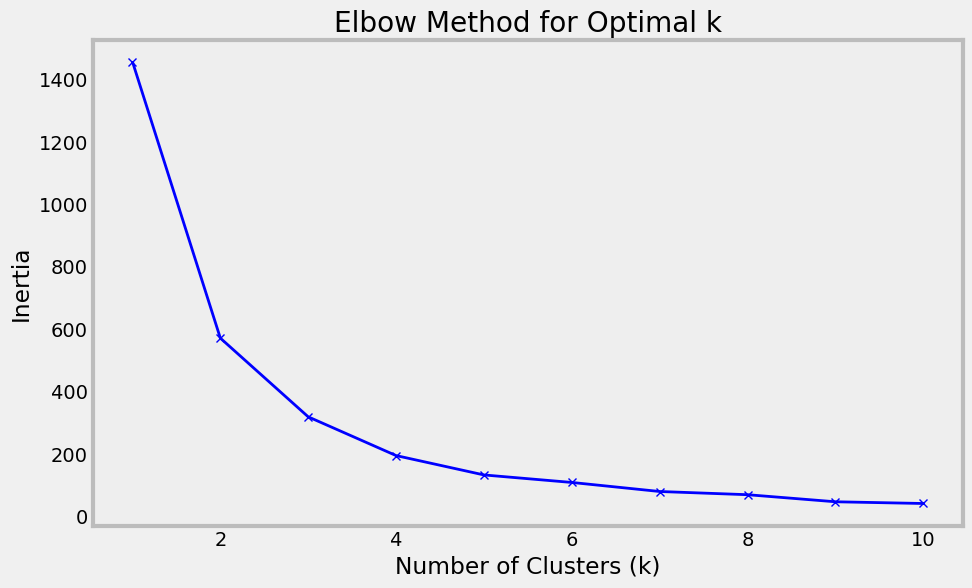

Cluster 2: Mean Price = $83958.98
Cluster 1: Mean Price = $133851.67
Cluster 0: Mean Price = $194839.43
Cluster 3: Mean Price = $312264.64


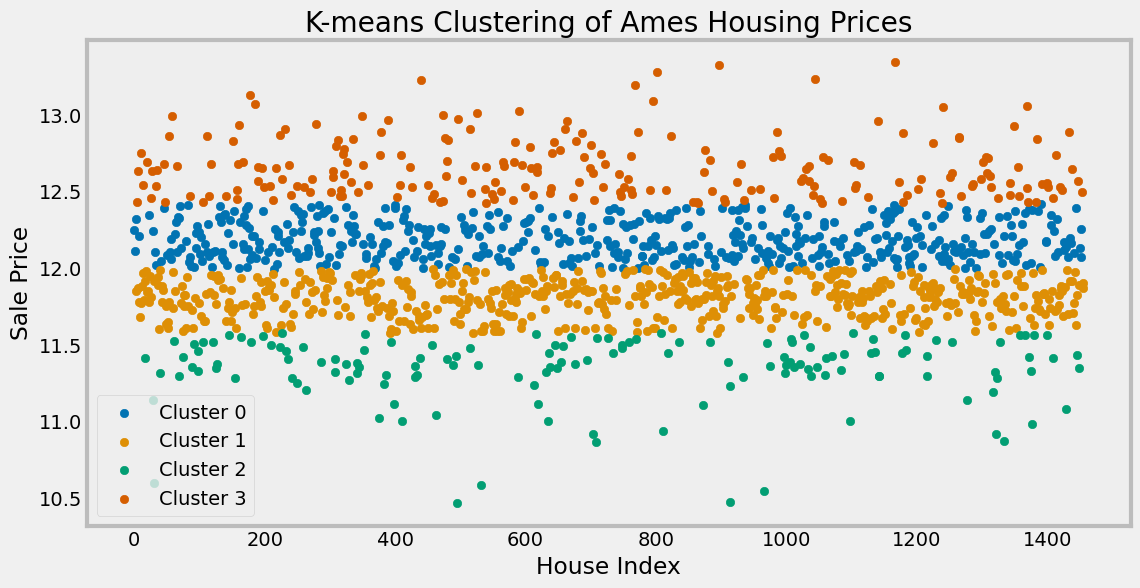

In [133]:
inertias = []
K = range(1, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(scaled_sale_prices)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertias, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

# Based on the elbow curve, let's choose an appropriate number of clusters
# For this example, let's say we choose 4 clusters
n_clusters = 4

kmeans = KMeans(n_clusters=n_clusters, random_state=seed)
kmeans.fit(scaled_sale_prices)

# Add cluster labels to the original dataframe
clustering_data = pd.DataFrame(final_study_data)
clustering_data['Cluster'] = kmeans.labels_

# Calculate the mean price for each cluster
cluster_means = clustering_data.groupby('Cluster')['SalePrice'].mean().sort_values()

for cluster, mean_price in cluster_means.items():
    print(f"Cluster {cluster}: Mean Price = ${expm1(mean_price):.2f}")

# Visualize the clusters
plt.figure(figsize=(12, 6))
for i in range(n_clusters):
    cluster_data = clustering_data[clustering_data['Cluster'] == i]
    plt.scatter(cluster_data.index, cluster_data['SalePrice'], label=f'Cluster {i}', color=colorblind_palette[i])

plt.xlabel('House Index')
plt.ylabel('Sale Price')
plt.title('K-means Clustering of Ames Housing Prices')
plt.legend()
plt.show()


**K-means Clustering + Silhouette Optimization of Ames Housing Prices**

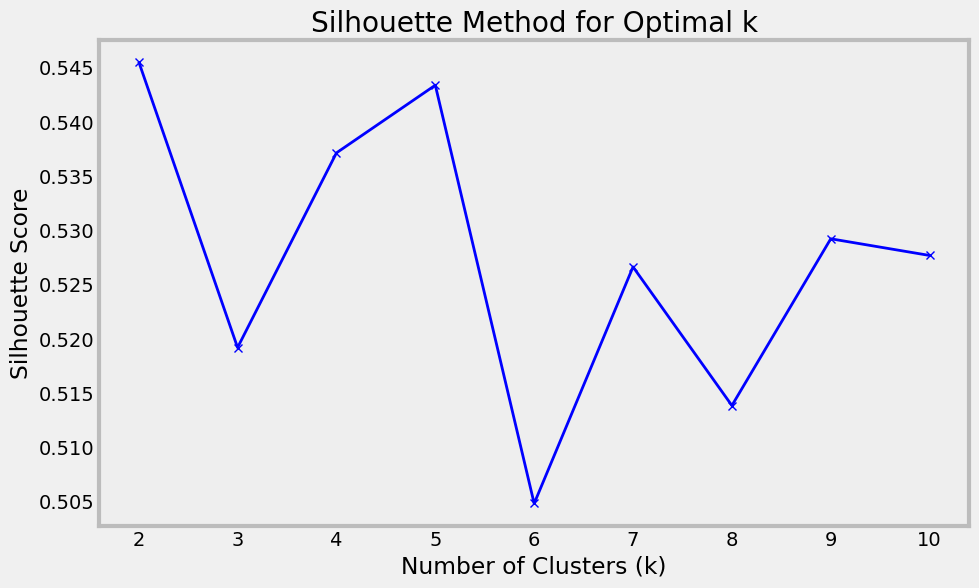

Optimal number of clusters: 2
Cluster 1: Mean Price = $125567.91
Cluster 0: Mean Price = $233574.83


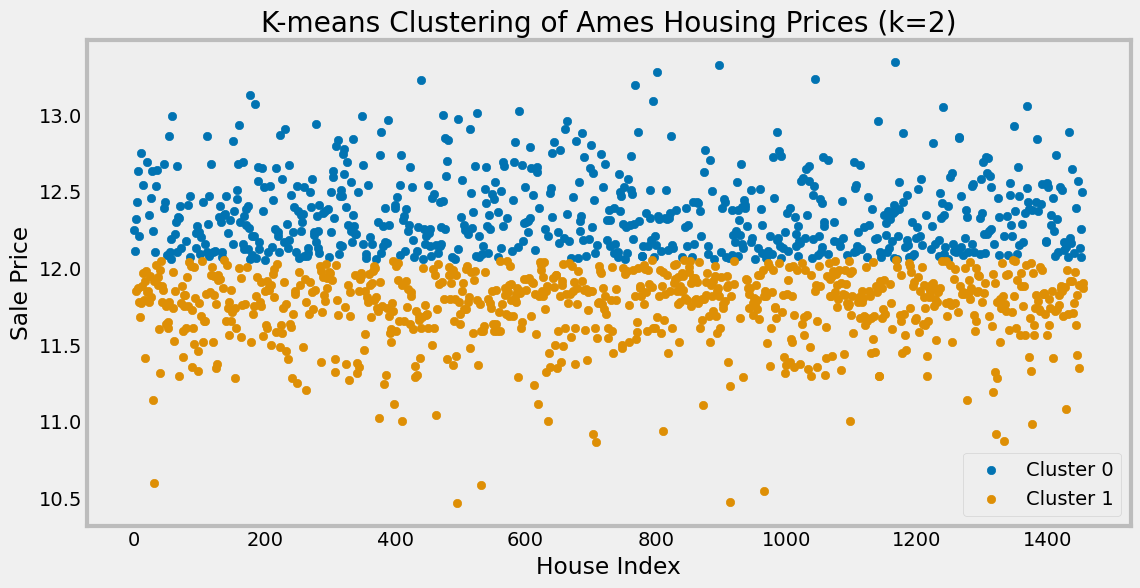

In [134]:
from sklearn.metrics import silhouette_score

# Calculate silhouette scores for different numbers of clusters
silhouette_scores = []
K = range(2, 11)  # Start from 2 clusters as silhouette score is not defined for 1 cluster

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=seed)
    kmeans.fit(scaled_sale_prices)
    score = silhouette_score(scaled_sale_prices, kmeans.labels_)
    silhouette_scores.append(score)

# Plot the silhouette scores
plt.figure(figsize=(10, 6))
plt.plot(K, silhouette_scores, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method for Optimal k')
plt.show()

# Find the optimal number of clusters (highest silhouette score)
optimal_k = K[silhouette_scores.index(max(silhouette_scores))]
print(f"Optimal number of clusters: {optimal_k}")

# Perform K-means clustering with the optimal number of clusters
kmeans = KMeans(n_clusters=optimal_k, random_state=seed)
kmeans.fit(scaled_sale_prices)

# Add cluster labels to the original dataframe
clustering_data = pd.DataFrame(final_study_data)
clustering_data['Cluster'] = kmeans.labels_

# Calculate the mean price for each cluster
cluster_means = clustering_data.groupby('Cluster')['SalePrice'].mean().sort_values()

# Print the mean prices for each cluster
for cluster, mean_price in cluster_means.items():
    print(f"Cluster {cluster}: Mean Price = ${expm1(mean_price):.2f}")

# Visualize the clusters
plt.figure(figsize=(12, 6))
for i in range(optimal_k):
    cluster_data = clustering_data[clustering_data['Cluster'] == i]
    plt.scatter(cluster_data.index, cluster_data['SalePrice'], label=f'Cluster {i}', color=colorblind_palette[i])

plt.xlabel('House Index')
plt.ylabel('Sale Price')
plt.title(f'K-means Clustering of Ames Housing Prices (k={optimal_k})')
plt.legend()
plt.show()

**Gaussian Mixture Model + BIC Score of Ames Housing Prices**

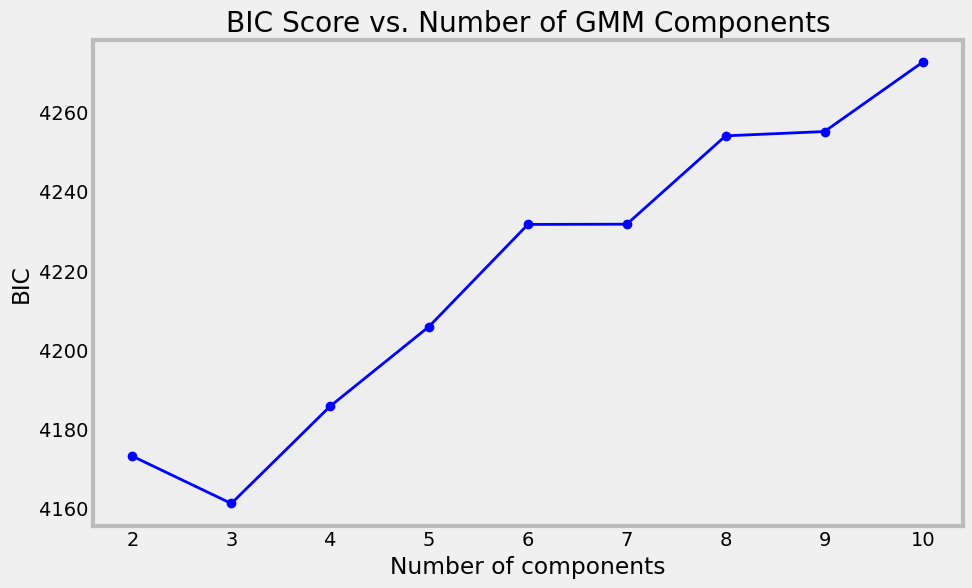

The optimal number of components based on BIC: 3



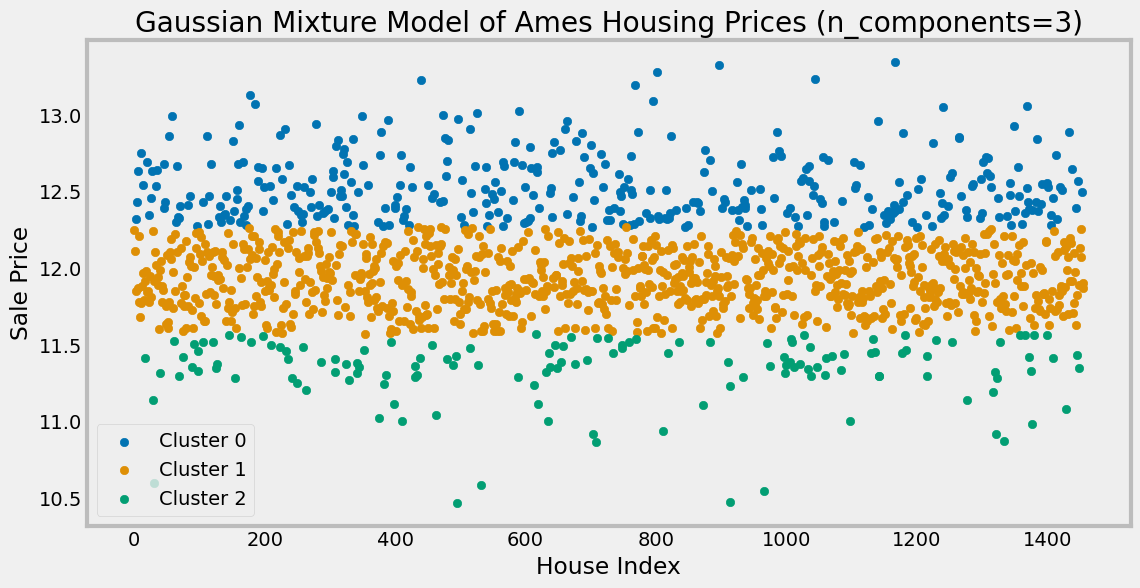

In [135]:
from sklearn.mixture import GaussianMixture

# Calculate BIC and silhouette scores for different numbers of components
n_components_range = range(2, 11)
bic = []
silhouette_scores = []

for n_components in n_components_range:
    # Fit a Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n_components, random_state=seed)
    gmm.fit(scaled_sale_prices)

    # Calculate BIC score
    bic.append(gmm.bic(scaled_sale_prices))

# Plot the BIC scores
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic, 'bo-')
plt.xlabel('Number of components')
plt.ylabel('BIC')
plt.title('BIC Score vs. Number of GMM Components')
plt.show()

# Find the optimal number of components (lowest BIC score)
optimal_n_components = n_components_range[bic.index(min(bic))]
print(f"The optimal number of components based on BIC: {optimal_n_components}\n")

# Fit the final GMM model with the optimal number of components
gmm = GaussianMixture(n_components=optimal_n_components, random_state=seed)
gmm.fit(scaled_sale_prices)

# Add cluster labels to the original dataframe
gmm_clustering_data = pd.DataFrame(final_study_data)
gmm_clustering_data['Cluster'] = gmm.predict(scaled_sale_prices)

# Calculate the mean price for each cluster
cluster_sale_price = gmm_clustering_data.groupby('Cluster')['SalePrice']
cluster_means = cluster_sale_price.mean().sort_values()
cluster_mins = cluster_sale_price.min()
cluster_maxs = cluster_sale_price.max()

# Visualize the clusters
plt.figure(figsize=(12, 6))
for i in range(optimal_n_components):
    cluster_data = gmm_clustering_data[gmm_clustering_data['Cluster'] == i]
    plt.scatter(cluster_data.index, cluster_data['SalePrice'], label=f'Cluster {i}', color=colorblind_palette[i])

plt.xlabel('House Index')
plt.ylabel('Sale Price')
plt.title(f'Gaussian Mixture Model of Ames Housing Prices (n_components={optimal_n_components})')
plt.legend()
plt.show()

#### **SalePrice Clustering Results**

Using three different clustering methods to analyze the SalePrice values in the Ames, Iowa dataset, I identified various clusters:

- __K-means Clustering + Elbow Optimization:__ Grouped houses into 4 clusters.

- __K-means Clustering + Silhouette Optimization:__ Grouped houses into 2 clusters.

- __Gaussian Mixture Model + Bayesian Information Criterion (BIC) Score:__ Grouped houses into 3 clusters.

To simplify the analysis and provide a clearer view of the housing market, I chose to use the results from the GMM+BIC method, defining three distinct housing segments based on their sale price ranges:

- **Luxury Homes Segment:** These are the high-end, more expensive homes.

- **Mid-Range Homes Segment:** These average-priced homes fall in the middle range.

- **Budget Homes Segment:** These are the more affordable, lower-priced homes.


In [138]:
# Define cluster labels to present the business conclussion
#
# cluster 1: Mean Price = $89484.06 [$35K - $111K]
# cluster 0: Mean Price = $155502.32 [$112K - $218K]
# cluster 2: Mean Price = $282697.23 [$219K - $625K]
#
#cluster_labels = ["Mid-Range Homes Segment","Budget Homes Segment","Luxury Homes Segment"]
cluster_labels = [
    'Luxury Homes Segment',
    'Mid-Range Homes Segment',
    'Budget Homes Segment'
]
# Print the mean prices for each cluster
for cluster, mean_price in cluster_means.items():
    print(f"{cluster_labels[cluster]} (cluster {cluster}): Mean Price = ${expm1(mean_price)/1000:.0f}K [${expm1(cluster_mins[cluster])/1000:.0f}K - ${expm1(cluster_maxs[cluster])/1000:.0f}K]")


Budget Homes Segment (cluster 2): Mean Price = $83K [$35K - $105K]
Mid-Range Homes Segment (cluster 1): Mean Price = $151K [$106K - $212K]
Luxury Homes Segment (cluster 0): Mean Price = $276K [$213K - $625K]


#### **Main House Price Ranges in Ames, Iowa**

This classification helps understand the housing market by segmenting it into easily understandable price ranges.

| Segment | Mean Price | Minimum Price | Maximum Price |
|----------|----------|----------|----------|
| Luxury Homes  | $276K  | $213K  | $625K  |
| Mid-Range Homes  | $151K  | $106K  | $212K  |
| Budget Homes  | $83K  | $35K  | $105K  |


### **Which Areas Can You Locate These Price Ranges?**

Based on the segmentation of budget, mid-range, and luxury homes, I can now identify the top neighborhoods where these houses are located. This helps us understand where different types of homes are most commonly found in the Ames, Iowa, housing market.




Top 5 neighborhoods for Luxury Homes Segment:
  NoRidge: 0.97
  NridgHt: 0.83
  StoneBr: 0.76
  Timber: 0.61
  Somerst: 0.56

Top 5 neighborhoods for Mid-Range Homes Segment:
  Blueste: 1.00
  NPkVill: 1.00
  Sawyer: 0.95
  NAmes: 0.89
  SWISU: 0.88

Top 5 neighborhoods for Budget Homes Segment:
  MeadowV: 0.71
  IDOTRR: 0.51
  BrDale: 0.44
  Edwards: 0.30
  BrkSide: 0.29


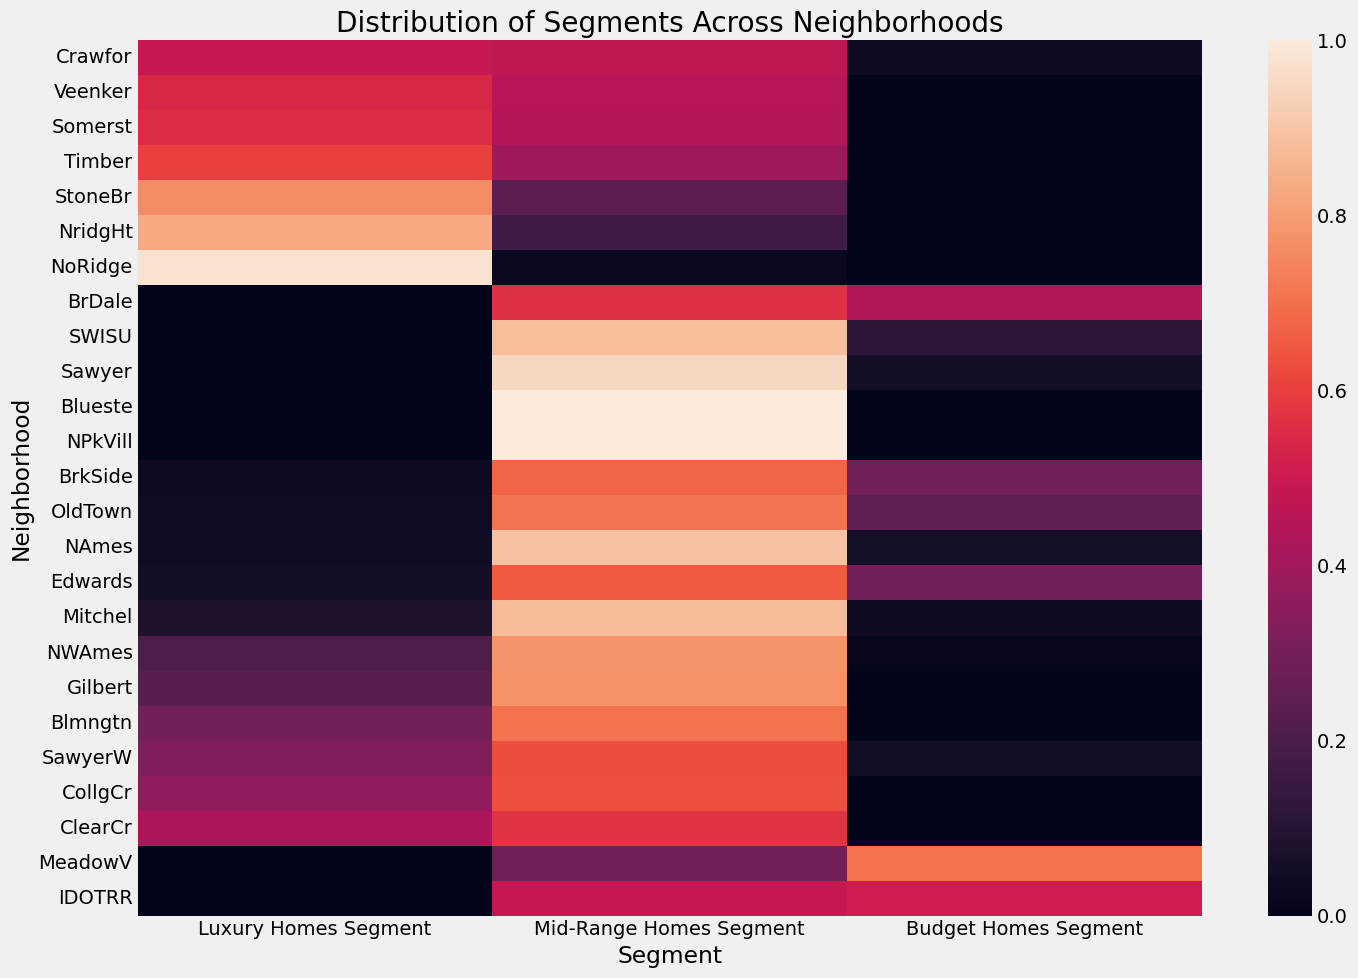

In [139]:
# Analyze the distribution of clusters across neighborhoods
neighborhood_clusters = gmm_clustering_data.groupby('Neighborhood')['Cluster'].value_counts(normalize=True).unstack()

# Fill NaN values with 0
neighborhood_clusters = neighborhood_clusters.fillna(0)

# Sort neighborhoods by the most prevalent cluster
dominant_cluster = neighborhood_clusters.idxmax(axis=1)
neighborhood_clusters['Dominant_Cluster'] = dominant_cluster
neighborhood_clusters = neighborhood_clusters.sort_values(by=['Dominant_Cluster'] + list(neighborhood_clusters.columns[:-1]))

# Identify top neighborhoods for each cluster
top_neighborhoods = {}
for cluster in range(3):
    top_neighborhoods[cluster] = neighborhood_clusters[cluster].nlargest(5)

for cluster, neighborhoods in top_neighborhoods.items():
    print(f"\nTop 5 neighborhoods for {cluster_labels[cluster]}:")
    for neighborhood, proportion in neighborhoods.items():
        print(f"  {neighborhood}: {proportion:.2f}")

# Plot the distribution of clusters across neighborhoods
plt.figure(figsize=(15, 10))
ax = sns.heatmap(neighborhood_clusters.iloc[:, :-1])
ax.set_xticklabels(cluster_labels)
plt.title('Distribution of Segments Across Neighborhoods')
plt.ylabel('Neighborhood')
plt.xlabel('Segment')
plt.tight_layout()
plt.show()

These are the top 5 neighborhoods for each segment:

**Customize it according to your dataset**

- **Luxury Homes Segment:** These neighborhoods are known for their expensive houses.
    - NoRidge
    - NridgHt
    - StoneBr
    - Timber
    - Somerst

Mid-Range Homes Segment: These neighborhoods feature homes with average prices that fall in the middle range.
Blueste
NPkVill
Mitchel
Sawyer
SWISU
Budget Homes Segment: These neighborhoods are characterized by more affordable, lower-priced houses.
MeadowV
IDOTRR
BrDale
OldTown
Edwards

#### **What features best predict the price range of each home?**

To determine which features most accurately predict the price range of each home, I analyzed the overall housing market and the previously identified segments: budget, mid-range, and luxury homes. This approach allows me to identify the main factors influencing the entire market and the specific segments.

I used the Random Forest Regressor, AdaBoost Regressor, and a Decision Tree Regressor to pinpoint the key features. For this analysis, I used the default settings of these regressors, but further studies could explore other models and fine-tune the parameters for even better results.



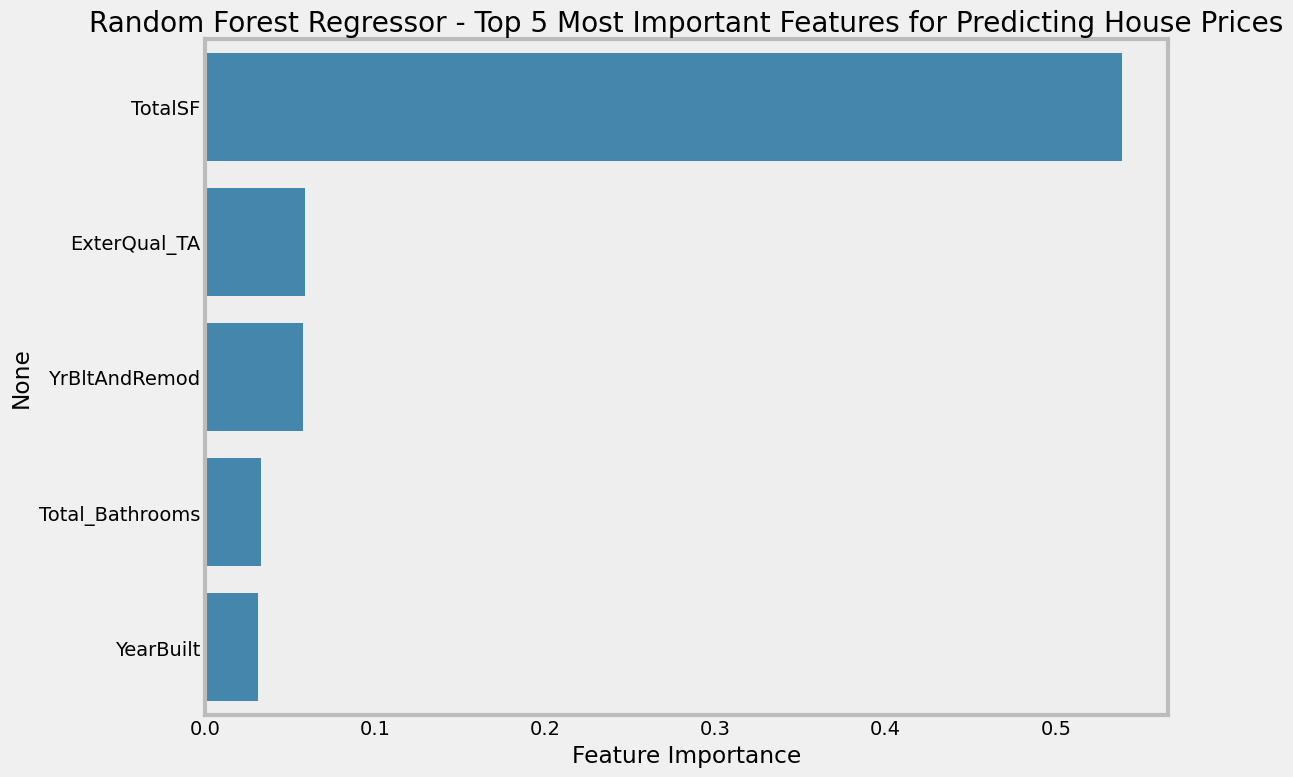

Random Forest Regressor - Top 5 most important features:
1. TotalSF: 0.5389
2. ExterQual_TA: 0.0587
3. YrBltAndRemod: 0.0577
4. Total_Bathrooms: 0.0328
5. YearBuilt: 0.0314


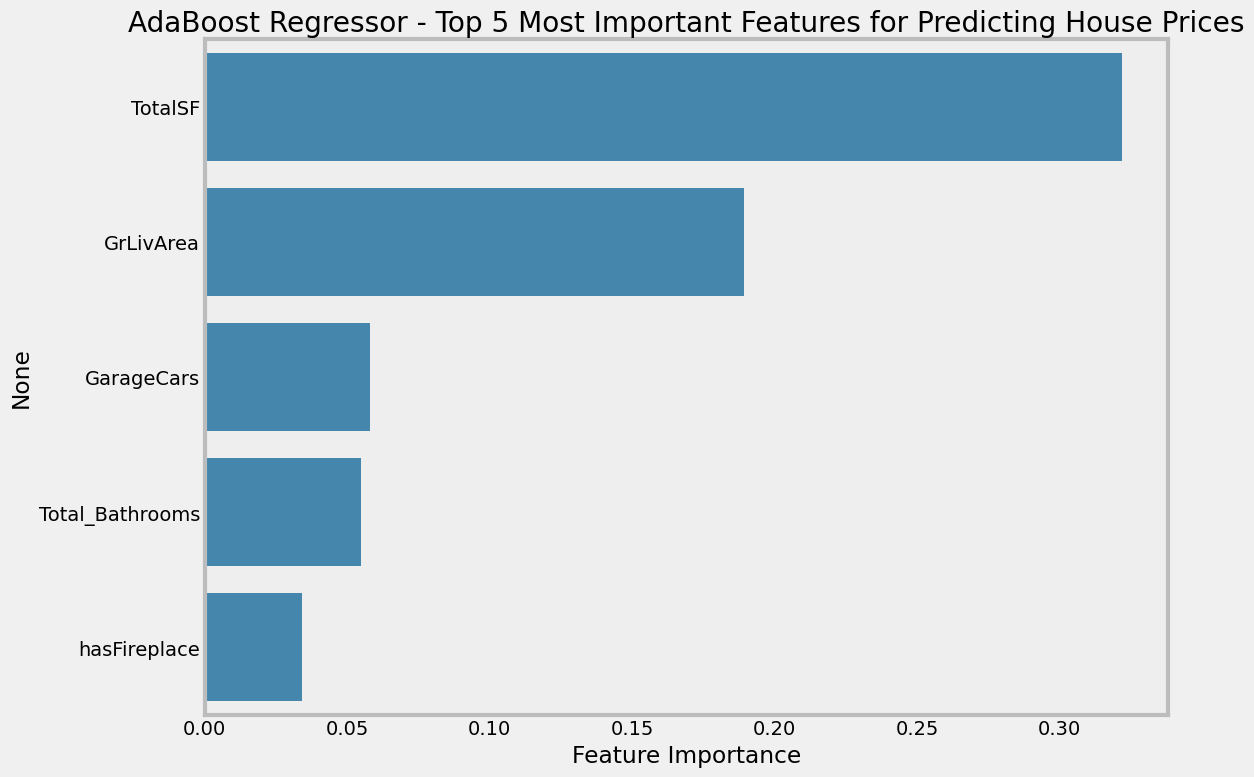

AdaBoost Regressor - Top 5 most important features:
1. TotalSF: 0.3220
2. GrLivArea: 0.1893
3. GarageCars: 0.0581
4. Total_Bathrooms: 0.0547
5. hasFireplace: 0.0342


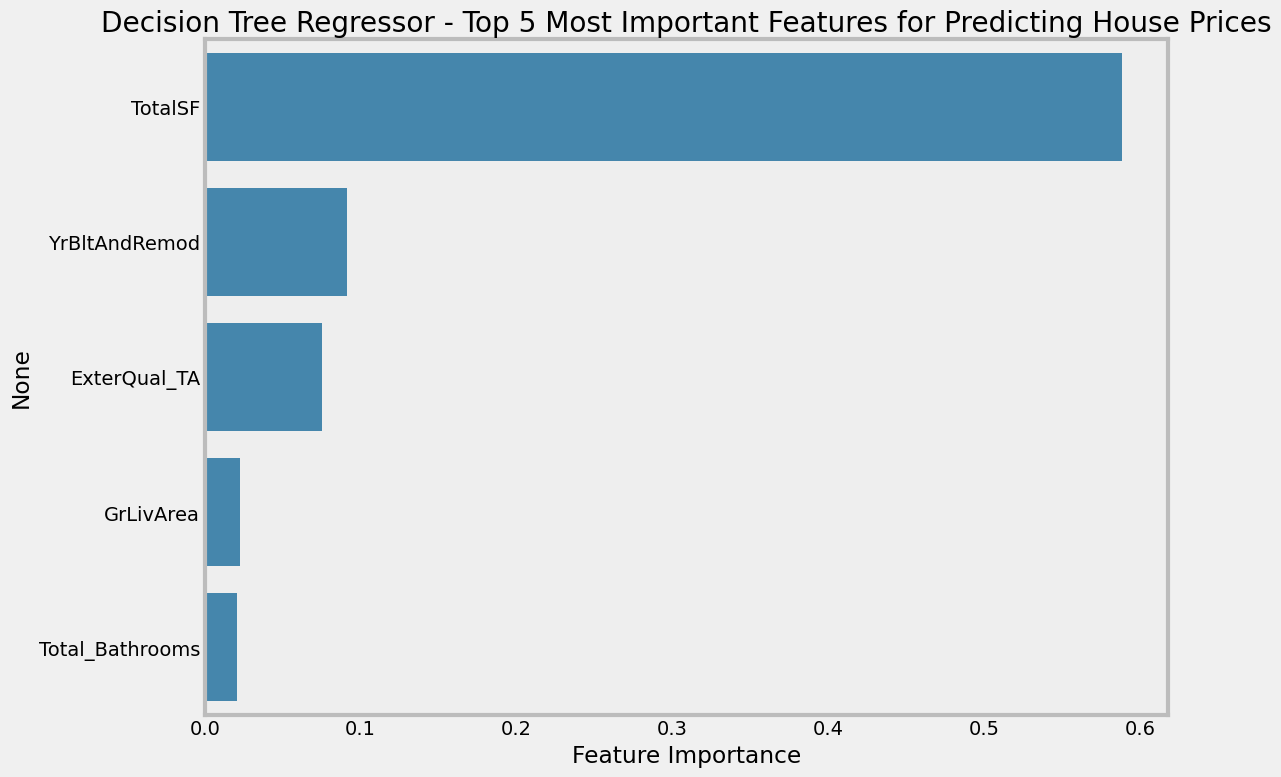

Decision Tree Regressor - Top 5 most important features:
1. TotalSF: 0.5886
2. YrBltAndRemod: 0.0910
3. ExterQual_TA: 0.0752
4. GrLivArea: 0.0229
5. Total_Bathrooms: 0.0204


In [140]:
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor

# Separate features and target
X = encoded_study_data.drop('SalePrice', axis=1)
y = encoded_study_data['SalePrice']

def regresor_fit_and_print(title, X, y, regressor):
    """
    Fit and print a regressor results
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
    regressor.fit(X_train, y_train)

    importances = regressor.feature_importances_
    feature_importances = pd.Series(importances, index=X.columns).sort_values(ascending=False)

    plt.figure(figsize=(12, 8))
    sns.barplot(x=feature_importances.values[:5], y=feature_importances.index[:5])
    plt.title(title + ' - Top 5 Most Important Features for Predicting House Prices')
    plt.xlabel('Feature Importance')
    plt.tight_layout()
    plt.show()

    print(title + " - Top 5 most important features:")
    for i, (feature, importance) in enumerate(feature_importances[:5].items(), 1):
        print(f"{i}. {feature}: {importance:.4f}")

random_forest_regressor = RandomForestRegressor(random_state=seed)
regresor_fit_and_print("Random Forest Regressor", X, y, random_forest_regressor)

ada_boost_regressor = AdaBoostRegressor(random_state=seed)
regresor_fit_and_print("AdaBoost Regressor", X, y, ada_boost_regressor)

decision_tree_regressor = DecisionTreeRegressor(random_state=seed)
regresor_fit_and_print("Decision Tree Regressor", X, y, decision_tree_regressor)


**Customize according to your dataset**

According to the results from these regressors, here are the top 7 features that drive housing prices in the general market:

- Random Forest Regressor:
    - TotalSF: Total square footage of the house.
    - ExterQual_TA: Quality of the exterior material (Average/Typical).
    - YrBltAndRemod: Combined years since the house was built and any renovations.
    - GrLivArea: Above-ground living area.
    - Total_Bathrooms: Total number of bathrooms in the house.
    - YearBuilt: The year the house was built.
    - GarageArea: Size of the garage.

AdaBoost Regressor:
TotalSF: Total square footage of the house.
GrLivArea: Above-ground living area.
Total_Bathrooms: Total number of bathrooms in the house.
GarageCars: Number of cars the garage can hold.
Fireplaces: Number of fireplaces in the house.
GarageYrBlt: The year the garage was built.
GarageArea: Size of the garage.

Decision Tree Regressor:
TotalSF: Total square footage of the house.
YrBltAndRemod: Combined years since the house was built and any renovations.
ExterQual_TA: Quality of the exterior material.
GrLivArea: Above-ground living area.
Total_Bathrooms: Total number of bathrooms in the house.
KitchenAbvGr: Number of kitchens above ground.
BsmtFinSF1: Finished square footage of the basement.

### **Conclusions**

Based on the results from these regressors, I conclude that several key factors strongly influence the sale price of homes:

- **House Surface:** Total square footage and above-ground living area are crucial in determining home value.

- **Garage Characteristics:** The size of the garage, the number of cars it can hold, and the year it was built are significant predictors of price.

- **House Age:** The year the house was built and the combined years since any renovations are influential factors.

- **Total Bathrooms:** The total number of bathrooms in the house also significantly predicts price.

Understanding these features helps to focus on what truly matters when evaluating home prices.

### **Sale Price Predictors for Budget, Mid-Range, and Luxury Homes**

I repeated the analysis for each category to understand the different factors influencing the sale price of homes in the budget, mid-range, and luxury segments. This advanced study reveals the various considerations that buyers might prioritize within each segment.



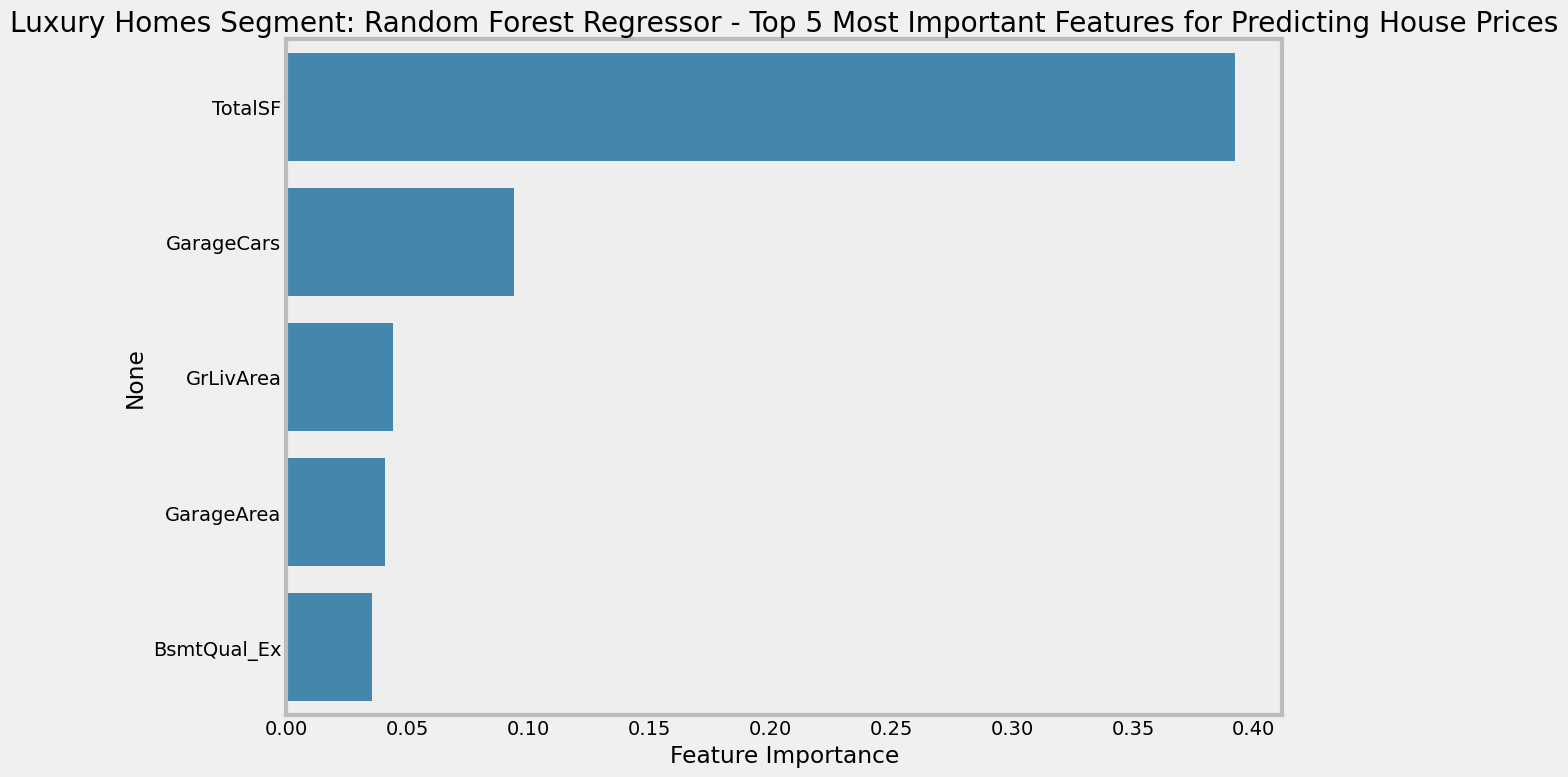

Luxury Homes Segment: Random Forest Regressor - Top 5 most important features:
1. TotalSF: 0.3921
2. GarageCars: 0.0940
3. GrLivArea: 0.0442
4. GarageArea: 0.0408
5. BsmtQual_Ex: 0.0354


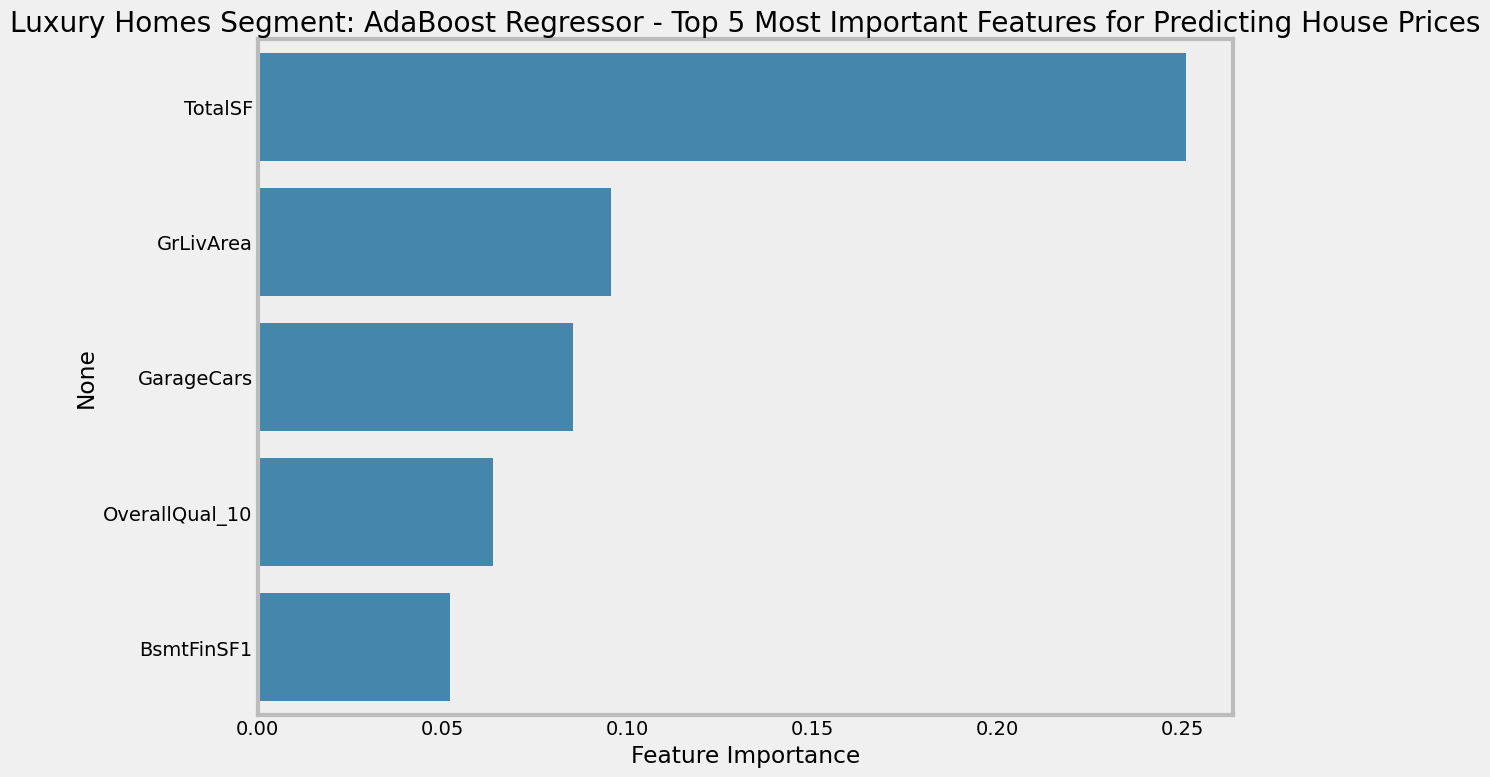

Luxury Homes Segment: AdaBoost Regressor - Top 5 most important features:
1. TotalSF: 0.2510
2. GrLivArea: 0.0955
3. GarageCars: 0.0852
4. OverallQual_10: 0.0636
5. BsmtFinSF1: 0.0520


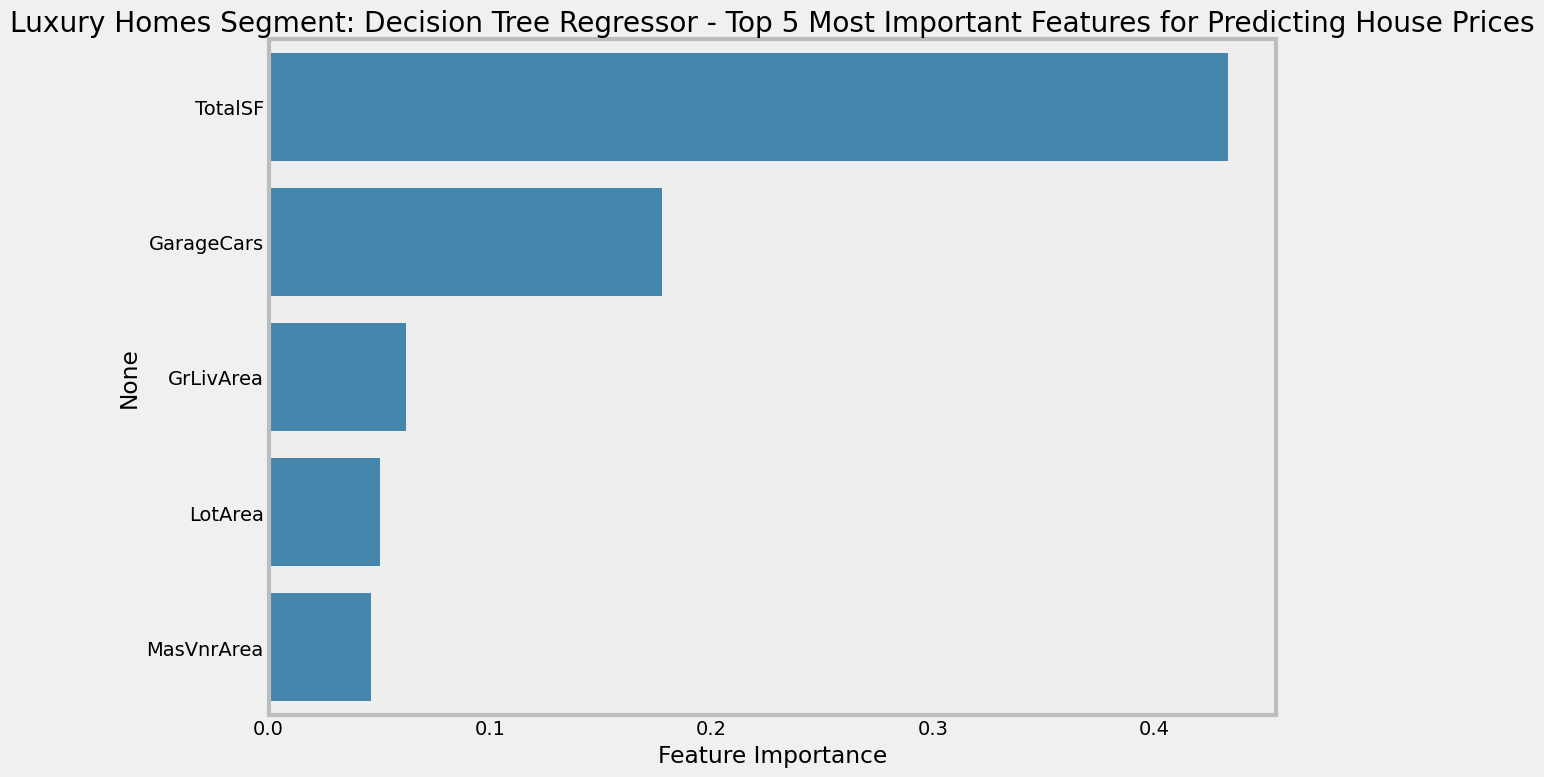

Luxury Homes Segment: Decision Tree Regressor - Top 5 most important features:
1. TotalSF: 0.4331
2. GarageCars: 0.1776
3. GrLivArea: 0.0618
4. LotArea: 0.0503
5. MasVnrArea: 0.0464


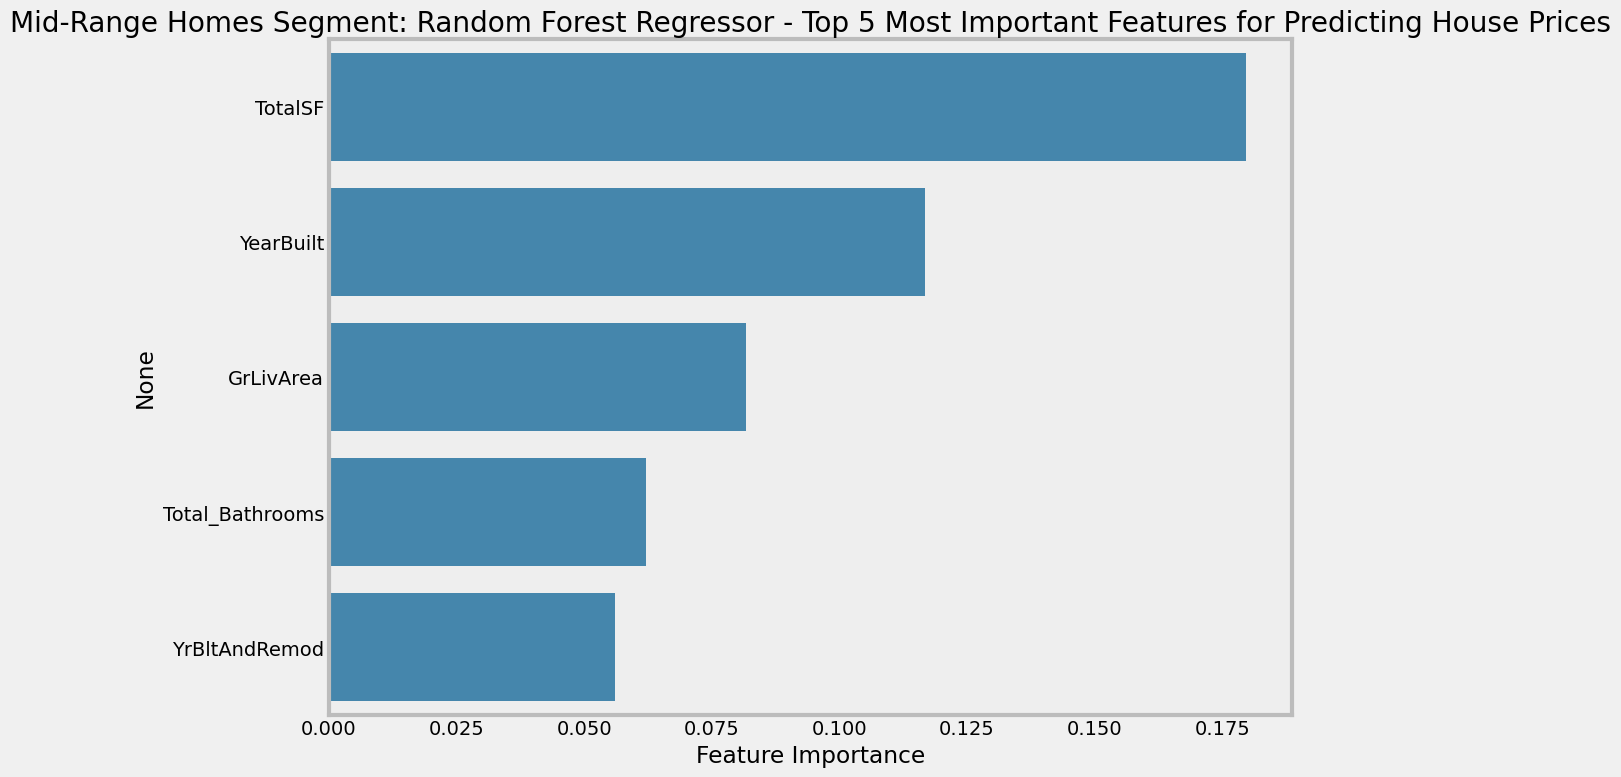

Mid-Range Homes Segment: Random Forest Regressor - Top 5 most important features:
1. TotalSF: 0.1797
2. YearBuilt: 0.1167
3. GrLivArea: 0.0816
4. Total_Bathrooms: 0.0620
5. YrBltAndRemod: 0.0560


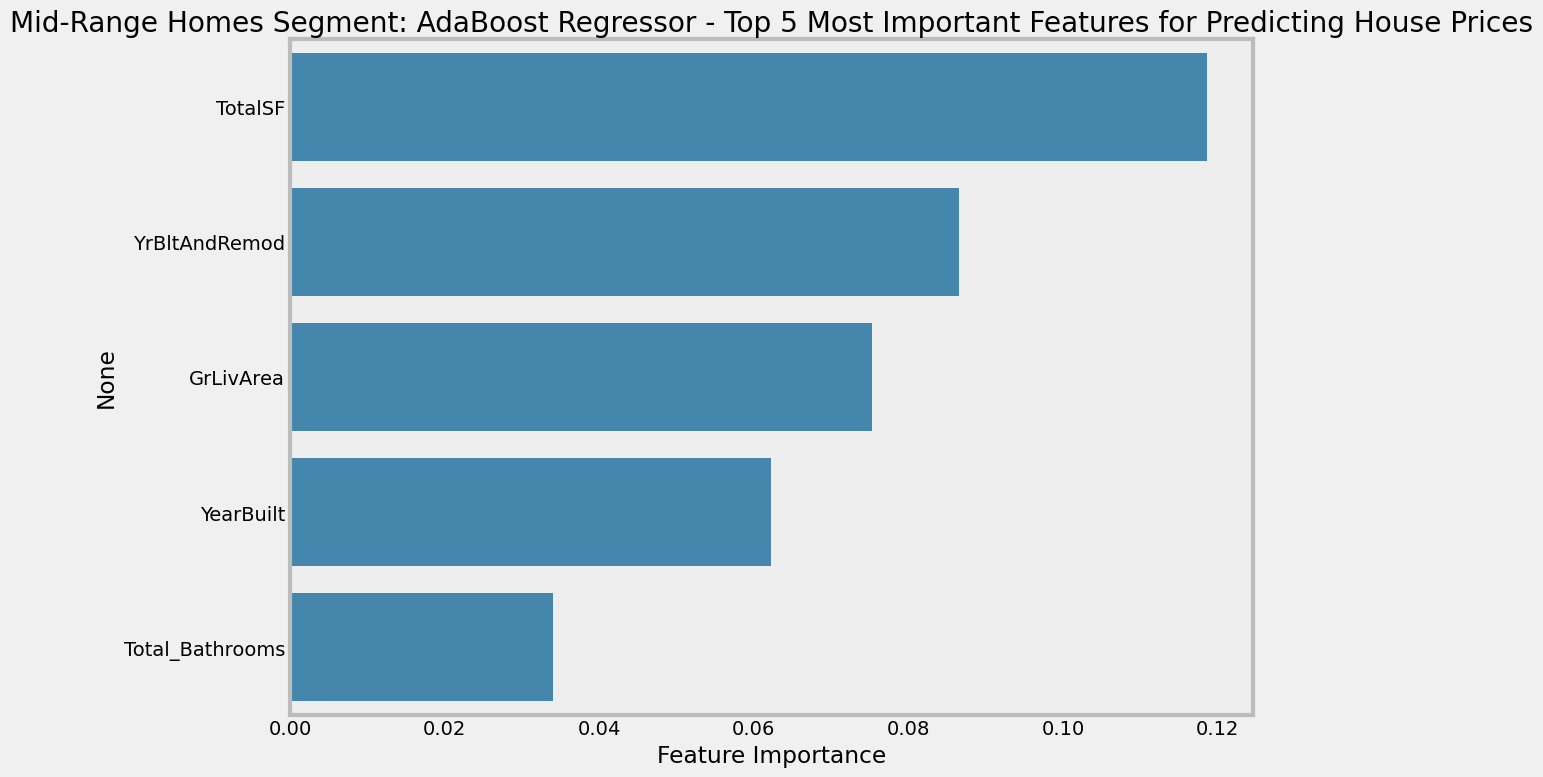

Mid-Range Homes Segment: AdaBoost Regressor - Top 5 most important features:
1. TotalSF: 0.1187
2. YrBltAndRemod: 0.0866
3. GrLivArea: 0.0753
4. YearBuilt: 0.0623
5. Total_Bathrooms: 0.0340


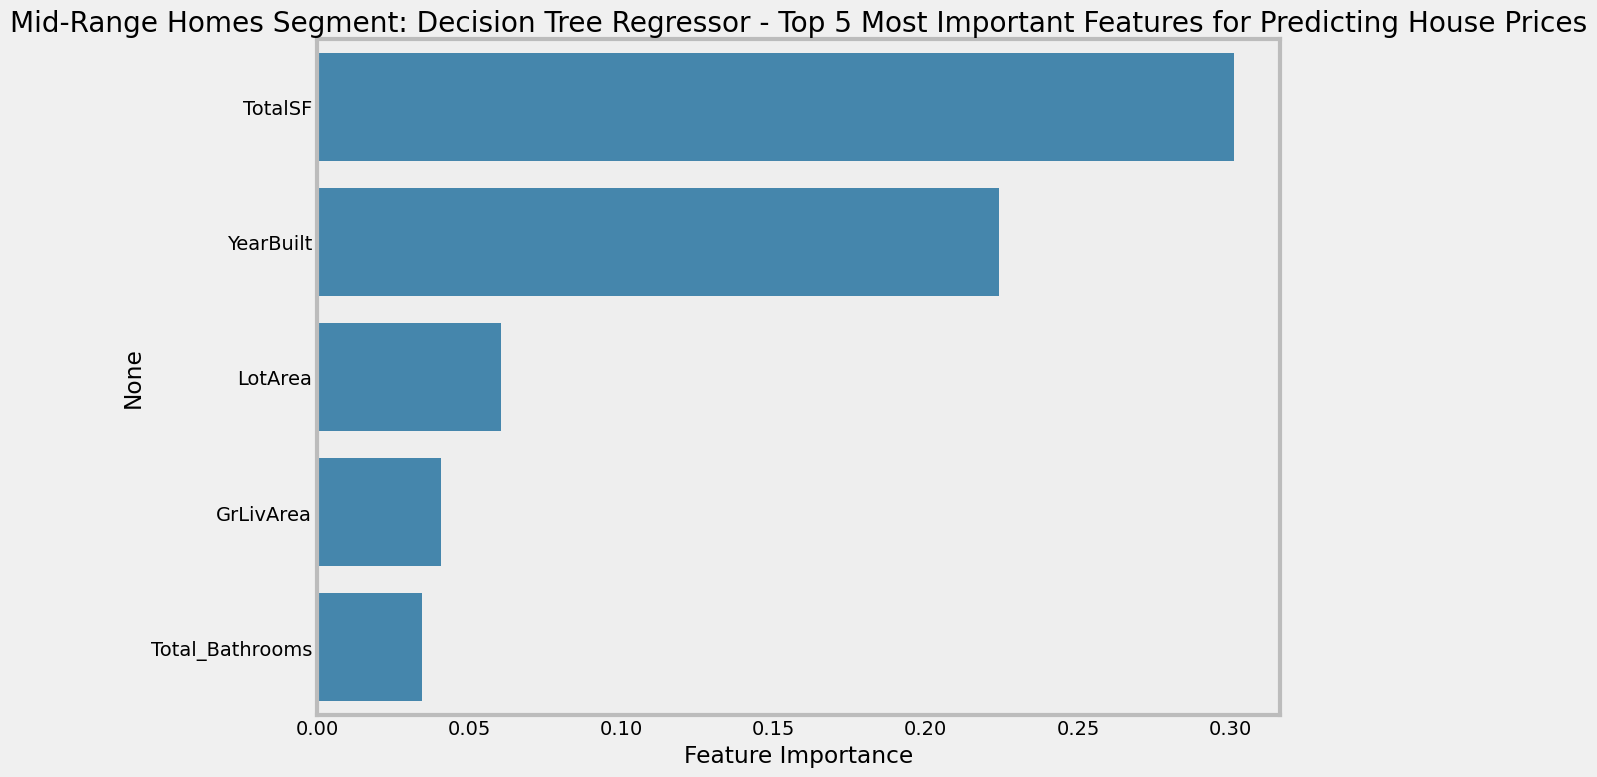

Mid-Range Homes Segment: Decision Tree Regressor - Top 5 most important features:
1. TotalSF: 0.3013
2. YearBuilt: 0.2240
3. LotArea: 0.0603
4. GrLivArea: 0.0407
5. Total_Bathrooms: 0.0344


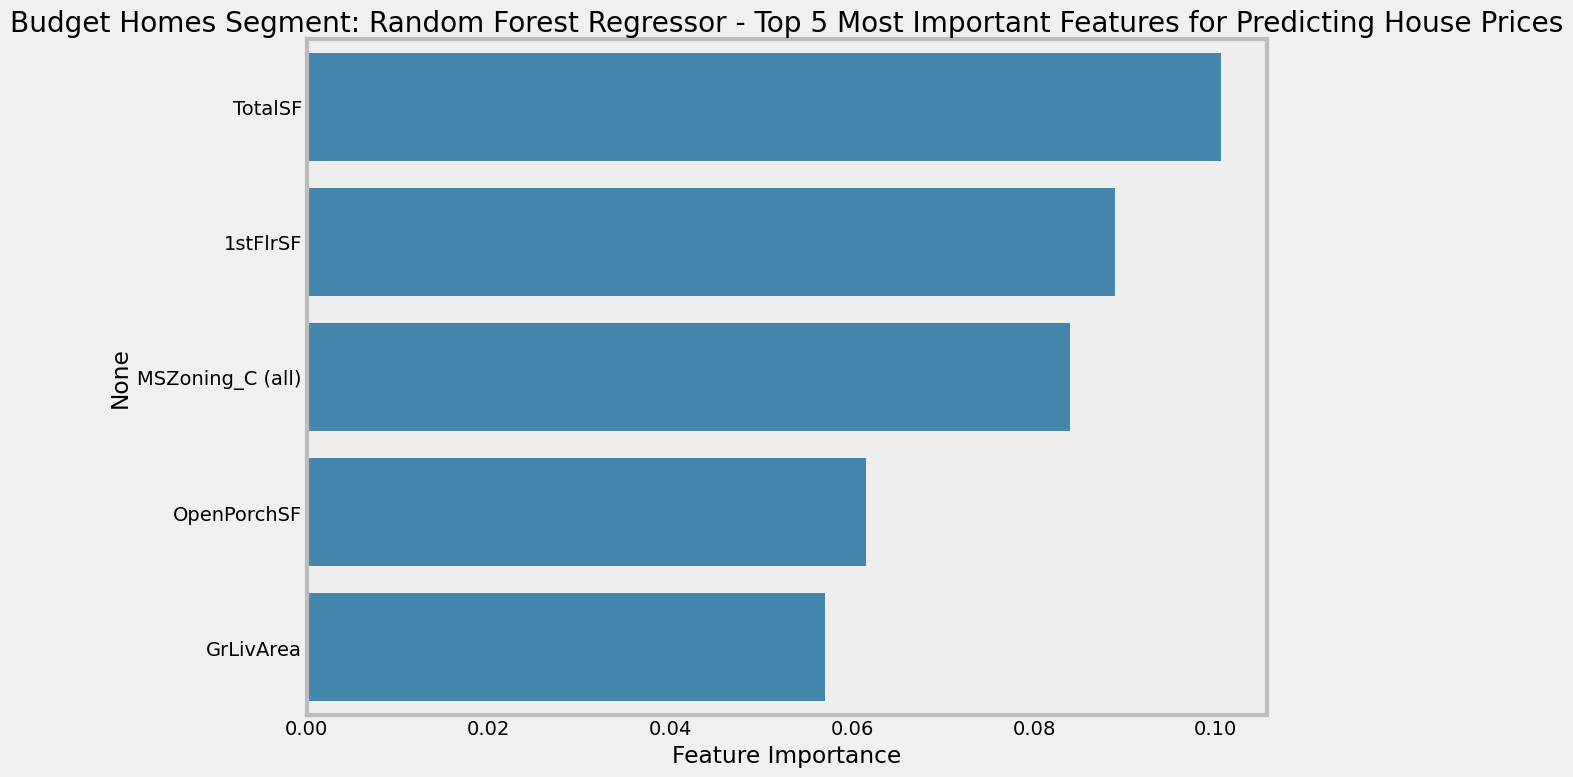

Budget Homes Segment: Random Forest Regressor - Top 5 most important features:
1. TotalSF: 0.1006
2. 1stFlrSF: 0.0889
3. MSZoning_C (all): 0.0840
4. OpenPorchSF: 0.0615
5. GrLivArea: 0.0571


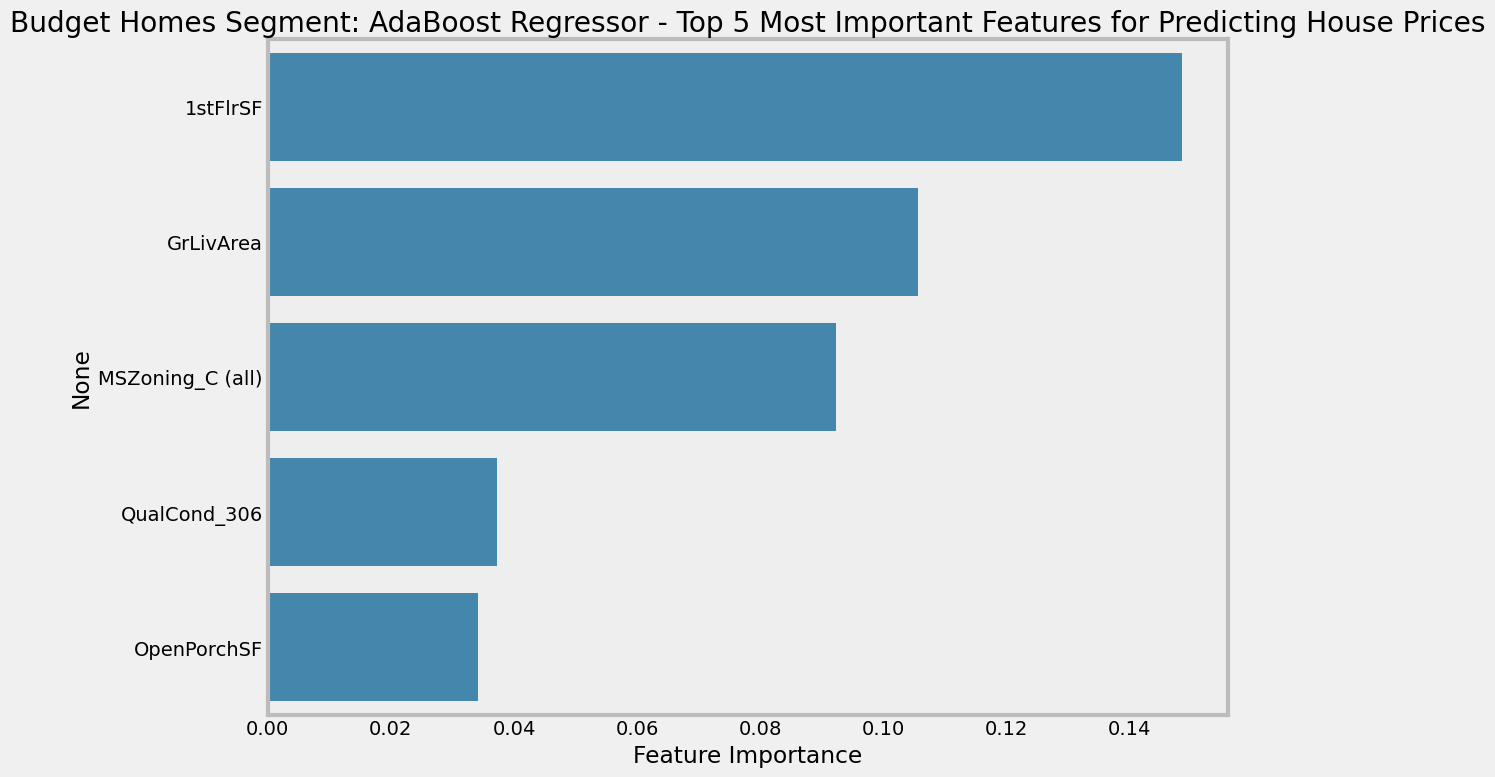

Budget Homes Segment: AdaBoost Regressor - Top 5 most important features:
1. 1stFlrSF: 0.1485
2. GrLivArea: 0.1056
3. MSZoning_C (all): 0.0923
4. QualCond_306: 0.0373
5. OpenPorchSF: 0.0341


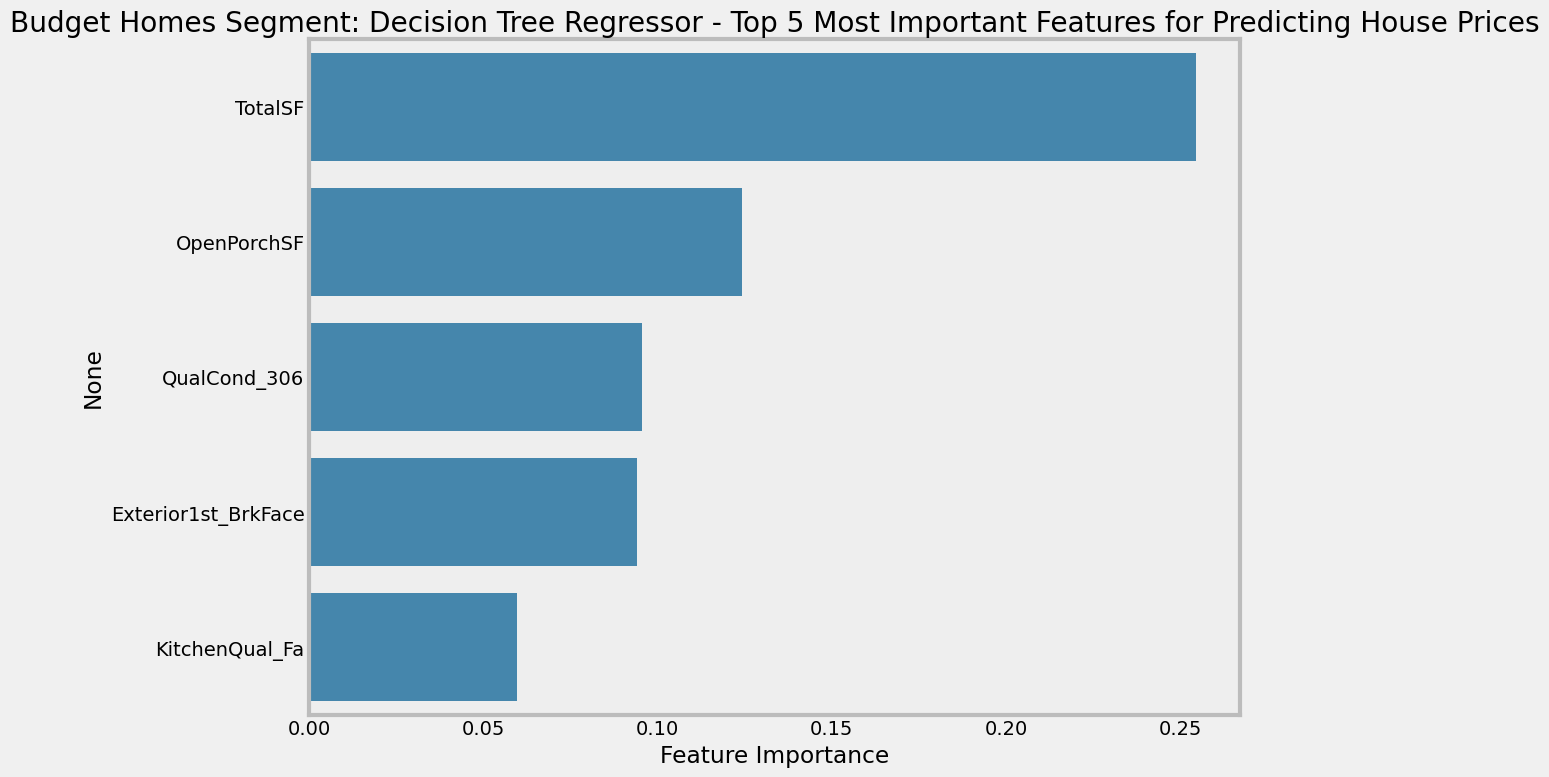

Budget Homes Segment: Decision Tree Regressor - Top 5 most important features:
1. TotalSF: 0.2545
2. OpenPorchSF: 0.1241
3. QualCond_306: 0.0955
4. Exterior1st_BrkFace: 0.0942
5. KitchenQual_Fa: 0.0596


In [141]:
for i in range(optimal_n_components):
    cluster_data = gmm_clustering_data[gmm_clustering_data['Cluster'] == i]
    final_cluster_data = one_hot_encode(cluster_data)
    X_cluster = final_cluster_data.drop(columns=['SalePrice'])
    y_cluster = final_cluster_data['SalePrice']

    random_forest_regressor = RandomForestRegressor(random_state=seed)
    regresor_fit_and_print(f"{cluster_labels[i]}: Random Forest Regressor", X_cluster, y_cluster, random_forest_regressor)

    ada_boost_regressor = AdaBoostRegressor(random_state=seed)
    regresor_fit_and_print(f"{cluster_labels[i]}: AdaBoost Regressor", X_cluster, y_cluster, ada_boost_regressor)

    decision_tree_regressor = DecisionTreeRegressor(random_state=seed)
    regresor_fit_and_print(f"{cluster_labels[i]}: Decision Tree Regressor", X_cluster, y_cluster, decision_tree_regressor)


**Customize according to ur dataset**

### **Conclusions**

From the top 5 most essential features for budget, mid-range, and luxury homes, we notice some variables previously identified for the general market. By excluding these general commonalities, we can delve deeper and identify patterns that specifically increase the sale price within each segment. Here are my findings:

- **Luxury Homes Segment**
    - **Livable Basement Finished Surface** (BsmtFinSF1 and TotalBsmtSF) and the height of the basement (BsmtQual). Excellent quality basements (100+ inches) add significant value.
    - **Total Rooms Above Grade**: More rooms (excluding bathrooms) increase the home's value.

- Mid-Range Homes Segment
    - Full Bathrooms Above Grade (FullBath): More full bathrooms on the main floors significantly impact the sale price.
    - Detached Garage Location (GarageType Detchd): Detached garages are valuable in this segment.

- Budget Homes Segment:
    - Open Porch Area (OpenPorchSF): Larger open porch areas contribute to higher prices.
    - First Floor Area (1stFlrSF): A more extensive first-floor area adds value.
    - Exterior Material Condition (ExterCond): The condition of the exterior material, mainly if it's excellent or fair, impacts the sale price.

Understanding these specific drivers within each segment helps us better predict and evaluate home prices based on various characteristics and amenities. Further studies could refine these insights and explore additional features influencing housing prices.



### **Parting Thoughts**

What started as a simple assignment for the Udemy Data Scientist Nanodegree Program was an incredible learning journey. I applied various data science techniques, including:

- Setting clear objectives
- Exploring and visualizing data
- Identifying and removing outliers
- Addressing skewed distributions
- Handling missing data
- Normalizing numerical features
- Conducting bivariate analysis
- Extracting insights from the Ames, Iowa housing market

This experience deepened my understanding of the data science workflow and the CRISP-DM process. It answered the initial questions and sparked my curiosity about further exploration in the field.